### Импорт библиотек

In [2]:
import pymongo
import pandas as pd
import numpy as np

### Загрузка данных

In [5]:
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["JiraRepos"]
collection = db["Merged"]

cursor = collection.find(
    {},
    {
        "_id": 1,
        "summary": 1,
        "description": 1,
        "timespent": 1,
        "source_collection": 1
    }
)

df = pd.DataFrame(list(cursor))

print(f"Загружено записей: {len(df)}")
print(f"\nКолонки: {list(df.columns)}")
print(f"\nПропуски:\n{df.isnull().sum()}")
print(f"\nПервые 3 записи:")
df.head(3)

Загружено записей: 79453

Колонки: ['_id', 'summary', 'description', 'timespent', 'source_collection']

Пропуски:
_id                      0
summary                  0
description          11110
timespent                0
source_collection        0
dtype: int64

Первые 3 записи:


,_id,summary,description,timespent,source_collection
0,69a4502db58247291944152e,Write a script to automate the mailing list su...,None,18000,Sonatype
1,69a4502db58247291944152f,Repository for GraniteDS,"Granite Data Services is a free, open source (...",1020,Sonatype
2,69a4502db582472919441530,Central sync for project makumba,I have promoted release 0.8.2.6 for project ma...,480,Sonatype


### Функция очистки текста

In [3]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Убираем URL
    text = re.sub(r'https?://\S+', ' ', text)
    
    # Убираем email
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Убираем Java stack traces (строки с "at com.xxx.xxx(File.java:123)")
    text = re.sub(r'\bat\s+[\w\.\$]+\([\w\.]+:\d+\)', ' ', text)
    
    # Убираем полные имена Java классов (com.apache.xxx.yyy.ZzzClass)
    text = re.sub(r'\b[\w]+(?:\.[\w]+){3,}\b', ' ', text)
    
    # Убираем hex-хеши (коммиты, id)
    text = re.sub(r'\b[0-9a-f]{7,40}\b', ' ', text)
    
    # Убираем пути к файлам
    text = re.sub(r'[/\\][\w\-\.]+(?:[/\\][\w\-\.]+){2,}', ' ', text)
    
    # Убираем блоки кода в фигурных скобках (Jira markup {code}...{code})
    text = re.sub(r'\{code[^}]*\}.*?\{code\}', ' ', text, flags=re.DOTALL)
    text = re.sub(r'\{noformat\}.*?\{noformat\}', ' ', text, flags=re.DOTALL)
    
    # Убираем оставшиеся числа длиннее 4 цифр
    text = re.sub(r'\b\d{5,}\b', ' ', text)
    
    # Убираем лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

## TF-IFD + Ridge, все проекты

In [10]:
# ---------- Подготовка данных ----------
df["description"] = df["description"].fillna("")
df["text"] = df["summary"] + " " + df["description"]
df["log_timespent"] = np.log1p(df["timespent"])
df = df[df["timespent"] > 0].copy()

C:\Users\maxgo\AppData\Local\Temp\ipykernel_25800\1908346144.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["description"] = df["description"].fillna("")
C:\Users\maxgo\AppData\Local\Temp\ipykernel_25800\1908346144.py:3: FutureWarnin

In [6]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pd.set_option('display.float_format', lambda x: '%.6f' % x)

print(f"Записей после фильтрации: {len(df)}")
print(f"\ntimespent (секунды):")
print(df["timespent"].describe())
print(f"\nlog_timespent:")
print(df["log_timespent"].describe())

Записей после фильтрации: 78634

timespent (секунды):
count       78634.000000
mean        19501.899865
std       2678024.979002
min             6.000000
25%          1200.000000
50%          3000.000000
75%          7800.000000
max     750857760.000000
Name: timespent, dtype: float64

log_timespent:
count   78634.000000
mean        8.205650
std         1.226530
min         1.945910
25%         7.090910
50%         8.006701
75%         8.962007
max        20.436727
Name: log_timespent, dtype: float64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["log_timespent"],
    test_size=0.2,
    random_state=42
)

print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")


Train: 62907, Test: 15727


In [7]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF матрица: {X_train_tfidf.shape}")


TF-IDF матрица: (62907, 50000)


In [9]:
model = Ridge(alpha=10.0)
model.fit(X_train_tfidf, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [10]:
y_pred_log = model.predict(X_test_tfidf)

# Метрики в log-пространстве
print("\n===== Метрики (log-пространство) =====")
print(f"R²:   {r2_score(y_test, y_pred_log):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_log):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_log)):.4f}")

# Переводим обратно в секунды
y_test_seconds = np.expm1(y_test)
y_pred_seconds = np.expm1(y_pred_log)

# Метрики в секундах
print("\n===== Метрики (секунды) =====")
print(f"R²:   {r2_score(y_test_seconds, y_pred_seconds):.4f}")
print(f"MAE:  {mean_absolute_error(y_test_seconds, y_pred_seconds):.2f} сек "
      f"({mean_absolute_error(y_test_seconds, y_pred_seconds)/3600:.2f} ч)")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_seconds, y_pred_seconds)):.2f} сек "
      f"({np.sqrt(mean_squared_error(y_test_seconds, y_pred_seconds))/3600:.2f} ч)")

median_ae = np.median(np.abs(y_test_seconds - y_pred_seconds))
print(f"MedAE: {median_ae:.2f} сек ({median_ae/3600:.2f} ч)")


===== Метрики (log-пространство) =====
R²:   0.1790
MAE:  0.8708
RMSE: 1.1159

===== Метрики (секунды) =====
R²:   -0.0001
MAE:  55374.11 сек (15.38 ч)
RMSE: 5987411.82 сек (1663.17 ч)
MedAE: 2108.40 сек (0.59 ч)


### Отсмотр данных

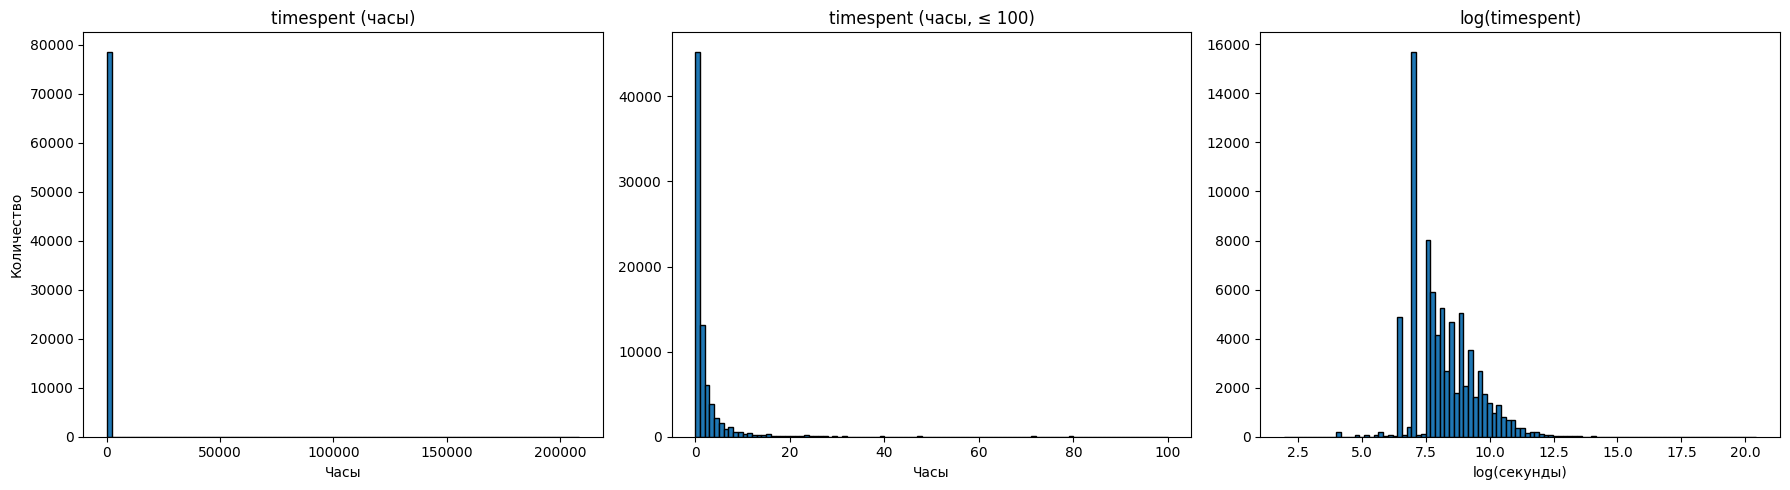

Перцентили timespent (часы):
  1%: 0.17 ч
  5%: 0.17 ч
  10%: 0.33 ч
  25%: 0.33 ч
  50%: 0.83 ч
  75%: 2.17 ч
  90%: 5.33 ч
  95%: 9.17 ч
  99%: 28.50 ч

Задач > 100 часов: 112
Задач > 500 часов: 10
Задач < 1 минуты:  3


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Распределение timespent в часах
hours = df["timespent"] / 3600
axes[0].hist(hours, bins=100, edgecolor="black")
axes[0].set_title("timespent (часы)")
axes[0].set_xlabel("Часы")
axes[0].set_ylabel("Количество")

# 2. То же, но обрезано до 100 часов
axes[1].hist(hours[hours <= 100], bins=100, edgecolor="black")
axes[1].set_title("timespent (часы, ≤ 100)")
axes[1].set_xlabel("Часы")

# 3. Распределение log(timespent)
axes[2].hist(df["log_timespent"], bins=100, edgecolor="black")
axes[2].set_title("log(timespent)")
axes[2].set_xlabel("log(секунды)")

plt.tight_layout()
plt.show()

# Ключевые перцентили
print("Перцентили timespent (часы):")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(hours, p)
    print(f"  {p}%: {val:.2f} ч")

print(f"\nЗадач > 100 часов: {(hours > 100).sum()}")
print(f"Задач > 500 часов: {(hours > 500).sum()}")
print(f"Задач < 1 минуты:  {(df['timespent'] < 60).sum()}")

### Очистка от выбросов, хвост с большим временем всё портит 

In [11]:
hours = df["timespent"] / 3600
df_clean = df[(df["timespent"] >= 60) & (hours <= 100)].copy()

print(f"Было: {len(df)}")
print(f"Стало: {len(df_clean)}")
print(f"Убрано: {len(df) - len(df_clean)}")

print(f"\ntimespent (часы) после фильтрации:")
print((df_clean["timespent"] / 3600).describe())

Было: 78634
Стало: 78519
Убрано: 115

timespent (часы) после фильтрации:
count    78519.000000
mean         2.421864
std          5.505470
min          0.016667
25%          0.333333
50%          0.833333
75%          2.166667
max        100.000000
Name: timespent, dtype: float64


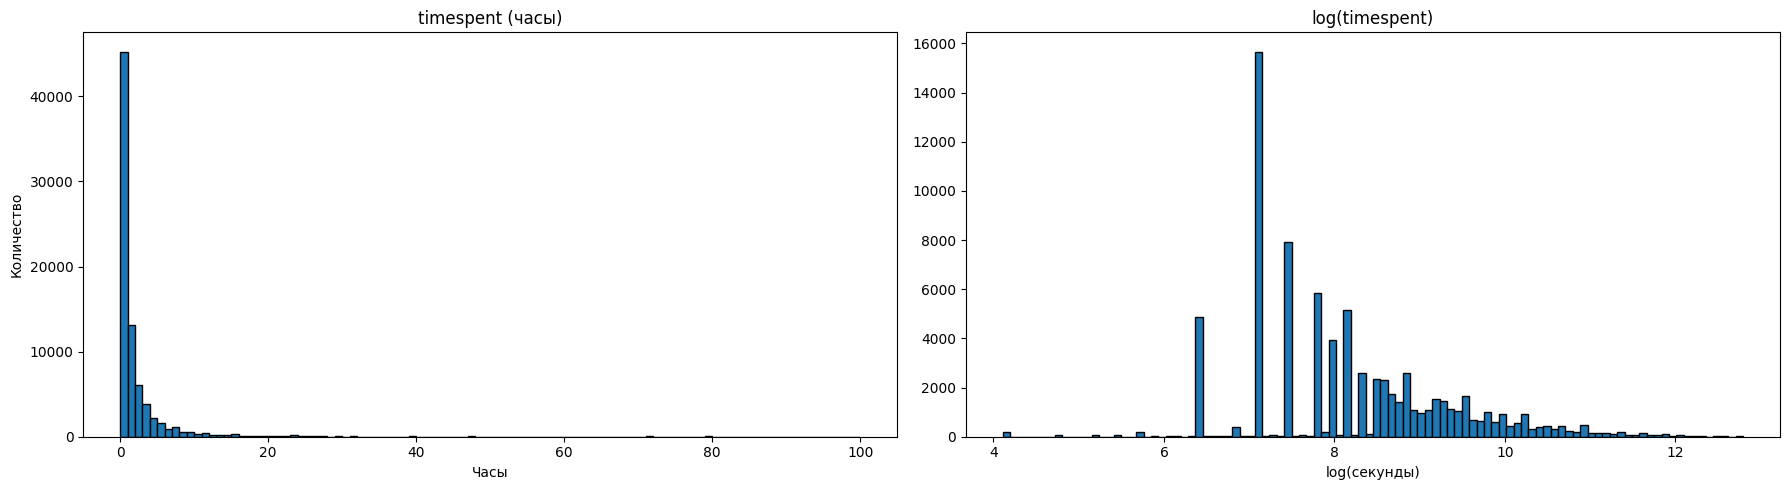

Перцентили timespent (часы):
  1%: 0.17 ч
  5%: 0.17 ч
  10%: 0.33 ч
  25%: 0.33 ч
  50%: 0.83 ч
  75%: 2.17 ч
  90%: 5.17 ч
  95%: 9.00 ч
  99%: 25.47 ч

Задач > 100 часов: 0
Задач > 500 часов: 0
Задач < 1 минуты:  0


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Распределение timespent в часах
hours = df_clean["timespent"] / 3600
axes[0].hist(hours, bins=100, edgecolor="black")
axes[0].set_title("timespent (часы)")
axes[0].set_xlabel("Часы")
axes[0].set_ylabel("Количество")

# 3. Распределение log(timespent)
axes[1].hist(df_clean["log_timespent"], bins=100, edgecolor="black")
axes[1].set_title("log(timespent)")
axes[1].set_xlabel("log(секунды)")

plt.tight_layout()
plt.show()

# Ключевые перцентили
print("Перцентили timespent (часы):")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(hours, p)
    print(f"  {p}%: {val:.2f} ч")

print(f"\nЗадач > 100 часов: {(hours > 100).sum()}")
print(f"Задач > 500 часов: {(hours > 500).sum()}")
print(f"Задач < 1 минуты:  {(df_clean['timespent'] < 60).sum()}")

### Количество задач на проект

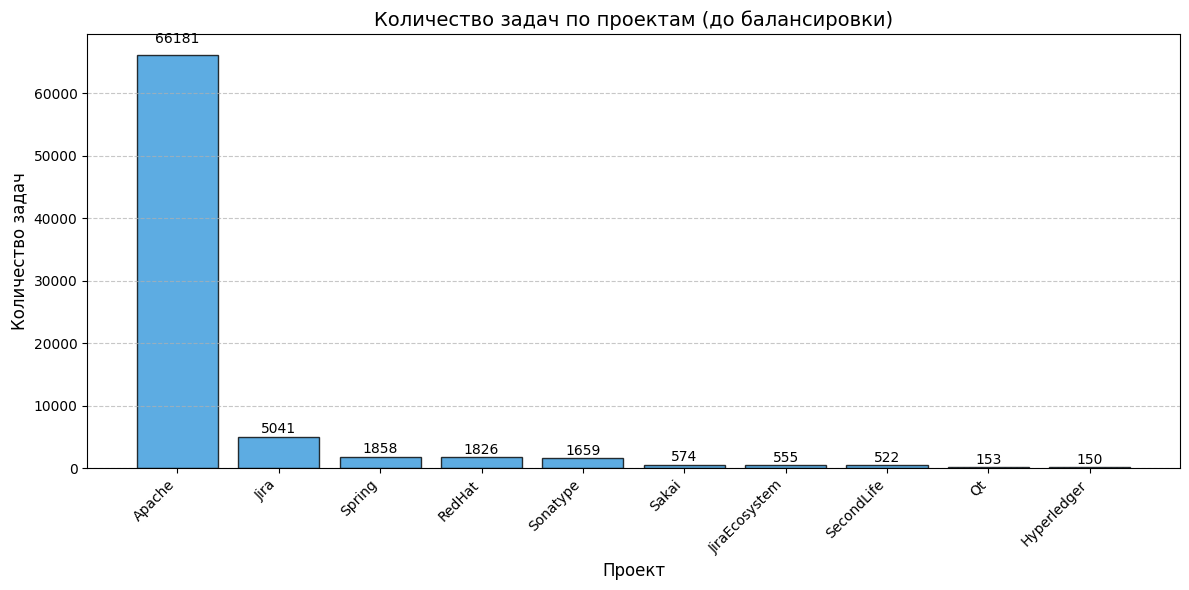

In [11]:
import matplotlib.pyplot as plt

# Считаем количество задач в каждом проекте и сортируем по убыванию
project_counts = df_clean["source_collection"].value_counts()

# Создаём график
fig, ax = plt.subplots(figsize=(12, 6))

# Строим столбчатую диаграмму
bars = ax.bar(project_counts.index, project_counts.values, color="#3498db", edgecolor="black", alpha=0.8)

# Добавляем подписи с точным количеством над каждым столбцом
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        height + (height * 0.02),  # Чуть выше столбца
        f'{int(height)}', 
        ha='center', 
        va='bottom', 
        fontsize=10
    )

# Настройка осей и заголовка
ax.set_title("Количество задач по проектам (до балансировки)", fontsize=14)
ax.set_xlabel("Проект", fontsize=12)
ax.set_ylabel("Количество задач", fontsize=12)

# Поворачиваем названия проектов для читаемости
plt.xticks(rotation=45, ha="right")

# Добавляем горизонтальную сетку
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Убираем лишние отступы
plt.tight_layout()

# Показываем график
plt.show()

In [ ]:
df_clean["log_timespent"] = np.log1p(df_clean["timespent"])

X_train, X_test, y_train, y_test = train_test_split(
    df_clean["text"],
    df_clean["log_timespent"],
    test_size=0.2,
    random_state=42
)

In [13]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = Ridge(alpha=10.0)
model.fit(X_train_tfidf, y_train)

y_pred_log = model.predict(X_test_tfidf)

print("\n===== Метрики (log-пространство) =====")
print(f"R²:   {r2_score(y_test, y_pred_log):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_log):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_log)):.4f}")

y_test_sec = np.expm1(y_test)
y_pred_sec = np.expm1(y_pred_log)

print("\n===== Метрики (секунды → часы) =====")
print(f"R²:    {r2_score(y_test_sec, y_pred_sec):.4f}")
mae_h = mean_absolute_error(y_test_sec, y_pred_sec) / 3600
rmse_h = np.sqrt(mean_squared_error(y_test_sec, y_pred_sec)) / 3600
med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
print(f"MAE:   {mae_h:.2f} ч")
print(f"RMSE:  {rmse_h:.2f} ч")
print(f"MedAE: {med_h:.2f} ч")

mask = y_test_sec > 600
if mask.sum() > 0:
    mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100
    print(f"\nMedian APE (задачи > 10 мин): {mape:.1f}%")


===== Метрики (log-пространство) =====
R²:   0.1823
MAE:  0.8541
RMSE: 1.0894

===== Метрики (секунды → часы) =====
R²:    -0.0066
MAE:   1.86 ч
RMSE:  5.51 ч
MedAE: 0.58 ч

Median APE (задачи > 10 мин): 61.8%


## TF-IDS + LightGBM

In [51]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.5,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train_tfidf,
    y_train,
    eval_set=[(X_test_tfidf, y_test)],
    callbacks=[
        __import__("lightgbm").early_stopping(50),
        __import__("lightgbm").log_evaluation(100)
    ]
)

y_pred_log = lgbm.predict(X_test_tfidf)

print("\n===== LightGBM — Метрики (log-пространство) =====")
print(f"R²:   {r2_score(y_test, y_pred_log):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_log):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_log)):.4f}")

y_test_sec = np.expm1(y_test)
y_pred_sec = np.expm1(y_pred_log)

print("\n===== LightGBM — Метрики (секунды → часы) =====")
print(f"R²:    {r2_score(y_test_sec, y_pred_sec):.4f}")
mae_h = mean_absolute_error(y_test_sec, y_pred_sec) / 3600
rmse_h = np.sqrt(mean_squared_error(y_test_sec, y_pred_sec)) / 3600
med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
print(f"MAE:   {mae_h:.2f} ч")
print(f"RMSE:  {rmse_h:.2f} ч")
print(f"MedAE: {med_h:.2f} ч")

mask = y_test_sec > 600
if mask.sum() > 0:
    mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100
    print(f"\nMedian APE (задачи > 10 мин): {mape:.1f}%")

print(f"\nBest iteration: {lgbm.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 1.28151
[200]	valid_0's l2: 1.24836
[300]	valid_0's l2: 1.23143
[400]	valid_0's l2: 1.22092
[500]	valid_0's l2: 1.21253
[600]	valid_0's l2: 1.20675
[700]	valid_0's l2: 1.20218
[800]	valid_0's l2: 1.19871
[900]	valid_0's l2: 1.19515
[1000]	valid_0's l2: 1.1924
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 1.1924

===== LightGBM — Метрики (log-пространство) =====
R²:   0.1783
MAE:  0.8547
RMSE: 1.0920

===== LightGBM — Метрики (секунды → часы) =====
R²:    0.0031
MAE:   1.85 ч
RMSE:  5.48 ч
MedAE: 0.58 ч

Median APE (задачи > 10 мин): 61.7%

Best iteration: 1000


c:\Users\maxgo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Эмбеддинги + Ridge/LGMB

In [52]:
from sentence_transformers import SentenceTransformer

# ---------- 1. Эмбеддинги ----------

st_model = SentenceTransformer("all-MiniLM-L6-v2")

texts_train = X_train.tolist()
texts_test = X_test.tolist()

print("Кодируем train...")
emb_train = st_model.encode(
    texts_train,
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Кодируем test...")
emb_test = st_model.encode(
    texts_test,
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(f"\nРазмерность эмбеддингов: {emb_train.shape}")

# ---------- 2. Ridge на эмбеддингах ----------

from sklearn.linear_model import Ridge

ridge_emb = Ridge(alpha=10.0)
ridge_emb.fit(emb_train, y_train)

y_pred_log = ridge_emb.predict(emb_test)

print("\n===== Ridge + SentenceEmb — log-пространство =====")
print(f"R²:   {r2_score(y_test, y_pred_log):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_log):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_log)):.4f}")

y_test_sec = np.expm1(y_test)
y_pred_sec = np.expm1(y_pred_log)

print("\n===== Ridge + SentenceEmb — часы =====")
print(f"R²:    {r2_score(y_test_sec, y_pred_sec):.4f}")
mae_h = mean_absolute_error(y_test_sec, y_pred_sec) / 3600
rmse_h = np.sqrt(mean_squared_error(y_test_sec, y_pred_sec)) / 3600
med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
print(f"MAE:   {mae_h:.2f} ч")
print(f"RMSE:  {rmse_h:.2f} ч")
print(f"MedAE: {med_h:.2f} ч")

mask = y_test_sec > 600
if mask.sum() > 0:
    mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100
    print(f"\nMedian APE (задачи > 10 мин): {mape:.1f}%")

# ---------- 3. LightGBM на эмбеддингах ----------

lgbm_emb = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.5,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_emb.fit(
    emb_train, y_train,
    eval_set=[(emb_test, y_test)],
    callbacks=[
        __import__("lightgbm").early_stopping(50),
        __import__("lightgbm").log_evaluation(200)
    ]
)

y_pred_log = lgbm_emb.predict(emb_test)

print("\n===== LightGBM + SentenceEmb — log-пространство =====")
print(f"R²:   {r2_score(y_test, y_pred_log):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_log):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_log)):.4f}")

y_pred_sec = np.expm1(y_pred_log)

print("\n===== LightGBM + SentenceEmb — часы =====")
print(f"R²:    {r2_score(y_test_sec, y_pred_sec):.4f}")
mae_h = mean_absolute_error(y_test_sec, y_pred_sec) / 3600
rmse_h = np.sqrt(mean_squared_error(y_test_sec, y_pred_sec)) / 3600
med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
print(f"MAE:   {mae_h:.2f} ч")
print(f"RMSE:  {rmse_h:.2f} ч")
print(f"MedAE: {med_h:.2f} ч")

mask = y_test_sec > 600
if mask.sum() > 0:
    mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100
    print(f"\nMedian APE (задачи > 10 мин): {mape:.1f}%")

print(f"\nBest iteration: {lgbm_emb.best_iteration_}")

c:\Users\maxgo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\maxgo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\maxgo\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to ru

Кодируем train...


Batches: 100%|██████████| 246/246 [12:28<00:00,  3.04s/it]


Кодируем test...


Batches: 100%|██████████| 62/62 [02:58<00:00,  2.88s/it]



Размерность эмбеддингов: (62815, 384)

===== Ridge + SentenceEmb — log-пространство =====
R²:   0.1192
MAE:  0.8927
RMSE: 1.1306

===== Ridge + SentenceEmb — часы =====
R²:    -0.0170
MAE:   1.90 ч
RMSE:  5.54 ч
MedAE: 0.62 ч

Median APE (задачи > 10 мин): 64.0%
Training until validation scores don't improve for 50 rounds
[200]	valid_0's l2: 1.25407
[400]	valid_0's l2: 1.23524
[600]	valid_0's l2: 1.22842
[800]	valid_0's l2: 1.22538
Early stopping, best iteration is:
[891]	valid_0's l2: 1.22417

===== LightGBM + SentenceEmb — log-пространство =====
R²:   0.1564
MAE:  0.8660
RMSE: 1.1064

===== LightGBM + SentenceEmb — часы =====
R²:    0.0046
MAE:   1.87 ч
RMSE:  5.48 ч
MedAE: 0.59 ч

Median APE (задачи > 10 мин): 62.0%

Best iteration: 891


c:\Users\maxgo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Применяем очистку текста

In [ ]:
df_clean["text_cleaned"] = (df_clean["summary"] + " " + df_clean["description"].fillna("")).apply(clean_text)

# Средняя длина текста
print(f"\nСредняя длина до:    {df_clean['text'].str.len().mean():.0f} символов")
print(f"Средняя длина после: {df_clean['text_cleaned'].str.len().mean():.0f} символов")
print(f"Сокращение:          {(1 - df_clean['text_cleaned'].str.len().mean() / df_clean['text'].str.len().mean()) * 100:.1f}%")

=== ДО ===
Fix the nexus-webapp maven-metadata.xml in central currently it's incorrect, since 1.4.0, nexus-webapp is not synced to central:

{noformat}
<?xml version="1.0" encoding="UTF-8"?>
<metadata>
  <groupId>org.sonatype.nexus</groupId>
  <artifactId>nexus-webapp</artifactId>
  <versioning>
    <latest>1.4.1</latest>
    <release>1.4.1</release>
    <versions>

      <version>1.0.0-beta-3</version>
      <version>1.0.0-beta-3.1</version>
      <version>1.0.0-beta-4</version>
      <vers

=== ПОСЛЕ ===
Fix the nexus-webapp maven-metadata.xml in central currently it's incorrect, since 1.4.0, nexus-webapp is not synced to central:

Средняя длина до:    873 символов
Средняя длина после: 393 символов
Сокращение:          55.0%


## TF-IDF + Ridge после чистки

In [17]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    df_clean["text_cleaned"],
    df_clean["log_timespent"],
    test_size=0.2,
    random_state=42
)

# ---------- TF-IDF ----------

tfidf_c = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf_c = tfidf_c.fit_transform(X_train_c)
X_test_tfidf_c = tfidf_c.transform(X_test_c)

print(f"TF-IDF размерность: до чистки {X_train_tfidf.shape[1]}, после чистки {X_train_tfidf_c.shape[1]}")

# ---------- Ridge ----------

ridge_c = Ridge(alpha=10.0)
ridge_c.fit(X_train_tfidf_c, y_train_c)

y_pred_log = ridge_c.predict(X_test_tfidf_c)

print("\n===== Ridge + TF-IDF (очищенный текст) — log =====")
print(f"R²:   {r2_score(y_test_c, y_pred_log):.4f}")
print(f"MAE:  {mean_absolute_error(y_test_c, y_pred_log):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_c, y_pred_log)):.4f}")

y_test_sec = np.expm1(y_test_c)
y_pred_sec = np.expm1(y_pred_log)

print("\n===== Ridge + TF-IDF (очищенный текст) — часы =====")
print(f"R²:    {r2_score(y_test_sec, y_pred_sec):.4f}")
mae_h = mean_absolute_error(y_test_sec, y_pred_sec) / 3600
rmse_h = np.sqrt(mean_squared_error(y_test_sec, y_pred_sec)) / 3600
med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
print(f"MAE:   {mae_h:.2f} ч")
print(f"RMSE:  {rmse_h:.2f} ч")
print(f"MedAE: {med_h:.2f} ч")

mask = y_test_sec > 600
if mask.sum() > 0:
    mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100
    print(f"\nMedian APE (задачи > 10 мин): {mape:.1f}%")

TF-IDF размерность: до чистки 50000, после чистки 50000

===== Ridge + TF-IDF (очищенный текст) — log =====
R²:   0.1631
MAE:  0.8681
RMSE: 1.1021

===== Ridge + TF-IDF (очищенный текст) — часы =====
R²:    -0.0125
MAE:   1.87 ч
RMSE:  5.52 ч
MedAE: 0.59 ч

Median APE (задачи > 10 мин): 63.7%


In [18]:
# ---------- Сравнительная таблица ----------
print("\n===== СВОДКА =====")
print(f"{'Модель':<35} {'R²(log)':>8} {'MedAE(ч)':>9} {'MdAPE':>7}")
print("-" * 62)
print(f"{'TF-IDF + Ridge (сырой)':<35} {'0.1823':>8} {'0.58':>9} {'61.8%':>7}")
print(f"{'TF-IDF + LightGBM (сырой)':<35} {'0.1783':>8} {'0.58':>9} {'61.7%':>7}")
print(f"{'SentEmb + Ridge':<35} {'0.1192':>8} {'0.62':>9} {'64.0%':>7}")
print(f"{'SentEmb + LightGBM':<35} {'0.1564':>8} {'0.59':>9} {'62.0%':>7}")
print(f"{'TF-IDF + Ridge (очищенный)':<35} {r2_score(y_test_c, ridge_c.predict(X_test_tfidf_c)):>8.4f} {med_h:>9.2f} {mape:>6.1f}%")


===== СВОДКА =====
Модель                               R²(log)  MedAE(ч)   MdAPE
--------------------------------------------------------------
TF-IDF + Ridge (сырой)                0.1823      0.58   61.8%
TF-IDF + LightGBM (сырой)             0.1783      0.58   61.7%
SentEmb + Ridge                       0.1192      0.62   64.0%
SentEmb + LightGBM                    0.1564      0.59   62.0%
TF-IDF + Ridge (очищенный)            0.1631      0.59   63.7%


## TF-IDF + CatBoost

In [17]:
from catboost import CatBoostRegressor, Pool

# ---------- CatBoost на TF-IDF (сырой текст) ----------

train_pool = Pool(X_train_tfidf, label=y_train)
test_pool = Pool(X_test_tfidf, label=y_test)

catboost = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    verbose=100,
    task_type="CPU",
    random_seed=42,
    early_stopping_rounds=50
)

catboost.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True
)

# ---------- Метрики ----------

y_pred_log = catboost.predict(X_test_tfidf)

print("\n===== CatBoost + TF-IDF (сырой) — log =====")
print(f"R²:   {r2_score(y_test, y_pred_log):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_log):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_log)):.4f}")

y_test_sec = np.expm1(y_test)
y_pred_sec = np.expm1(y_pred_log)

print("\n===== CatBoost + TF-IDF (сырой) — часы =====")
r2_sec = r2_score(y_test_sec, y_pred_sec)
mae_h = mean_absolute_error(y_test_sec, y_pred_sec) / 3600
rmse_h = np.sqrt(mean_squared_error(y_test_sec, y_pred_sec)) / 3600
med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
print(f"R²:    {r2_sec:.4f}")
print(f"MAE:   {mae_h:.2f} ч")
print(f"RMSE:  {rmse_h:.2f} ч")
print(f"MedAE: {med_h:.2f} ч")

mask = y_test_sec > 600
if mask.sum() > 0:
    mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100
    print(f"\nMedian APE (задачи > 10 мин): {mape:.1f}%")

print(f"\nBest iteration: {catboost.best_iteration_}")

# ---------- Обновлённая сводка ----------
print("\n===== СВОДКА =====")
print(f"{'Модель':<35} {'R²(log)':>8} {'MedAE(ч)':>9} {'MdAPE':>7}")
print("-" * 62)
print(f"{'TF-IDF + Ridge (сырой)':<35} {'0.1823':>8} {'0.58':>9} {'61.8%':>7}")
print(f"{'TF-IDF + LightGBM (сырой)':<35} {'0.1783':>8} {'0.58':>9} {'61.7%':>7}")
print(f"{'SentEmb + Ridge':<35} {'0.1192':>8} {'0.62':>9} {'64.0%':>7}")
print(f"{'SentEmb + LightGBM':<35} {'0.1564':>8} {'0.59':>9} {'62.0%':>7}")
print(f"{'TF-IDF + Ridge (очищенный)':<35} {'0.1631':>8} {'0.59':>9} {'63.7%':>7}")
print(f"{'TF-IDF + CatBoost (сырой)':<35} {r2_score(y_test, y_pred_log):>8.4f} {med_h:>9.2f} {mape:>6.1f}%")

0:	learn: 1.2085083	test: 1.2022260	best: 1.2022260 (0)	total: 691ms	remaining: 11m 30s
100:	learn: 1.1527458	test: 1.1465955	best: 1.1465955 (100)	total: 1m 6s	remaining: 9m 55s
200:	learn: 1.1357561	test: 1.1328520	best: 1.1328520 (200)	total: 2m 19s	remaining: 9m 13s
300:	learn: 1.1207324	test: 1.1229793	best: 1.1229793 (300)	total: 3m 23s	remaining: 7m 52s
400:	learn: 1.1081356	test: 1.1164113	best: 1.1164113 (400)	total: 4m 28s	remaining: 6m 40s
500:	learn: 1.0980637	test: 1.1116657	best: 1.1116353 (499)	total: 5m 31s	remaining: 5m 30s
600:	learn: 1.0894325	test: 1.1082787	best: 1.1082751 (599)	total: 6m 34s	remaining: 4m 21s
700:	learn: 1.0815182	test: 1.1054191	best: 1.1054191 (700)	total: 7m 37s	remaining: 3m 15s
800:	learn: 1.0742882	test: 1.1031015	best: 1.1031015 (800)	total: 8m 40s	remaining: 2m 9s
900:	learn: 1.0676203	test: 1.1015272	best: 1.1015272 (900)	total: 9m 48s	remaining: 1m 4s
999:	learn: 1.0621664	test: 1.0997514	best: 1.0997382 (997)	total: 11m 3s	remaining: 0u

## CatBoost без TF-IDF

In [20]:
from catboost import CatBoostRegressor, Pool

# ---------- Подготовка данных для CatBoost text features ----------

import pandas as pd

train_idx, test_idx = train_test_split(
    df_clean.index,
    test_size=0.2,
    random_state=42
)

train_data = pd.DataFrame({
    "summary": df_clean.loc[train_idx, "summary"].values,
    "description": df_clean.loc[train_idx, "description"].fillna("").values
})

test_data = pd.DataFrame({
    "summary": df_clean.loc[test_idx, "summary"].values,
    "description": df_clean.loc[test_idx, "description"].fillna("").values
})

y_train_cb = df_clean.loc[train_idx, "log_timespent"].values
y_test_cb = df_clean.loc[test_idx, "log_timespent"].values

train_pool = Pool(
    train_data,
    label=y_train_cb,
    text_features=["summary", "description"]
)

test_pool = Pool(
    test_data,
    label=y_test_cb,
    text_features=["summary", "description"]
)

# ---------- Обучение ----------

catboost_text = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    random_seed=42,
    early_stopping_rounds=100,
    verbose=200,
    task_type="CPU",
    tokenizers=[
        {"tokenizer_id": "Space", "separator_type": "ByDelimiter", "delimiter": " "}
    ],
    dictionaries=[
        {"dictionary_id": "Word", "gram_order": "1"},
        {"dictionary_id": "Bigram", "gram_order": "2"}
    ],
    feature_calcers=[
        "BoW:top_tokens_count=10000",
    ]
)

catboost_text.fit(train_pool, eval_set=test_pool)

# ---------- Метрики ----------

y_pred_log = catboost_text.predict(test_data)

print("\n===== CatBoost (text features) — log =====")
print(f"R²:   {r2_score(y_test_cb, y_pred_log):.4f}")
print(f"MAE:  {mean_absolute_error(y_test_cb, y_pred_log):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_cb, y_pred_log)):.4f}")

y_test_sec = np.expm1(y_test_cb)
y_pred_sec = np.expm1(y_pred_log)

print("\n===== CatBoost (text features) — часы =====")
r2_sec = r2_score(y_test_sec, y_pred_sec)
mae_h = mean_absolute_error(y_test_sec, y_pred_sec) / 3600
rmse_h = np.sqrt(mean_squared_error(y_test_sec, y_pred_sec)) / 3600
med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
print(f"R²:    {r2_sec:.4f}")
print(f"MAE:   {mae_h:.2f} ч")
print(f"RMSE:  {rmse_h:.2f} ч")
print(f"MedAE: {med_h:.2f} ч")

mask = y_test_sec > 600
if mask.sum() > 0:
    mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100
    print(f"\nMedian APE (задачи > 10 мин): {mape:.1f}%")

print(f"\nBest iteration: {catboost_text.best_iteration_}")

# ---------- Сводка ----------
print("\n===== СВОДКА =====")
print(f"{'Модель':<35} {'R²(log)':>8} {'MedAE(ч)':>9} {'MdAPE':>7}")
print("-" * 62)
print(f"{'TF-IDF + Ridge':<35} {'0.1823':>8} {'0.58':>9} {'61.8%':>7}")
print(f"{'TF-IDF + LightGBM':<35} {'0.1783':>8} {'0.58':>9} {'61.7%':>7}")
print(f"{'TF-IDF + CatBoost':<35} {'0.1666':>8} {'0.58':>9} {'63.0%':>7}")
print(f"{'SentEmb + Ridge':<35} {'0.1192':>8} {'0.62':>9} {'64.0%':>7}")
print(f"{'SentEmb + LightGBM':<35} {'0.1564':>8} {'0.59':>9} {'62.0%':>7}")
print(f"{'TF-IDF + Ridge (очищенный)':<35} {'0.1631':>8} {'0.59':>9} {'63.7%':>7}")
print(f"{'CatBoost (text features)':<35} {r2_score(y_test_cb, y_pred_log):>8.4f} {med_h:>9.2f} {mape:>6.1f}%")

0:	learn: 1.2099472	test: 1.2037324	best: 1.2037324 (0)	total: 417ms	remaining: 13m 52s
200:	learn: 1.1702539	test: 1.1680398	best: 1.1680398 (200)	total: 1m 43s	remaining: 15m 29s
400:	learn: 1.1476336	test: 1.1527002	best: 1.1527002 (400)	total: 3m 24s	remaining: 13m 35s
600:	learn: 1.1323619	test: 1.1440868	best: 1.1440868 (600)	total: 5m 10s	remaining: 12m 3s
800:	learn: 1.1203728	test: 1.1383426	best: 1.1383426 (800)	total: 6m 58s	remaining: 10m 26s
1000:	learn: 1.1101129	test: 1.1345546	best: 1.1345546 (1000)	total: 8m 46s	remaining: 8m 45s
1200:	learn: 1.1008137	test: 1.1316534	best: 1.1316534 (1200)	total: 10m 42s	remaining: 7m 7s
1400:	learn: 1.0926055	test: 1.1293650	best: 1.1293641 (1398)	total: 12m 49s	remaining: 5m 28s
1600:	learn: 1.0850603	test: 1.1274775	best: 1.1274775 (1600)	total: 14m 45s	remaining: 3m 40s
1800:	learn: 1.0780044	test: 1.1257613	best: 1.1257613 (1800)	total: 16m 45s	remaining: 1m 51s
1999:	learn: 1.0713914	test: 1.1242468	best: 1.1242381 (1993)	total:

## TF-IDF - стоп-слова + Ridge

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
stop_words = stopwords.words("english")
punctuation = set(string.punctuation)

# TF-IDF со стоп-словами
tfidf_stop = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    stop_words=stop_words
)

X_tr = tfidf_stop.fit_transform(X_train)
X_te = tfidf_stop.transform(X_test)

ridge_stop = Ridge(alpha=10.0)
ridge_stop.fit(X_tr, y_train)
y_pred = ridge_stop.predict(X_te)

y_test_sec = np.expm1(y_test)
y_pred_sec = np.expm1(y_pred)
med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
mask = y_test_sec > 600
mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100

print(f"TF-IDF + Ridge (стоп-слова)")
print(f"R² (log): {r2_score(y_test, y_pred):.4f}")
print(f"MedAE:    {med_h:.2f} ч")
print(f"MdAPE:    {mape:.1f}%")
print(f"Фич:      {X_tr.shape[1]}")

# ---------- Финальная сводка ----------
print("\n===== ИТОГОВАЯ СВОДКА BASELINE =====")
print(f"{'Модель':<35} {'R²(log)':>8} {'MedAE(ч)':>9} {'MdAPE':>7}")
print("-" * 62)
print(f"{'TF-IDF + Ridge ★':<35} {'0.1823':>8} {'0.58':>9} {'61.8%':>7}")
print(f"{'TF-IDF + LightGBM':<35} {'0.1783':>8} {'0.58':>9} {'61.7%':>7}")
print(f"{'TF-IDF + CatBoost':<35} {'0.1666':>8} {'0.58':>9} {'63.0%':>7}")
print(f"{'SentEmb + Ridge':<35} {'0.1192':>8} {'0.62':>9} {'64.0%':>7}")
print(f"{'SentEmb + LightGBM':<35} {'0.1564':>8} {'0.59':>9} {'62.0%':>7}")
print(f"{'TF-IDF + Ridge (очищенный)':<35} {'0.1631':>8} {'0.59':>9} {'63.7%':>7}")
print(f"{'CatBoost (text features)':<35} {'0.1291':>8} {'0.59':>9} {'66.1%':>7}")
print(f"{'TF-IDF + Ridge (стоп-слова)':<35} {r2_score(y_test, y_pred):>8.4f} {med_h:>9.2f} {mape:>6.1f}%")
print("\n★ = лучшая модель")

TF-IDF + Ridge (стоп-слова)
R² (log): 0.1867
MedAE:    0.58 ч
MdAPE:    61.7%
Фич:      50000

===== ИТОГОВАЯ СВОДКА BASELINE =====
Модель                               R²(log)  MedAE(ч)   MdAPE
--------------------------------------------------------------
TF-IDF + Ridge ★                      0.1823      0.58   61.8%
TF-IDF + LightGBM                     0.1783      0.58   61.7%
TF-IDF + CatBoost                     0.1666      0.58   63.0%
SentEmb + Ridge                       0.1192      0.62   64.0%
SentEmb + LightGBM                    0.1564      0.59   62.0%
TF-IDF + Ridge (очищенный)            0.1631      0.59   63.7%
CatBoost (text features)              0.1291      0.59   66.1%
TF-IDF + Ridge (стоп-слова)           0.1867      0.58   61.7%

★ = лучшая модель


## Полная предобработка с TF-IDF + Ridge

In [25]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
import re

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
tokenizer = RegexpTokenizer(r'[a-zA-Z]{2,}')  # только слова от 2 букв, без цифр и спецсимволов

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # Нижний регистр
    text = text.lower()
    
    # Убираем URL
    text = re.sub(r'https?://\S+', ' ', text)
    
    # Убираем email
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Токенизация (только буквы, 2+ символов)
    tokens = tokenizer.tokenize(text)
    
    # Убираем стоп-слова + лемматизация
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    
    return " ".join(tokens)

# ---------- Применяем ----------

print("Обработка текстов...")
from tqdm import tqdm
tqdm.pandas()

df_clean["text_processed"] = (
    df_clean["summary"].fillna("") + " " + df_clean["description"].fillna("")
).progress_apply(preprocess_text)

print(f"\nПример:")
idx = df_clean.index[0]
print(f"ДО:    {(df_clean.loc[idx, 'summary'] + ' ' + str(df_clean.loc[idx, 'description']))[:200]}")
print(f"ПОСЛЕ: {df_clean.loc[idx, 'text_processed'][:200]}")

print(f"\nСредняя длина до:    {df_clean['text'].str.len().mean():.0f} символов")
print(f"Средняя длина после: {df_clean['text_processed'].str.len().mean():.0f} символов")

# ---------- Обучение Ridge ----------

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    df_clean["text_processed"],
    df_clean["log_timespent"],
    test_size=0.2,
    random_state=42
)

tfidf_p = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_tr_p = tfidf_p.fit_transform(X_train_p)
X_te_p = tfidf_p.transform(X_test_p)

print(f"\nTF-IDF фич: {X_tr_p.shape[1]}")

ridge_p = Ridge(alpha=10.0)
ridge_p.fit(X_tr_p, y_train_p)
y_pred_p = ridge_p.predict(X_te_p)

y_test_sec = np.expm1(y_test_p)
y_pred_sec = np.expm1(y_pred_p)
med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
mask = y_test_sec > 600
mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100

print(f"\n===== TF-IDF + Ridge (лемматизация + стоп-слова + lowercase) =====")
print(f"R² (log): {r2_score(y_test_p, y_pred_p):.4f}")
print(f"MedAE:    {med_h:.2f} ч")
print(f"MdAPE:    {mape:.1f}%")

# ---------- Сводка ----------
print("\n===== ИТОГОВАЯ СВОДКА =====")
print(f"{'Модель':<40} {'R²(log)':>8} {'MedAE(ч)':>9} {'MdAPE':>7}")
print("-" * 67)
print(f"{'TF-IDF + Ridge (сырой) ★':<40} {'0.1823':>8} {'0.58':>9} {'61.8%':>7}")
print(f"{'TF-IDF + LightGBM (сырой)':<40} {'0.1783':>8} {'0.58':>9} {'61.7%':>7}")
print(f"{'TF-IDF + CatBoost (сырой)':<40} {'0.1666':>8} {'0.58':>9} {'63.0%':>7}")
print(f"{'SentEmb + Ridge':<40} {'0.1192':>8} {'0.62':>9} {'64.0%':>7}")
print(f"{'SentEmb + LightGBM':<40} {'0.1564':>8} {'0.59':>9} {'62.0%':>7}")
print(f"{'TF-IDF + Ridge (очищенный)':<40} {'0.1631':>8} {'0.59':>9} {'63.7%':>7}")
print(f"{'CatBoost (text features)':<40} {'0.1291':>8} {'0.59':>9} {'66.1%':>7}")
print(f"{'TF-IDF + Ridge (стоп-слова)':<40} {'0.1867':>8} {'0.58':>9} {'61.7%':>7}")
r2_val = r2_score(y_test_p, y_pred_p)
print(f"{'TF-IDF + Ridge (lemma+stop+lower)':<40} {r2_val:>8.4f} {med_h:>9.2f} {mape:>6.1f}%")


Обработка текстов...


100%|██████████| 78519/78519 [00:17<00:00, 4504.73it/s]



Пример:
ДО:    Write a script to automate the mailing list subscription work 
ПОСЛЕ: write script automate mailing list subscription work

Средняя длина до:    873 символов
Средняя длина после: 603 символов

TF-IDF фич: 50000

===== TF-IDF + Ridge (лемматизация + стоп-слова + lowercase) =====
R² (log): 0.1781
MedAE:    0.58 ч
MdAPE:    62.4%

===== ИТОГОВАЯ СВОДКА =====
Модель                                    R²(log)  MedAE(ч)   MdAPE
-------------------------------------------------------------------
TF-IDF + Ridge (сырой) ★                   0.1823      0.58   61.8%
TF-IDF + LightGBM (сырой)                  0.1783      0.58   61.7%
TF-IDF + CatBoost (сырой)                  0.1666      0.58   63.0%
SentEmb + Ridge                            0.1192      0.62   64.0%
SentEmb + LightGBM                         0.1564      0.59   62.0%
TF-IDF + Ridge (очищенный)                 0.1631      0.59   63.7%
CatBoost (text features)                   0.1291      0.59   66.1%
TF-IDF + Ridge

## LOPO эксперимент

In [9]:
from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

projects = df_clean["source_collection"].unique()
print(f"Проекты ({len(projects)}): {list(projects)}")
print(f"Размеры:")
print(df_clean["source_collection"].value_counts())

results = []

for target_project in projects:
    print(f"\n{'='*60}")
    print(f"Целевой проект: {target_project}")
    print(f"{'='*60}")
    
    # ---- Разделение данных ----
    mask_target = df_clean["source_collection"] == target_project
    df_pretrain = df_clean[~mask_target]
    df_target = df_clean[mask_target]
    
    # 80/20 split целевого проекта
    from sklearn.model_selection import train_test_split
    df_finetune, df_test = train_test_split(
        df_target, test_size=0.2, random_state=42
    )
    
    print(f"Pretrain: {len(df_pretrain)}, Fine-tune: {len(df_finetune)}, Test: {len(df_test)}")
    
    # ---- TF-IDF на pretrain данных ----
    tfidf = TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True
    )
    
    X_pretrain = tfidf.fit_transform(df_pretrain["text"])
    y_pretrain = df_pretrain["log_timespent"].values
    
    X_finetune = tfidf.transform(df_finetune["text"])
    y_finetune = df_finetune["log_timespent"].values
    
    X_test = tfidf.transform(df_test["text"])
    y_test = df_test["log_timespent"].values
    
    y_test_sec = np.expm1(y_test)
    
    def calc_metrics(y_true_log, y_pred_log, y_true_sec=None):
        r2 = r2_score(y_true_log, y_pred_log)
        if y_true_sec is None:
            y_true_sec = np.expm1(y_true_log)
        y_pred_sec = np.expm1(y_pred_log)
        med_h = np.median(np.abs(y_true_sec - y_pred_sec)) / 3600
        mask = y_true_sec > 600
        if mask.sum() > 5:
            mape = np.median(np.abs(y_true_sec[mask] - y_pred_sec[mask]) / y_true_sec[mask]) * 100
        else:
            mape = np.nan
        return r2, med_h, mape
    
    # ---- 1. Pretrain Ridge (без дообучения) ----
    ridge_pre = Ridge(alpha=10.0)
    ridge_pre.fit(X_pretrain, y_pretrain)
    r2, med, mape = calc_metrics(y_test, ridge_pre.predict(X_test), y_test_sec)
    results.append({"project": target_project, "model": "1. Pretrain Ridge", 
                     "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  1. Pretrain Ridge:        R²={r2:.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # ---- 2. From scratch Ridge ----
    ridge_scratch = Ridge(alpha=10.0)
    ridge_scratch.fit(X_finetune, y_finetune)
    r2, med, mape = calc_metrics(y_test, ridge_scratch.predict(X_test), y_test_sec)
    results.append({"project": target_project, "model": "2. Scratch Ridge",
                     "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  2. Scratch Ridge:         R²={r2:.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # ---- 3. Retrain Ridge (pretrain + finetune, с весами) ----
    from scipy.sparse import vstack
    X_combined = vstack([X_pretrain, X_finetune])
    y_combined = np.concatenate([y_pretrain, y_finetune])
    weights = np.concatenate([
        np.ones(len(y_pretrain)),
        np.ones(len(y_finetune)) * 10  # вес ×10 для новых данных
    ])
    ridge_retrain = Ridge(alpha=10.0)
    ridge_retrain.fit(X_combined, y_combined, sample_weight=weights)
    r2, med, mape = calc_metrics(y_test, ridge_retrain.predict(X_test), y_test_sec)
    results.append({"project": target_project, "model": "3. Retrain Ridge (w=10)",
                     "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  3. Retrain Ridge (w=10):  R²={r2:.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # ---- 4. Pretrain SGD (без дообучения) ----
    sgd_pre = SGDRegressor(
        loss="squared_error", penalty="l2", alpha=1e-4,
        max_iter=1000, tol=1e-4, random_state=42
    )
    sgd_pre.fit(X_pretrain, y_pretrain)
    r2, med, mape = calc_metrics(y_test, sgd_pre.predict(X_test), y_test_sec)
    results.append({"project": target_project, "model": "4. Pretrain SGD",
                     "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  4. Pretrain SGD:          R²={r2:.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # ---- 5. Fine-tune SGD (pretrain → partial_fit) ----
    sgd_ft = SGDRegressor(
        loss="squared_error", penalty="l2", alpha=1e-4,
        max_iter=1000, tol=1e-4, random_state=42
    )
    sgd_ft.fit(X_pretrain, y_pretrain)
    # Дообучаем несколько эпох
    for _ in range(10):
        sgd_ft.partial_fit(X_finetune, y_finetune)
    r2, med, mape = calc_metrics(y_test, sgd_ft.predict(X_test), y_test_sec)
    results.append({"project": target_project, "model": "5. Fine-tune SGD",
                     "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  5. Fine-tune SGD:         R²={r2:.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # ---- 6. From scratch SGD ----
    sgd_scratch = SGDRegressor(
        loss="squared_error", penalty="l2", alpha=1e-4,
        max_iter=1000, tol=1e-4, random_state=42
    )
    sgd_scratch.fit(X_finetune, y_finetune)
    r2, med, mape = calc_metrics(y_test, sgd_scratch.predict(X_test), y_test_sec)
    results.append({"project": target_project, "model": "6. Scratch SGD",
                     "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  6. Scratch SGD:           R²={r2:.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")

# ---------- Итоговая сводка ----------

results_df = pd.DataFrame(results)
print("\n\n" + "="*70)
print("СРЕДНИЕ МЕТРИКИ ПО ВСЕМ ПРОЕКТАМ")
print("="*70)
summary = results_df.groupby("model").agg({
    "R2_log": "mean",
    "MedAE_h": "mean",
    "MdAPE": "mean"
}).round(4)
print(summary.to_string())

Проекты (10): ['Sonatype', 'SecondLife', 'RedHat', 'Spring', 'Qt', 'Sakai', 'Jira', 'JiraEcosystem', 'Apache', 'Hyperledger']
Размеры:
source_collection
Apache           66181
Jira              5041
Spring            1858
RedHat            1826
Sonatype          1659
Sakai              574
JiraEcosystem      555
SecondLife         522
Qt                 153
Hyperledger        150
Name: count, dtype: int64

Целевой проект: Sonatype
Pretrain: 76860, Fine-tune: 1327, Test: 332
  1. Pretrain Ridge:        R²=-0.0163  MedAE=0.83ч  MdAPE=66.8%
  2. Scratch Ridge:         R²=0.0958  MedAE=0.85ч  MdAPE=62.8%
  3. Retrain Ridge (w=10):  R²=0.1311  MedAE=0.86ч  MdAPE=58.3%
  4. Pretrain SGD:          R²=-0.0291  MedAE=0.82ч  MdAPE=66.2%
  5. Fine-tune SGD:         R²=-0.0204  MedAE=0.82ч  MdAPE=67.2%
  6. Scratch SGD:           R²=-0.6029  MedAE=1.02ч  MdAPE=72.3%

Целевой проект: SecondLife
Pretrain: 77997, Fine-tune: 417, Test: 105
  1. Pretrain Ridge:        R²=-0.3632  MedAE=2.45ч  MdAPE=83.

### Среднее (без Apache)

СРЕДНИЕ МЕТРИКИ БЕЗ APACHE
                           R2_log  MedAE_h     MdAPE
model                                               
1. Pretrain Ridge       -0.305300 2.869800 73.737200
2. Scratch Ridge         0.059100 2.145100 67.601200
3. Retrain Ridge (w=10)  0.004800 2.398300 67.330800
4. Pretrain SGD         -0.352200 2.876700 73.784800
5. Fine-tune SGD        -0.329300 2.864400 73.744900
6. Scratch SGD          -1.158700 3.138900 82.193900


СРЕДНИЕ МЕТРИКИ — МАЛЫЕ ПРОЕКТЫ (< 2000 задач)
                           R2_log  MedAE_h     MdAPE
model                                               
1. Pretrain Ridge       -0.343600 3.423900 73.029700
2. Scratch Ridge         0.041800 2.359700 67.023700
3. Retrain Ridge (w=10) -0.040500 2.828500 67.790400
4. Pretrain SGD         -0.384800 3.435900 72.998900
5. Fine-tune SGD        -0.374500 3.427500 73.127100
6. Scratch SGD          -1.594500 3.625000 85.156600


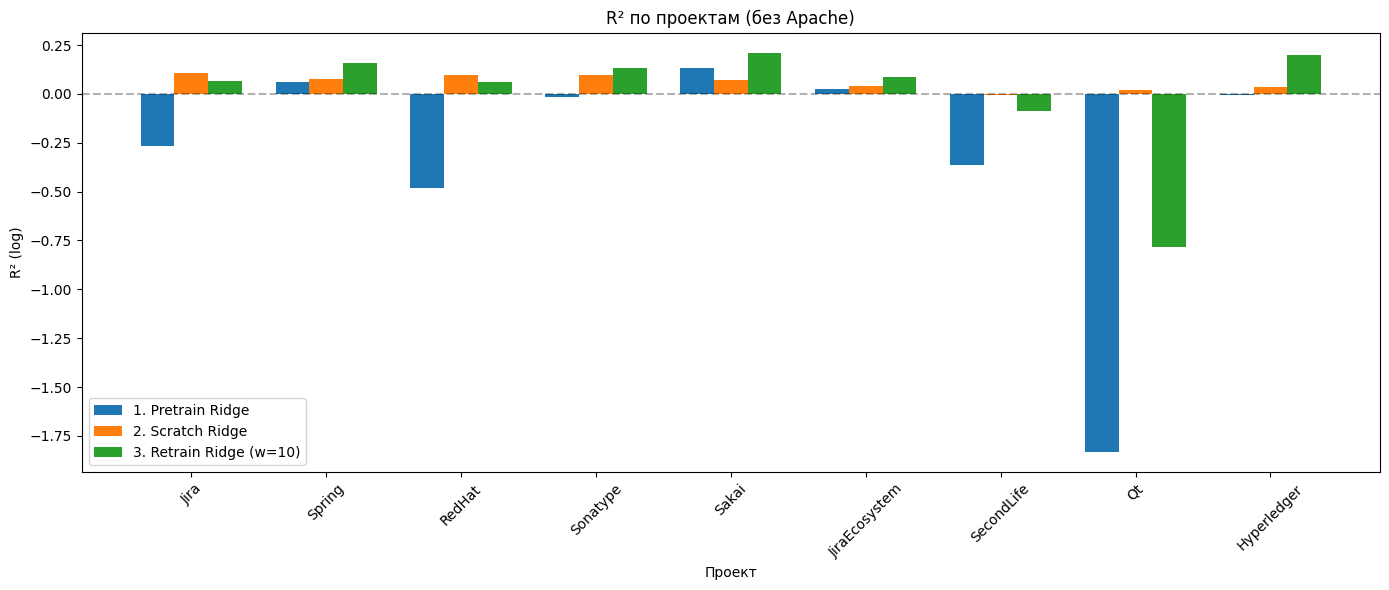

In [10]:
# Средние без Apache
results_no_apache = results_df[results_df["project"] != "Apache"]

print("СРЕДНИЕ МЕТРИКИ БЕЗ APACHE")
print("=" * 70)
summary_no_apache = results_no_apache.groupby("model").agg({
    "R2_log": "mean",
    "MedAE_h": "mean",
    "MdAPE": "mean"
}).round(4)
print(summary_no_apache.to_string())

# Отдельно: только малые проекты (< 2000 задач)
small_projects = ["Sonatype", "SecondLife", "Sakai", "JiraEcosystem", "Qt", "Hyperledger"]
results_small = results_df[results_df["project"].isin(small_projects)]

print("\n\nСРЕДНИЕ МЕТРИКИ — МАЛЫЕ ПРОЕКТЫ (< 2000 задач)")
print("=" * 70)
summary_small = results_small.groupby("model").agg({
    "R2_log": "mean",
    "MedAE_h": "mean",
    "MdAPE": "mean"
}).round(4)
print(summary_small.to_string())

# Визуализация R² по проектам
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

models_to_show = ["1. Pretrain Ridge", "2. Scratch Ridge", "3. Retrain Ridge (w=10)"]
projects_order = df_clean["source_collection"].value_counts().index.tolist()
# Убираем Apache для наглядности
projects_order = [p for p in projects_order if p != "Apache"]

x = np.arange(len(projects_order))
width = 0.25

for i, model in enumerate(models_to_show):
    vals = []
    for proj in projects_order:
        row = results_df[(results_df["project"] == proj) & (results_df["model"] == model)]
        vals.append(row["R2_log"].values[0])
    ax.bar(x + i * width, vals, width, label=model)

ax.set_xlabel("Проект")
ax.set_ylabel("R² (log)")
ax.set_title("R² по проектам (без Apache)")
ax.set_xticks(x + width)
ax.set_xticklabels(projects_order, rotation=45)
ax.legend()
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### Ограничение на Apache и динамические веса

In [12]:
# ---------- 1. Ограничиваем Apache ----------

max_per_project = df_clean[df_clean["source_collection"] != "Apache"]["source_collection"].value_counts().max()
print(f"Второй по размеру проект: {max_per_project} задач")

df_apache = df_clean[df_clean["source_collection"] == "Apache"].sample(
    n=max_per_project, random_state=42
)
df_other = df_clean[df_clean["source_collection"] != "Apache"]
df_balanced = pd.concat([df_other, df_apache]).reset_index(drop=True)

print(f"\nБыло: {len(df_clean)}")
print(f"Стало: {len(df_balanced)}")
print(f"\nРаспределение:")
print(df_balanced["source_collection"].value_counts())

Второй по размеру проект: 5041 задач

Было: 78519
Стало: 17379

Распределение:
source_collection
Jira             5041
Apache           5041
Spring           1858
RedHat           1826
Sonatype         1659
Sakai             574
JiraEcosystem     555
SecondLife        522
Qt                153
Hyperledger       150
Name: count, dtype: int64


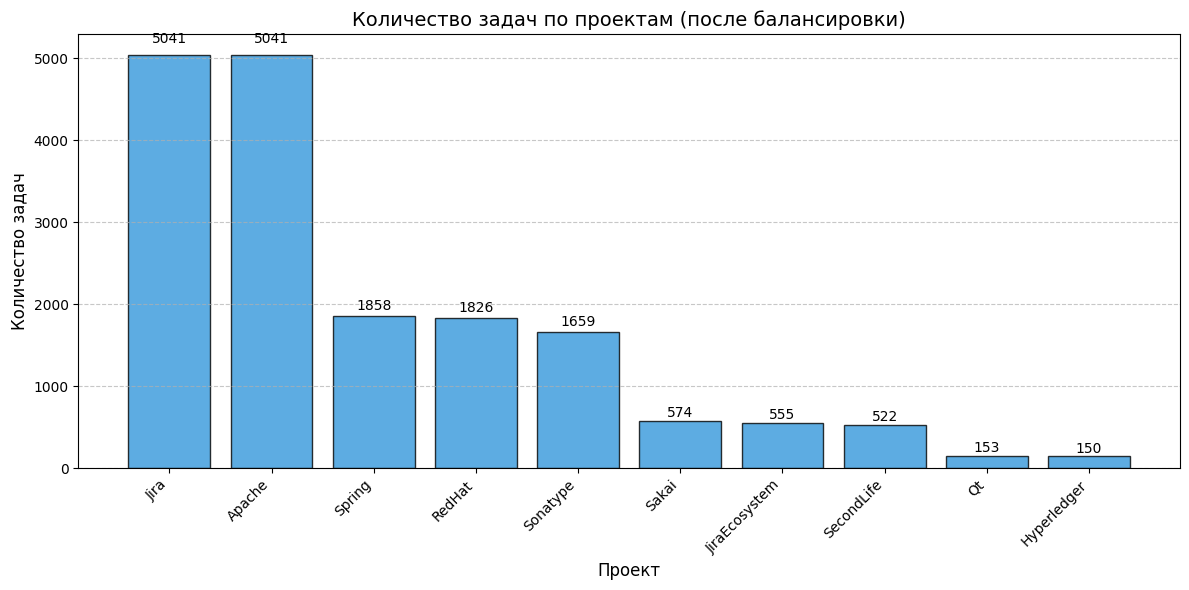

In [15]:
import matplotlib.pyplot as plt

# Считаем количество задач в каждом проекте и сортируем по убыванию
project_counts = df_balanced["source_collection"].value_counts()

# Создаём график
fig, ax = plt.subplots(figsize=(12, 6))

# Строим столбчатую диаграмму
bars = ax.bar(project_counts.index, project_counts.values, color="#3498db", edgecolor="black", alpha=0.8)

# Добавляем подписи с точным количеством над каждым столбцом
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        height + (height * 0.02),  # Чуть выше столбца
        f'{int(height)}', 
        ha='center', 
        va='bottom', 
        fontsize=10
    )

# Настройка осей и заголовка
ax.set_title("Количество задач по проектам (после балансировки)", fontsize=14)
ax.set_xlabel("Проект", fontsize=12)
ax.set_ylabel("Количество задач", fontsize=12)

# Поворачиваем названия проектов для читаемости
plt.xticks(rotation=45, ha="right")

# Добавляем горизонтальную сетку
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Убираем лишние отступы
plt.tight_layout()

# Показываем график
plt.show()

Второй по размеру проект: 5041 задач

Было: 78519
Стало: 17379

Распределение:
source_collection
Jira             5041
Apache           5041
Spring           1858
RedHat           1826
Sonatype         1659
Sakai             574
JiraEcosystem     555
SecondLife        522
Qt                153
Hyperledger       150
Name: count, dtype: int64

Sonatype: pretrain=15720, finetune=1327, test=332
  1. Pretrain:          R²=-0.0018  MedAE=1.10ч  MdAPE=70.7%
  2. Scratch:           R²= 0.0940  MedAE=0.85ч  MdAPE=64.3%
  3. Retrain adaptive:  R²= 0.1721  MedAE=0.96ч  MdAPE=60.6%  (w=11.8)

SecondLife: pretrain=16857, finetune=417, test=105
  1. Pretrain:          R²=-0.1545  MedAE=2.08ч  MdAPE=81.5%
  2. Scratch:           R²=-0.0063  MedAE=2.34ч  MdAPE=78.7%
  3. Retrain adaptive:  R²= 0.0183  MedAE=2.64ч  MdAPE=77.2%  (w=40.4)

RedHat: pretrain=15553, finetune=1460, test=366
  1. Pretrain:          R²=-0.2320  MedAE=2.23ч  MdAPE=78.7%
  2. Scratch:           R²= 0.0923  MedAE=2.52ч  MdAPE=73.

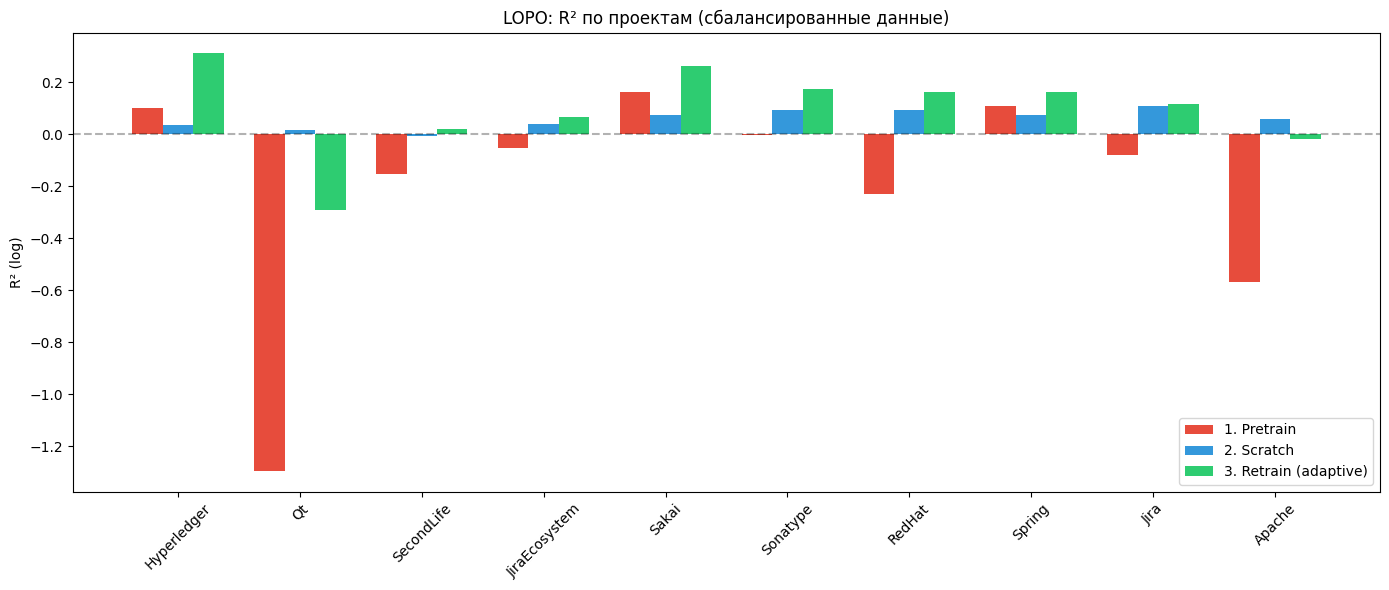

In [ ]:
# ---------- 2. LOPO с адаптивным весом ----------

from scipy.sparse import vstack

projects = df_balanced["source_collection"].unique()
results_all = []

for target_project in projects:
    mask_target = df_balanced["source_collection"] == target_project
    df_pretrain = df_balanced[~mask_target]
    df_target = df_balanced[mask_target]
    
    df_finetune, df_test = train_test_split(
        df_target, test_size=0.2, random_state=42
    )
    
    print(f"\n{'='*65}")
    print(f"{target_project}: pretrain={len(df_pretrain)}, finetune={len(df_finetune)}, test={len(df_test)}")
    print(f"{'='*65}")
    
    # TF-IDF на pretrain
    tfidf = TfidfVectorizer(
        max_features=50000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    
    X_pretrain = tfidf.fit_transform(df_pretrain["text"])
    y_pretrain = df_pretrain["log_timespent"].values
    X_finetune = tfidf.transform(df_finetune["text"])
    y_finetune = df_finetune["log_timespent"].values
    X_test = tfidf.transform(df_test["text"])
    y_test = df_test["log_timespent"].values
    y_test_sec = np.expm1(y_test)
    
    def calc_metrics(y_pred_log):
        r2 = r2_score(y_test, y_pred_log)
        y_pred_sec = np.expm1(y_pred_log)
        med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
        mask = y_test_sec > 600
        mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100 if mask.sum() > 5 else np.nan
        return r2, med_h, mape
    
    # --- 1. Pretrain Ridge (без дообучения) ---
    ridge_pre = Ridge(alpha=10.0)
    ridge_pre.fit(X_pretrain, y_pretrain)
    r2, med, mape = calc_metrics(ridge_pre.predict(X_test))
    results_all.append({"project": target_project, "model": "1. Pretrain", 
                        "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  1. Pretrain:          R²={r2:>7.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # --- 2. Scratch Ridge ---
    ridge_scratch = Ridge(alpha=10.0)
    ridge_scratch.fit(X_finetune, y_finetune)
    r2, med, mape = calc_metrics(ridge_scratch.predict(X_test))
    results_all.append({"project": target_project, "model": "2. Scratch",
                        "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  2. Scratch:           R²={r2:>7.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # --- 3. Retrain (адаптивный вес) ---
    w = len(y_pretrain) / len(y_finetune)
    X_combined = vstack([X_pretrain, X_finetune])
    y_combined = np.concatenate([y_pretrain, y_finetune])
    weights = np.concatenate([
        np.ones(len(y_pretrain)),
        np.ones(len(y_finetune)) * w
    ])
    ridge_adaptive = Ridge(alpha=10.0)
    ridge_adaptive.fit(X_combined, y_combined, sample_weight=weights)
    r2, med, mape = calc_metrics(ridge_adaptive.predict(X_test))
    results_all.append({"project": target_project, "model": "3. Retrain (adaptive)",
                        "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  3. Retrain adaptive:  R²={r2:>7.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%  (w={w:.1f})")

# ---------- 3. Сводка ----------

res_df = pd.DataFrame(results_all)

print("\n\n" + "="*70)
print("СРЕДНИЕ ПО ВСЕМ ПРОЕКТАМ")
print("="*70)
print(res_df.groupby("model").agg({
    "R2_log": "mean", "MedAE_h": "mean", "MdAPE": "mean"
}).round(4).to_string())

# Без Apache
res_no_apache = res_df[res_df["project"] != "Apache"]
print("\n\nСРЕДНИЕ БЕЗ APACHE")
print("="*70)
print(res_no_apache.groupby("model").agg({
    "R2_log": "mean", "MedAE_h": "mean", "MdAPE": "mean"
}).round(4).to_string())

# Победы
print("\n\nПО ПРОЕКТАМ: лучшая модель по R²")
print("-"*50)
for proj in projects:
    rows = res_df[res_df["project"] == proj]
    best = rows.loc[rows["R2_log"].idxmax()]
    print(f"  {proj:<15} → {best['model']:<25} R²={best['R2_log']:.4f}")

# График
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
models = ["1. Pretrain", "2. Scratch", "3. Retrain (adaptive)"]
projects_order = sorted(projects, key=lambda p: df_balanced[df_balanced["source_collection"]==p].shape[0])
x = np.arange(len(projects_order))
width = 0.25
colors = ["#e74c3c", "#3498db", "#2ecc71"]

for i, model in enumerate(models):
    vals = [res_df[(res_df["project"]==p) & (res_df["model"]==model)]["R2_log"].values[0] for p in projects_order]
    ax.bar(x + i*width, vals, width, label=model, color=colors[i])

ax.set_ylabel("R² (log)")
ax.set_title("LOPO: R² по проектам (сбалансированные данные)")
ax.set_xticks(x + width)
ax.set_xticklabels(projects_order, rotation=45)
ax.legend()
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### Char n-grams + разделение summary и description + числовые фичи

In [12]:
from scipy.sparse import hstack, vstack
from sklearn.preprocessing import StandardScaler

results_enhanced = []

for target_project in projects:
    mask_target = df_balanced["source_collection"] == target_project
    df_pretrain_raw = df_balanced[~mask_target]
    df_target_raw = df_balanced[mask_target]
    
    df_finetune_raw, df_test_raw = train_test_split(
        df_target_raw, test_size=0.2, random_state=42
    )
    
    print(f"\n{'='*65}")
    print(f"{target_project}: pretrain={len(df_pretrain_raw)}, "
          f"finetune={len(df_finetune_raw)}, test={len(df_test_raw)}")
    
    # ---- Числовые фичи ----
    def make_num_features(dataframe):
        summary_len = dataframe["summary"].fillna("").str.len().values.reshape(-1, 1)
        desc_len = dataframe["description"].fillna("").str.len().values.reshape(-1, 1)
        has_desc = (dataframe["description"].fillna("").str.len() > 0).astype(int).values.reshape(-1, 1)
        text_len = dataframe["text"].str.len().values.reshape(-1, 1)
        return np.hstack([summary_len, desc_len, has_desc, text_len])
    
    num_pretrain = make_num_features(df_pretrain_raw)
    num_finetune = make_num_features(df_finetune_raw)
    num_test = make_num_features(df_test_raw)
    
    scaler = StandardScaler()
    num_pretrain = scaler.fit_transform(num_pretrain)
    num_finetune = scaler.transform(num_finetune)
    num_test = scaler.transform(num_test)
    
    # ---- TF-IDF: summary (word) ----
    tfidf_summary = TfidfVectorizer(
        max_features=20000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    sum_pretrain = tfidf_summary.fit_transform(df_pretrain_raw["summary"].fillna(""))
    sum_finetune = tfidf_summary.transform(df_finetune_raw["summary"].fillna(""))
    sum_test = tfidf_summary.transform(df_test_raw["summary"].fillna(""))
    
    # ---- TF-IDF: description (word) ----
    tfidf_desc = TfidfVectorizer(
        max_features=30000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    desc_pretrain = tfidf_desc.fit_transform(df_pretrain_raw["description"].fillna(""))
    desc_finetune = tfidf_desc.transform(df_finetune_raw["description"].fillna(""))
    desc_test = tfidf_desc.transform(df_test_raw["description"].fillna(""))
    
    # ---- TF-IDF: char n-grams (на полном тексте) ----
    tfidf_char = TfidfVectorizer(
        max_features=20000, analyzer="char_wb",
        ngram_range=(3, 5), min_df=3, max_df=0.95,
        sublinear_tf=True
    )
    char_pretrain = tfidf_char.fit_transform(df_pretrain_raw["text"])
    char_finetune = tfidf_char.transform(df_finetune_raw["text"])
    char_test = tfidf_char.transform(df_test_raw["text"])
    
    # ---- Объединяем всё ----
    from scipy.sparse import csr_matrix
    
    X_pretrain = hstack([sum_pretrain, desc_pretrain, char_pretrain, csr_matrix(num_pretrain)])
    X_finetune = hstack([sum_finetune, desc_finetune, char_finetune, csr_matrix(num_finetune)])
    X_test = hstack([sum_test, desc_test, char_test, csr_matrix(num_test)])
    
    y_pretrain = df_pretrain_raw["log_timespent"].values
    y_finetune = df_finetune_raw["log_timespent"].values
    y_test = df_test_raw["log_timespent"].values
    y_test_sec = np.expm1(y_test)
    
    def calc_metrics(y_pred_log):
        r2 = r2_score(y_test, y_pred_log)
        y_pred_sec = np.expm1(y_pred_log)
        med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
        mask = y_test_sec > 600
        mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100 if mask.sum() > 5 else np.nan
        return r2, med_h, mape
    
    print(f"  Фич: summary={sum_pretrain.shape[1]}, desc={desc_pretrain.shape[1]}, "
          f"char={char_pretrain.shape[1]}, num=4, total={X_pretrain.shape[1]}")
    
    # --- 1. Pretrain ---
    ridge_pre = Ridge(alpha=10.0)
    ridge_pre.fit(X_pretrain, y_pretrain)
    r2, med, mape = calc_metrics(ridge_pre.predict(X_test))
    results_enhanced.append({"project": target_project, "model": "1. Pretrain",
                             "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  1. Pretrain:          R²={r2:>7.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # --- 2. Scratch ---
    ridge_s = Ridge(alpha=10.0)
    ridge_s.fit(X_finetune, y_finetune)
    r2, med, mape = calc_metrics(ridge_s.predict(X_test))
    results_enhanced.append({"project": target_project, "model": "2. Scratch",
                             "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  2. Scratch:           R²={r2:>7.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # --- 3. Retrain adaptive ---
    w = len(y_pretrain) / len(y_finetune)
    X_comb = vstack([X_pretrain, X_finetune])
    y_comb = np.concatenate([y_pretrain, y_finetune])
    weights = np.concatenate([np.ones(len(y_pretrain)), np.ones(len(y_finetune)) * w])
    
    ridge_a = Ridge(alpha=10.0)
    ridge_a.fit(X_comb, y_comb, sample_weight=weights)
    r2, med, mape = calc_metrics(ridge_a.predict(X_test))
    results_enhanced.append({"project": target_project, "model": "3. Retrain (adaptive)",
                             "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  3. Retrain adaptive:  R²={r2:>7.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%  (w={w:.1f})")

# ---------- Сводка ----------
res_enh = pd.DataFrame(results_enhanced)
res_enh_no_apache = res_enh[res_enh["project"] != "Apache"]

print("\n\n" + "="*70)
print("СРЕДНИЕ БЕЗ APACHE — ENHANCED vs BASELINE")
print("="*70)
print("\nENHANCED (summary+desc+char+num):")
print(res_enh_no_apache.groupby("model").agg({
    "R2_log": "mean", "MedAE_h": "mean", "MdAPE": "mean"
}).round(4).to_string())

print("\nBASELINE (один TF-IDF):")
print(f"  1. Pretrain:          R²=-0.1607  MedAE=2.77  MdAPE=74.8%")
print(f"  2. Scratch:            R²= 0.0588  MedAE=2.14  MdAPE=67.4%")
print(f"  3. Retrain adaptive:   R²= 0.1092  MedAE=2.24  MdAPE=66.8%")

# Победы
print("\n\nПО ПРОЕКТАМ: лучшая модель")
print("-"*50)
for proj in projects:
    rows = res_enh[res_enh["project"] == proj]
    best = rows.loc[rows["R2_log"].idxmax()]
    print(f"  {proj:<15} → {best['model']:<25} R²={best['R2_log']:.4f}")


Sonatype: pretrain=15720, finetune=1327, test=332
  Фич: summary=10278, desc=30000, char=20000, num=4, total=60282
  1. Pretrain:          R²=-0.0041  MedAE=1.06ч  MdAPE=68.1%
  2. Scratch:           R²= 0.1659  MedAE=0.79ч  MdAPE=60.1%
  3. Retrain adaptive:  R²= 0.1644  MedAE=0.91ч  MdAPE=60.6%  (w=11.8)

SecondLife: pretrain=16857, finetune=417, test=105
  Фич: summary=10831, desc=30000, char=20000, num=4, total=60835
  1. Pretrain:          R²=-0.2025  MedAE=2.36ч  MdAPE=82.3%
  2. Scratch:           R²= 0.0306  MedAE=2.45ч  MdAPE=77.5%
  3. Retrain adaptive:  R²= 0.0153  MedAE=2.67ч  MdAPE=80.2%  (w=40.4)

RedHat: pretrain=15553, finetune=1460, test=366
  Фич: summary=10215, desc=30000, char=20000, num=4, total=60219
  1. Pretrain:          R²=-0.2361  MedAE=2.22ч  MdAPE=78.8%
  2. Scratch:           R²= 0.1559  MedAE=2.42ч  MdAPE=72.7%
  3. Retrain adaptive:  R²= 0.1652  MedAE=2.18ч  MdAPE=70.1%  (w=10.7)

Spring: pretrain=15521, finetune=1486, test=372
  Фич: summary=10294, des

### Без char n-grams

In [13]:
results_v2 = []

for target_project in projects:
    mask_target = df_balanced["source_collection"] == target_project
    df_pretrain_raw = df_balanced[~mask_target]
    df_target_raw = df_balanced[mask_target]
    
    df_finetune_raw, df_test_raw = train_test_split(
        df_target_raw, test_size=0.2, random_state=42
    )
    
    print(f"\n{'='*65}")
    print(f"{target_project}: pretrain={len(df_pretrain_raw)}, "
          f"finetune={len(df_finetune_raw)}, test={len(df_test_raw)}")
    
    # ---- Числовые фичи ----
    def make_num_features(dataframe):
        summary_len = dataframe["summary"].fillna("").str.len().values.reshape(-1, 1)
        desc_len = dataframe["description"].fillna("").str.len().values.reshape(-1, 1)
        has_desc = (dataframe["description"].fillna("").str.len() > 0).astype(int).values.reshape(-1, 1)
        text_len = dataframe["text"].str.len().values.reshape(-1, 1)
        return np.hstack([summary_len, desc_len, has_desc, text_len])
    
    num_pretrain = make_num_features(df_pretrain_raw)
    num_finetune = make_num_features(df_finetune_raw)
    num_test = make_num_features(df_test_raw)
    
    scaler = StandardScaler()
    num_pretrain = scaler.fit_transform(num_pretrain)
    num_finetune = scaler.transform(num_finetune)
    num_test = scaler.transform(num_test)
    
    # ---- TF-IDF: summary ----
    tfidf_summary = TfidfVectorizer(
        max_features=15000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    sum_pretrain = tfidf_summary.fit_transform(df_pretrain_raw["summary"].fillna(""))
    sum_finetune = tfidf_summary.transform(df_finetune_raw["summary"].fillna(""))
    sum_test = tfidf_summary.transform(df_test_raw["summary"].fillna(""))
    
    # ---- TF-IDF: description ----
    tfidf_desc = TfidfVectorizer(
        max_features=35000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    desc_pretrain = tfidf_desc.fit_transform(df_pretrain_raw["description"].fillna(""))
    desc_finetune = tfidf_desc.transform(df_finetune_raw["description"].fillna(""))
    desc_test = tfidf_desc.transform(df_test_raw["description"].fillna(""))
    
    # ---- Объединяем ----
    from scipy.sparse import csr_matrix
    X_pretrain = hstack([sum_pretrain, desc_pretrain, csr_matrix(num_pretrain)])
    X_finetune = hstack([sum_finetune, desc_finetune, csr_matrix(num_finetune)])
    X_test = hstack([sum_test, desc_test, csr_matrix(num_test)])
    
    y_pretrain = df_pretrain_raw["log_timespent"].values
    y_finetune = df_finetune_raw["log_timespent"].values
    y_test = df_test_raw["log_timespent"].values
    y_test_sec = np.expm1(y_test)
    
    def calc_metrics(y_pred_log):
        r2 = r2_score(y_test, y_pred_log)
        y_pred_sec = np.expm1(y_pred_log)
        med_h = np.median(np.abs(y_test_sec - y_pred_sec)) / 3600
        mask = y_test_sec > 600
        mape = np.median(np.abs(y_test_sec[mask] - y_pred_sec[mask]) / y_test_sec[mask]) * 100 if mask.sum() > 5 else np.nan
        return r2, med_h, mape
    
    print(f"  Фич: summary={sum_pretrain.shape[1]}, desc={desc_pretrain.shape[1]}, "
          f"num=4, total={X_pretrain.shape[1]}")
    
    # --- 1. Pretrain ---
    ridge_pre = Ridge(alpha=10.0)
    ridge_pre.fit(X_pretrain, y_pretrain)
    r2, med, mape = calc_metrics(ridge_pre.predict(X_test))
    results_v2.append({"project": target_project, "model": "1. Pretrain",
                       "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  1. Pretrain:          R²={r2:>7.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # --- 2. Scratch ---
    ridge_s = Ridge(alpha=10.0)
    ridge_s.fit(X_finetune, y_finetune)
    r2, med, mape = calc_metrics(ridge_s.predict(X_test))
    results_v2.append({"project": target_project, "model": "2. Scratch",
                       "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  2. Scratch:           R²={r2:>7.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%")
    
    # --- 3. Retrain adaptive ---
    w = len(y_pretrain) / len(y_finetune)
    X_comb = vstack([X_pretrain, X_finetune])
    y_comb = np.concatenate([y_pretrain, y_finetune])
    weights = np.concatenate([np.ones(len(y_pretrain)), np.ones(len(y_finetune)) * w])
    ridge_a = Ridge(alpha=10.0)
    ridge_a.fit(X_comb, y_comb, sample_weight=weights)
    r2, med, mape = calc_metrics(ridge_a.predict(X_test))
    results_v2.append({"project": target_project, "model": "3. Retrain (adaptive)",
                       "R2_log": r2, "MedAE_h": med, "MdAPE": mape})
    print(f"  3. Retrain adaptive:  R²={r2:>7.4f}  MedAE={med:.2f}ч  MdAPE={mape:.1f}%  (w={w:.1f})")

# ---------- Сводка ----------
res_v2 = pd.DataFrame(results_v2)
res_v2_no_apache = res_v2[res_v2["project"] != "Apache"]

print("\n\n" + "="*70)
print("СРАВНЕНИЕ СРЕДНИХ БЕЗ APACHE")
print("="*70)

print("\nV2 (summary 15k + desc 35k + num):")
print(res_v2_no_apache.groupby("model").agg({
    "R2_log": "mean", "MedAE_h": "mean", "MdAPE": "mean"
}).round(4).to_string())

print("\nBASELINE (один TF-IDF 50k):")
print(f"  1. Pretrain:           R²=-0.1607  MedAE=2.77  MdAPE=74.8%")
print(f"  2. Scratch:             R²= 0.0588  MedAE=2.14  MdAPE=67.4%")
print(f"  3. Retrain adaptive:    R²= 0.1092  MedAE=2.24  MdAPE=66.8%")

print("\nENHANCED (summary+desc+char+num):")
print(f"  1. Pretrain:           R²=-0.1520  MedAE=2.76  MdAPE=75.2%")
print(f"  2. Scratch:             R²= 0.1115  MedAE=2.30  MdAPE=66.8%")
print(f"  3. Retrain adaptive:    R²= 0.1159  MedAE=2.39  MdAPE=66.8%")

# Победы
print("\n\nПО ПРОЕКТАМ: лучшая модель")
print("-"*50)
for proj in projects:
    rows = res_v2[res_v2["project"] == proj]
    best = rows.loc[rows["R2_log"].idxmax()]
    print(f"  {proj:<15} → {best['model']:<25} R²={best['R2_log']:.4f}")


Sonatype: pretrain=15720, finetune=1327, test=332
  Фич: summary=10278, desc=35000, num=4, total=45282
  1. Pretrain:          R²=-0.0287  MedAE=1.14ч  MdAPE=71.8%
  2. Scratch:           R²= 0.1075  MedAE=0.84ч  MdAPE=61.1%
  3. Retrain adaptive:  R²= 0.1478  MedAE=0.94ч  MdAPE=59.0%  (w=11.8)

SecondLife: pretrain=16857, finetune=417, test=105
  Фич: summary=10831, desc=35000, num=4, total=45835
  1. Pretrain:          R²=-0.2169  MedAE=2.33ч  MdAPE=82.0%
  2. Scratch:           R²= 0.0080  MedAE=2.33ч  MdAPE=77.9%
  3. Retrain adaptive:  R²= 0.0080  MedAE=2.72ч  MdAPE=79.0%  (w=40.4)

RedHat: pretrain=15553, finetune=1460, test=366
  Фич: summary=10215, desc=35000, num=4, total=45219
  1. Pretrain:          R²=-0.2278  MedAE=2.13ч  MdAPE=78.3%
  2. Scratch:           R²= 0.1153  MedAE=2.61ч  MdAPE=74.6%
  3. Retrain adaptive:  R²= 0.1442  MedAE=2.25ч  MdAPE=71.4%  (w=10.7)

Spring: pretrain=15521, finetune=1486, test=372
  Фич: summary=10294, desc=35000, num=4, total=45298
  1. Pre

## Перебор конфигураций

In [ ]:
from scipy.sparse import hstack, vstack, csr_matrix
from sklearn.preprocessing import StandardScaler

all_results = []

max_per_project = df_clean[df_clean["source_collection"] != "Apache"]["source_collection"].value_counts().max()

df_apache = df_clean[df_clean["source_collection"] == "Apache"].sample(
    n=max_per_project, random_state=42
)
df_other = df_clean[df_clean["source_collection"] != "Apache"]
df_balanced = pd.concat([df_other, df_apache]).reset_index(drop=True)
projects = df_balanced["source_collection"].unique()

# Конфигурации фич
configs = {
    "A: sum+desc": {"char": False, "num": False},
    "B: sum+desc+char": {"char": True, "num": False},
    "C: sum+desc+num": {"char": False, "num": True},
    "D: sum+desc+char+num": {"char": True, "num": True},
}

for config_name, config in configs.items():
    print(f"\n{'#'*70}")
    print(f"  КОНФИГУРАЦИЯ: {config_name}")
    print(f"{'#'*70}")
    
    for target_project in projects:
        mask_target = df_balanced["source_collection"] == target_project
        df_pretrain_raw = df_balanced[~mask_target]
        df_target_raw = df_balanced[mask_target]
        
        df_finetune_raw, df_test_raw = train_test_split(
            df_target_raw, test_size=0.2, random_state=42
        )
        
        # ---- TF-IDF summary ----
        tfidf_sum = TfidfVectorizer(
            max_features=15000, ngram_range=(1, 2),
            min_df=3, max_df=0.95, sublinear_tf=True
        )
        s_pre = tfidf_sum.fit_transform(df_pretrain_raw["summary"].fillna(""))
        s_ft = tfidf_sum.transform(df_finetune_raw["summary"].fillna(""))
        s_te = tfidf_sum.transform(df_test_raw["summary"].fillna(""))
        
        # ---- TF-IDF description ----
        tfidf_desc = TfidfVectorizer(
            max_features=35000, ngram_range=(1, 2),
            min_df=3, max_df=0.95, sublinear_tf=True
        )
        d_pre = tfidf_desc.fit_transform(df_pretrain_raw["description"].fillna(""))
        d_ft = tfidf_desc.transform(df_finetune_raw["description"].fillna(""))
        d_te = tfidf_desc.transform(df_test_raw["description"].fillna(""))
        
        parts_pre = [s_pre, d_pre]
        parts_ft = [s_ft, d_ft]
        parts_te = [s_te, d_te]
        
        # ---- Char n-grams ----
        if config["char"]:
            tfidf_char = TfidfVectorizer(
                max_features=20000, analyzer="char_wb",
                ngram_range=(3, 5), min_df=3, max_df=0.95,
                sublinear_tf=True
            )
            c_pre = tfidf_char.fit_transform(df_pretrain_raw["text"])
            c_ft = tfidf_char.transform(df_finetune_raw["text"])
            c_te = tfidf_char.transform(df_test_raw["text"])
            parts_pre.append(c_pre)
            parts_ft.append(c_ft)
            parts_te.append(c_te)
        
        # ---- Num features ----
        if config["num"]:
            def make_num(dataframe):
                return np.hstack([
                    dataframe["summary"].fillna("").str.len().values.reshape(-1, 1),
                    dataframe["description"].fillna("").str.len().values.reshape(-1, 1),
                    (dataframe["description"].fillna("").str.len() > 0).astype(int).values.reshape(-1, 1),
                    dataframe["text"].str.len().values.reshape(-1, 1)
                ])
            scaler = StandardScaler()
            n_pre = scaler.fit_transform(make_num(df_pretrain_raw))
            n_ft = scaler.transform(make_num(df_finetune_raw))
            n_te = scaler.transform(make_num(df_test_raw))
            parts_pre.append(csr_matrix(n_pre*10))
            parts_ft.append(csr_matrix(n_ft*10))
            parts_te.append(csr_matrix(n_te*10))
        
        X_pre = hstack(parts_pre)
        X_ft = hstack(parts_ft)
        X_te = hstack(parts_te)
        
        y_pre = df_pretrain_raw["log_timespent"].values
        y_ft = df_finetune_raw["log_timespent"].values
        y_te = df_test_raw["log_timespent"].values
        y_te_sec = np.expm1(y_te)
        
        def metrics(y_pred_log):
            r2 = r2_score(y_te, y_pred_log)
            yp = np.expm1(y_pred_log)
            med = np.median(np.abs(y_te_sec - yp)) / 3600
            mask = y_te_sec > 600
            mape = np.median(np.abs(y_te_sec[mask] - yp[mask]) / y_te_sec[mask]) * 100 if mask.sum() > 5 else np.nan
            return r2, med, mape
        
        # 1. Pretrain
        m = Ridge(alpha=10.0).fit(X_pre, y_pre)
        r2, med, mape = metrics(m.predict(X_te))
        all_results.append({"config": config_name, "project": target_project,
                           "model": "1. Pretrain", "R2": r2, "MedAE": med, "MdAPE": mape})
        
        # 2. Scratch
        m = Ridge(alpha=10.0).fit(X_ft, y_ft)
        r2, med, mape = metrics(m.predict(X_te))
        all_results.append({"config": config_name, "project": target_project,
                           "model": "2. Scratch", "R2": r2, "MedAE": med, "MdAPE": mape})
        
        # 3. Retrain adaptive
        w = len(y_pre) / len(y_ft)
        X_c = vstack([X_pre, X_ft])
        y_c = np.concatenate([y_pre, y_ft])
        wts = np.concatenate([np.ones(len(y_pre)), np.ones(len(y_ft)) * w])
        m = Ridge(alpha=10.0).fit(X_c, y_c, sample_weight=wts)
        r2, med, mape = metrics(m.predict(X_te))
        all_results.append({"config": config_name, "project": target_project,
                           "model": "3. Retrain", "R2": r2, "MedAE": med, "MdAPE": mape})
    
    print(f"  ✅ {config_name} завершён")


######################################################################
  КОНФИГУРАЦИЯ: A: sum+desc
######################################################################
  ✅ A: sum+desc завершён

######################################################################
  КОНФИГУРАЦИЯ: B: sum+desc+char
######################################################################
  ✅ B: sum+desc+char завершён

######################################################################
  КОНФИГУРАЦИЯ: C: sum+desc+num
######################################################################
  ✅ C: sum+desc+num завершён

######################################################################
  КОНФИГУРАЦИЯ: D: sum+desc+char+num
######################################################################
  ✅ D: sum+desc+char+num завершён


ТАБЛИЦА 1: СРЕДНИЕ R²
model                 1. Pretrain  2. Scratch  3. Retrain
config                                                   
A: sum+desc             -0.210300    0.0

In [20]:
# ============================================================
# ИТОГОВЫЕ ТАБЛИЦЫ
# ============================================================

full_df = pd.DataFrame(all_results)
full_no_apache = full_df[full_df["project"] != "Apache"]

# Таблица 1: Средние по всем проектам
print("\n\n" + "="*80)
print("ТАБЛИЦА 1: СРЕДНИЕ R²")
print("="*80)
pivot_r2 = full_df.groupby(["config", "model"])["R2"].mean().unstack("model").round(4)
print(pivot_r2.to_string())

print("\n\nТАБЛИЦА 2: СРЕДНИЕ MedAE в часах")
print("="*80)
pivot_med = full_df.groupby(["config", "model"])["MedAE"].mean().unstack("model").round(2)
print(pivot_med.to_string())

print("\n\nТАБЛИЦА 3: СРЕДНИЕ MdAPE %")
print("="*80)
pivot_mape = full_df.groupby(["config", "model"])["MdAPE"].mean().unstack("model").round(1)
print(pivot_mape.to_string())



ТАБЛИЦА 1: СРЕДНИЕ R²
model                 1. Pretrain  2. Scratch  3. Retrain
config                                                   
A: sum+desc             -0.210300    0.080300    0.082300
B: sum+desc+char        -0.201700    0.108300    0.100700
C: sum+desc+num         -0.213000    0.079200    0.085600
D: sum+desc+char+num    -0.202800    0.108500    0.103600


ТАБЛИЦА 2: СРЕДНИЕ MedAE в часах
model                 1. Pretrain  2. Scratch  3. Retrain
config                                                   
A: sum+desc              2.650000    2.030000    2.150000
B: sum+desc+char         2.620000    2.030000    2.180000
C: sum+desc+num          2.650000    2.180000    2.160000
D: sum+desc+char+num     2.630000    2.150000    2.220000


ТАБЛИЦА 3: СРЕДНИЕ MdAPE %
model                 1. Pretrain  2. Scratch  3. Retrain
config                                                   
A: sum+desc             80.500000   66.700000   68.300000
B: sum+desc+char        80.200000   66.000

### Таблицы и графики


  Sonatype (1659 задач)
Конфигурация             |       1. Pretrain       |       2. Scratch        |       3. Retrain        
                         |      R²   MedAE   MdAPE |      R²   MedAE   MdAPE |      R²   MedAE   MdAPE 
------------------------------------------------------------------------------------------------------------------------
A: sum+desc              | -0.0195   1.12ч   70.6% |  0.1247   0.86ч   62.0% |  0.1498   0.93ч   59.3% 
B: sum+desc+char         |  0.0021   1.05ч   66.4% |  0.1768   0.80ч   57.9% |  0.1681   0.91ч   60.8% 
C: sum+desc+num          | -0.0287   1.14ч   71.8% |  0.1073   0.84ч   61.0% |  0.1478   0.94ч   58.9% 
D: sum+desc+char+num     | -0.0032   1.06ч   67.6% |  0.1656   0.79ч   60.0% |  0.1665   0.90ч   60.8% 

  SecondLife (522 задач)
Конфигурация             |       1. Pretrain       |       2. Scratch        |       3. Retrain        
                         |      R²   MedAE   MdAPE |      R²   MedAE   MdAPE |      R²   MedAE   MdA

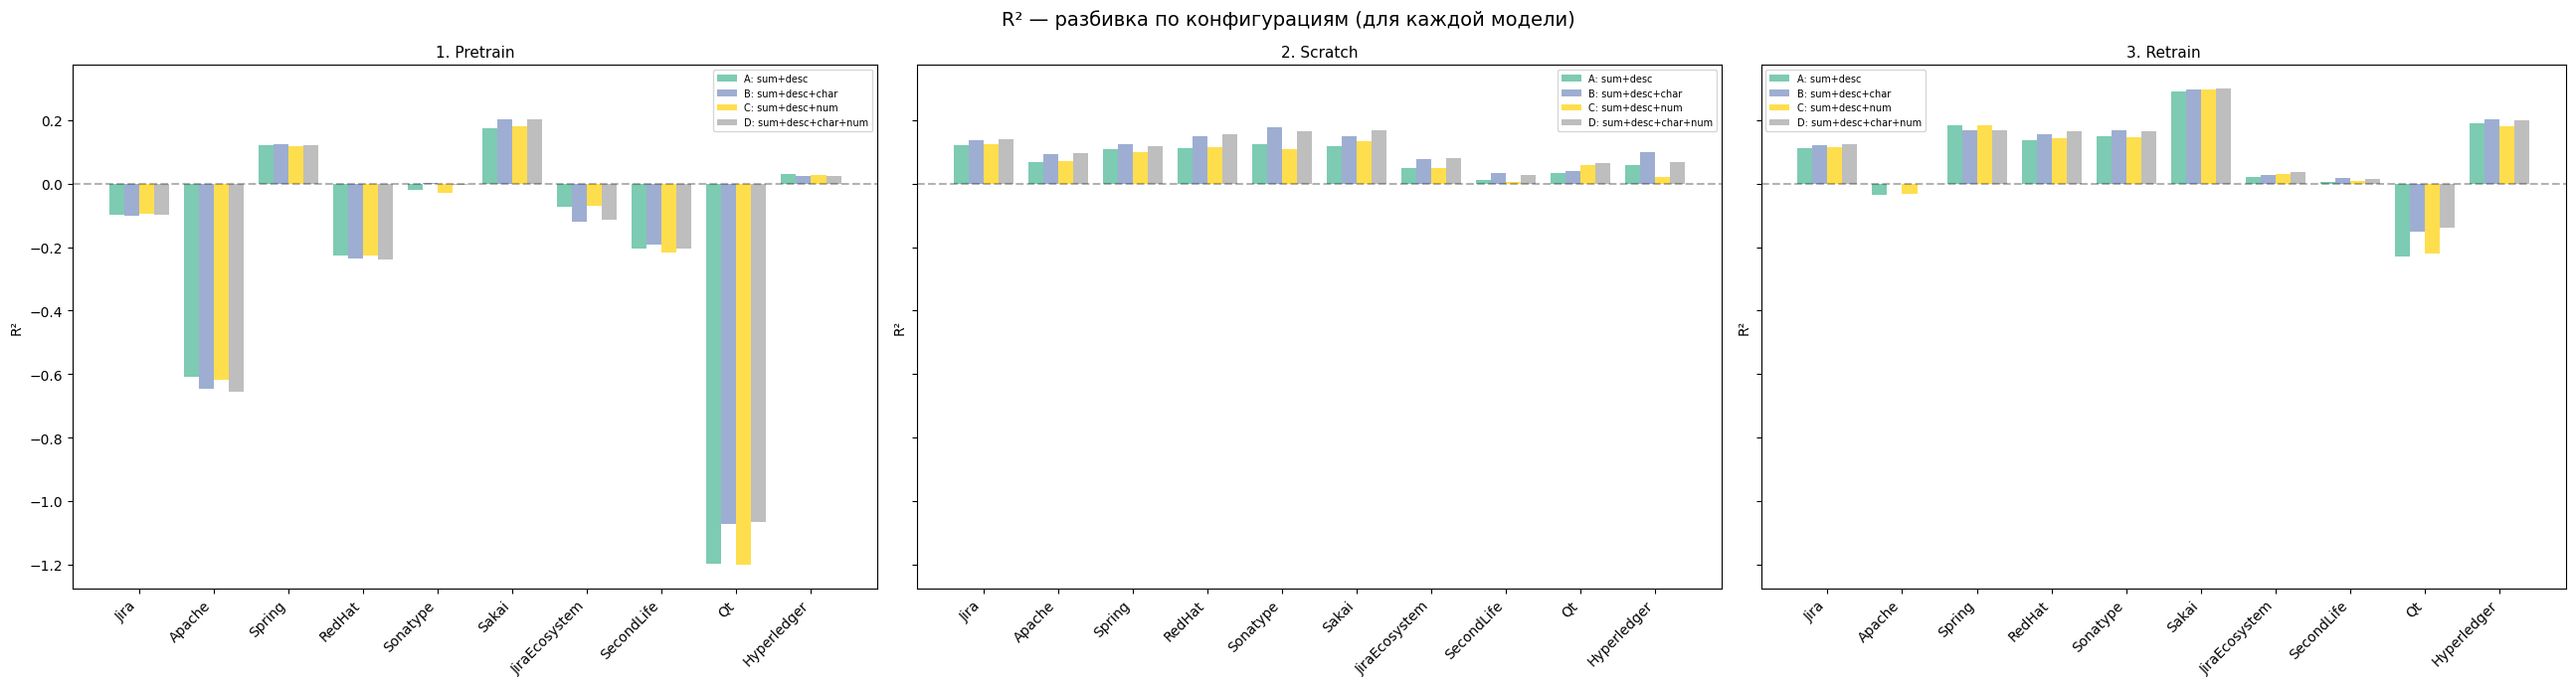

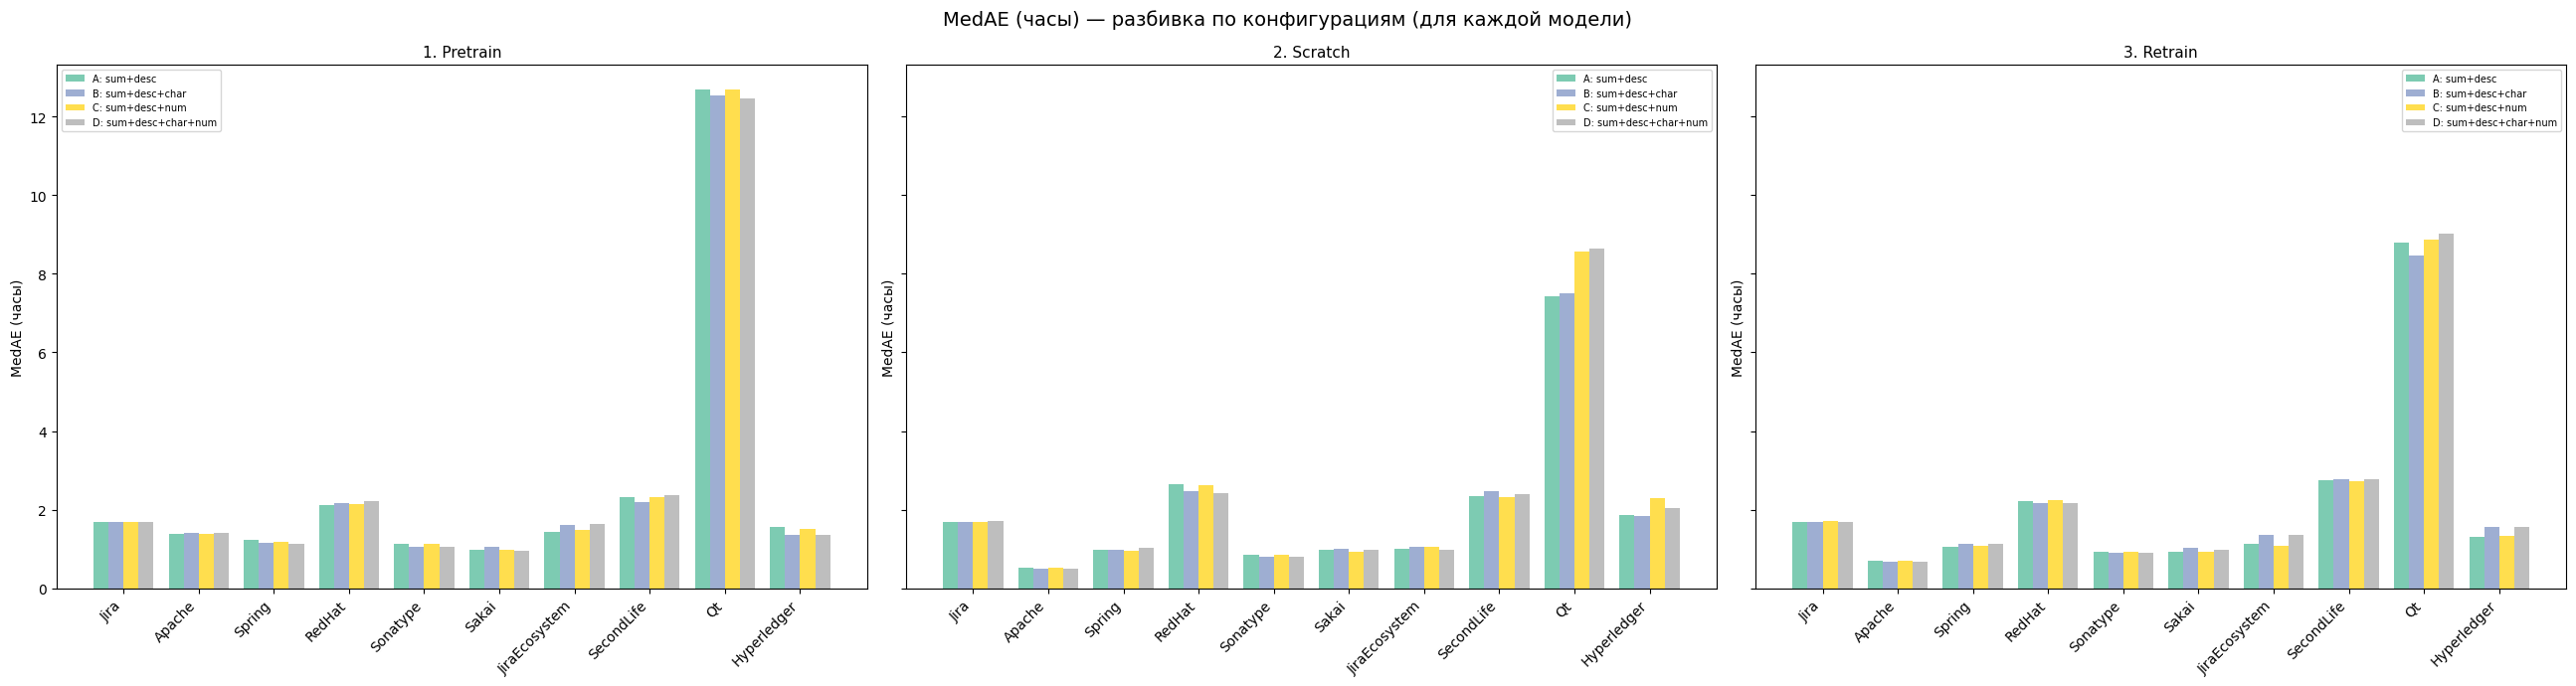

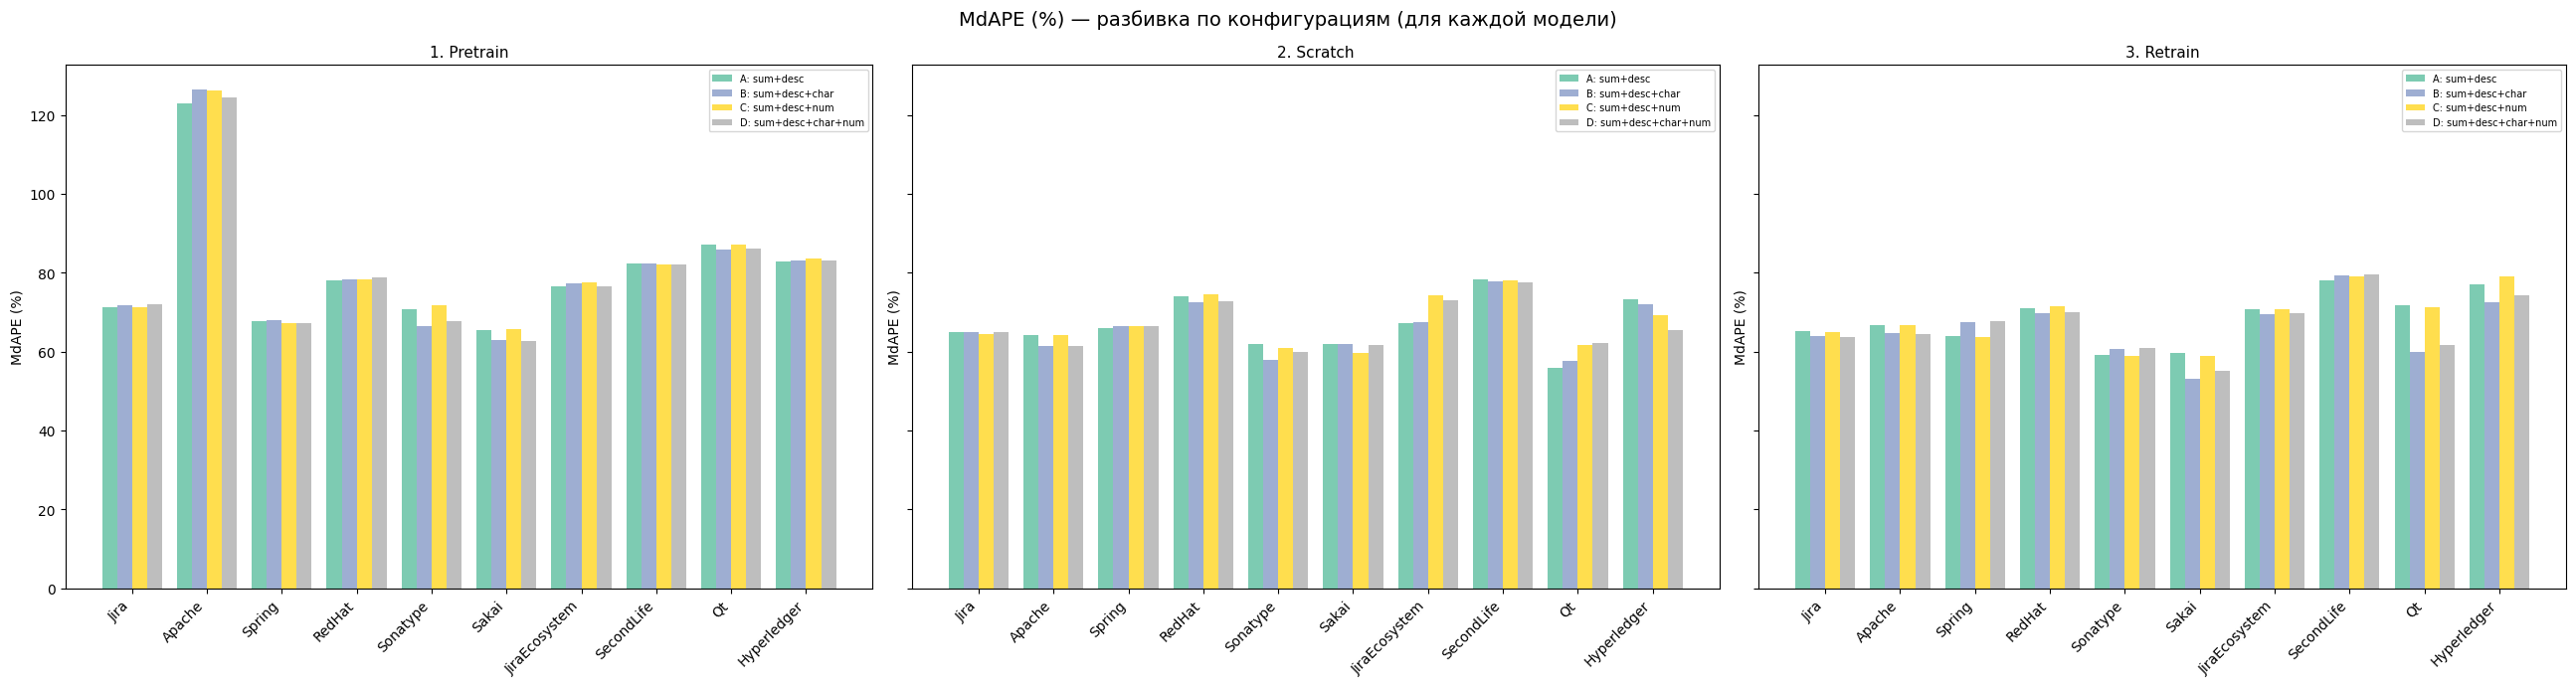

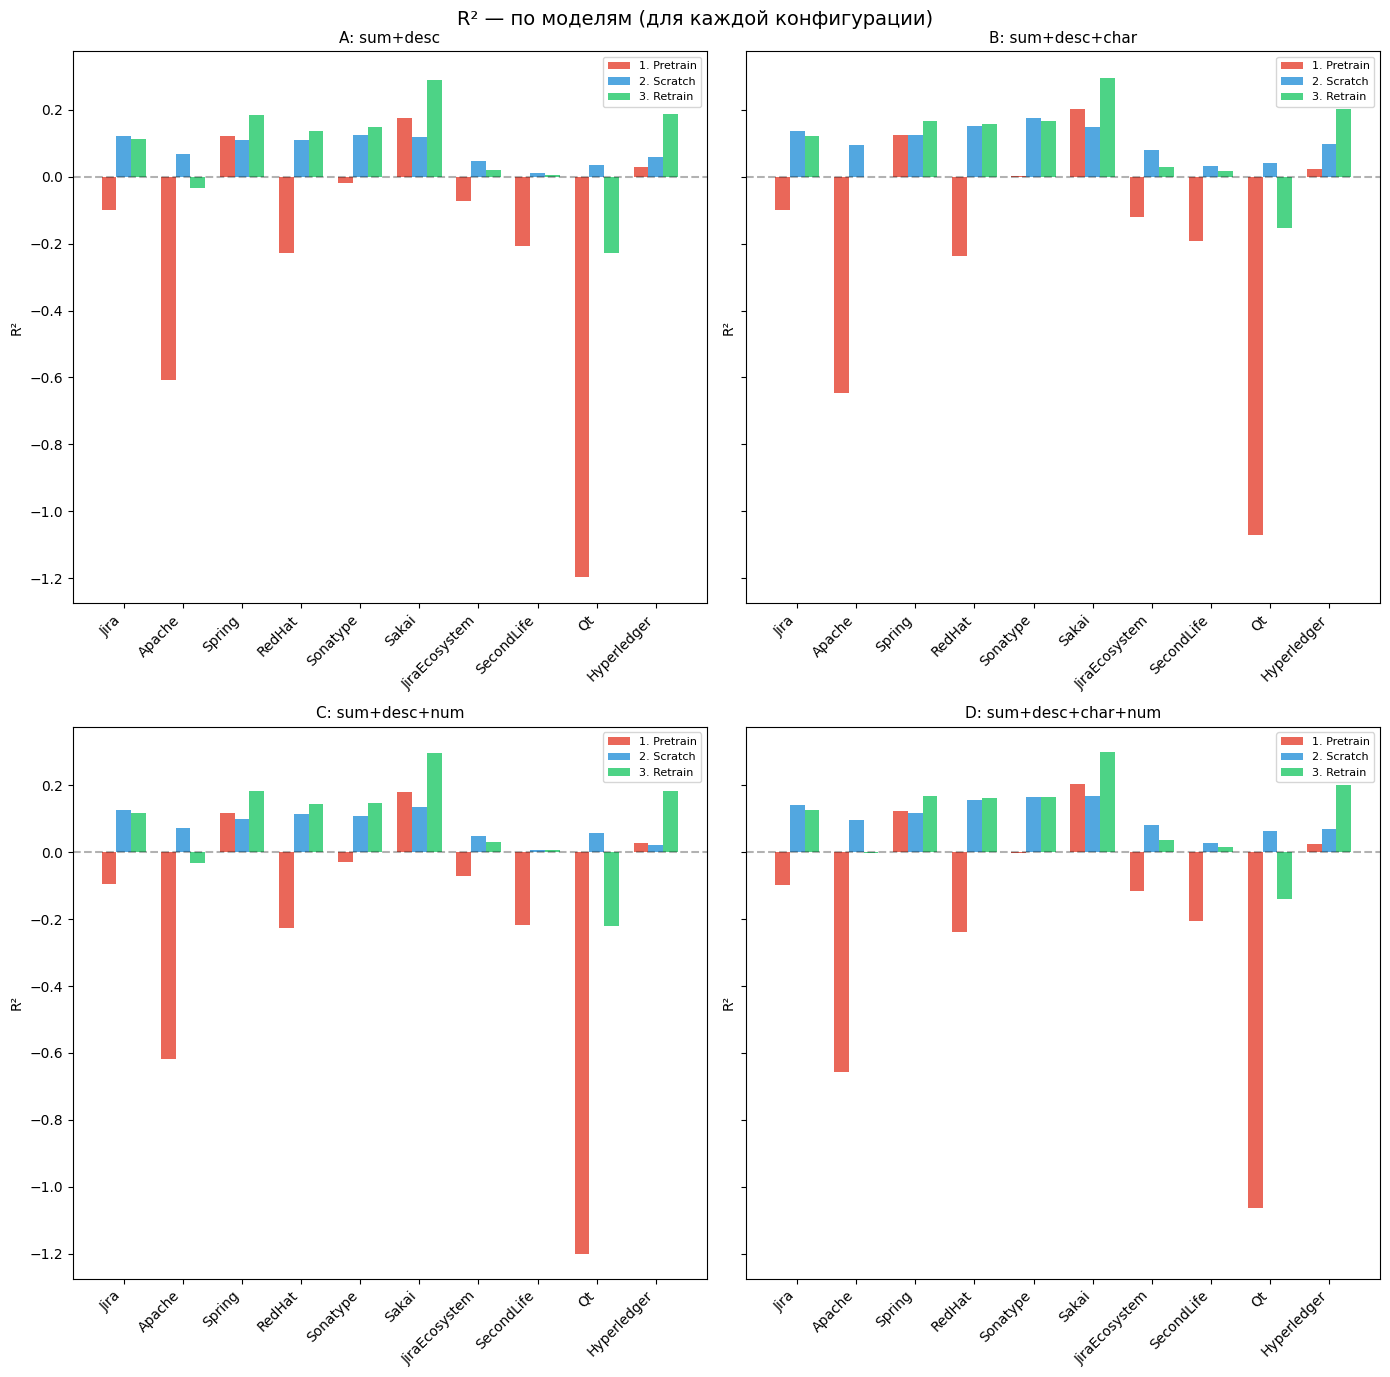

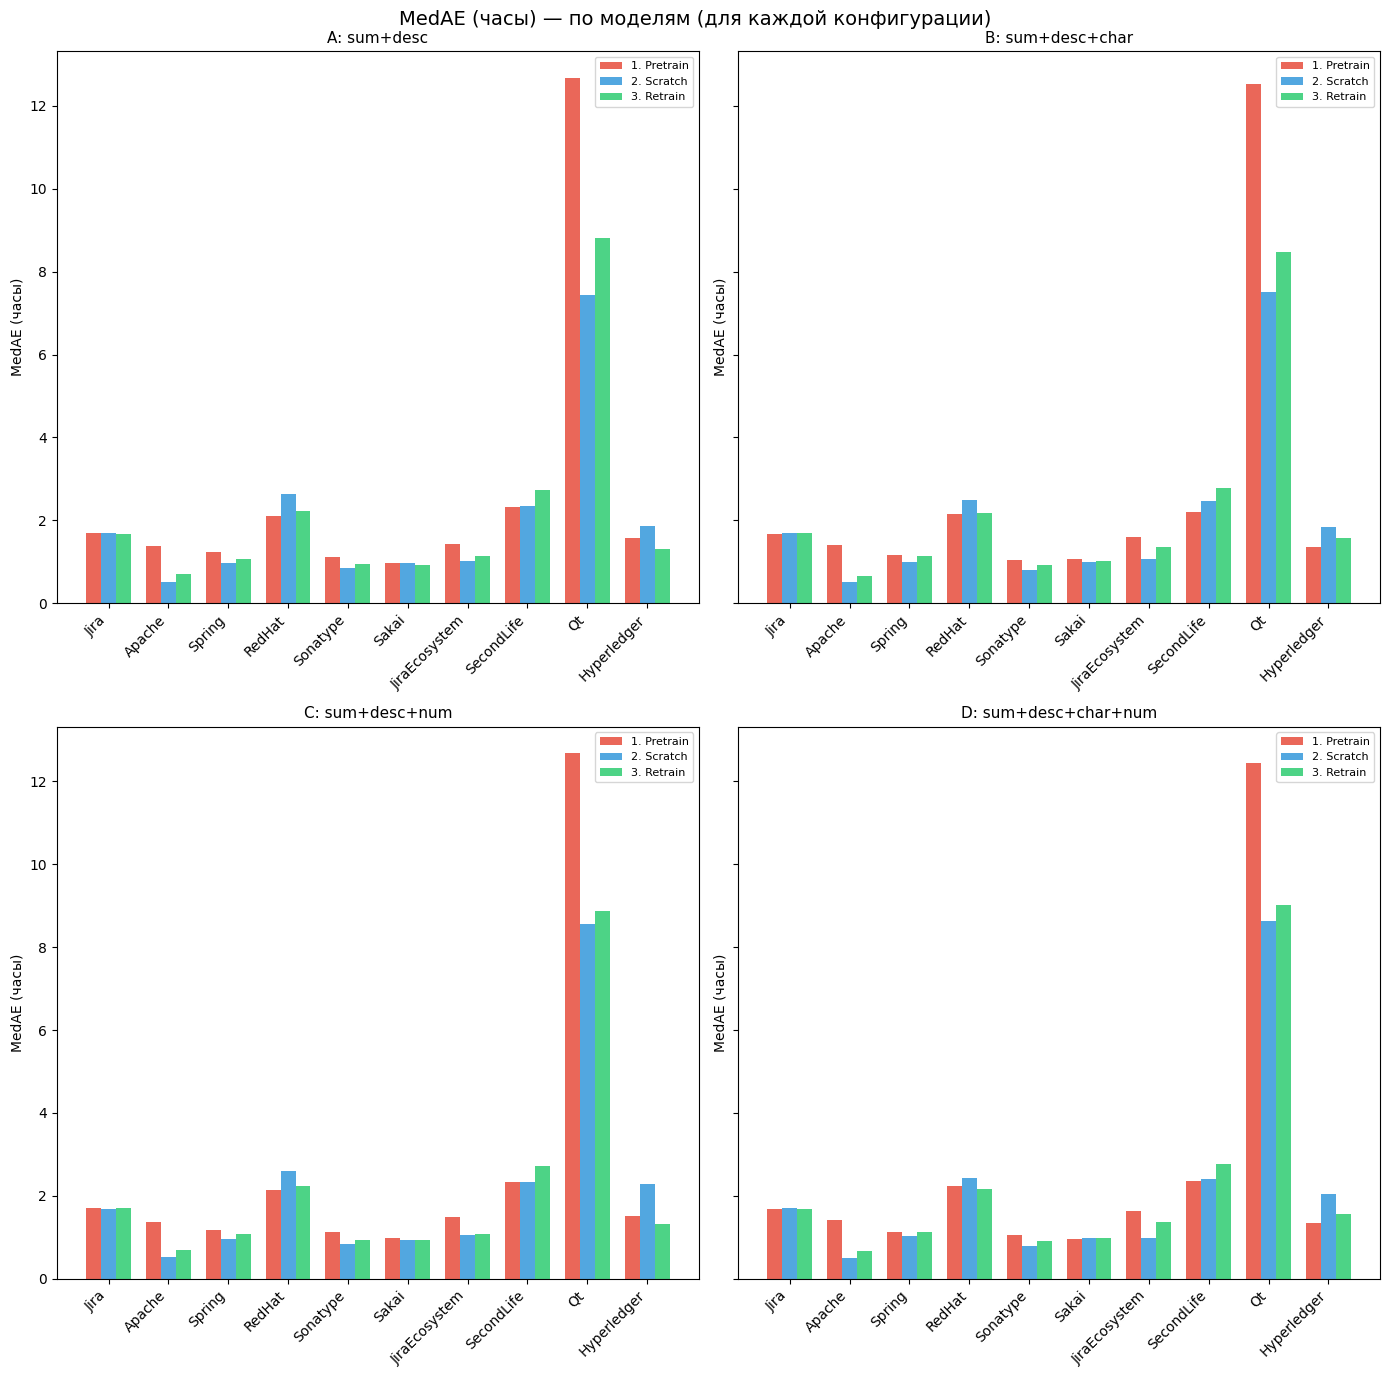

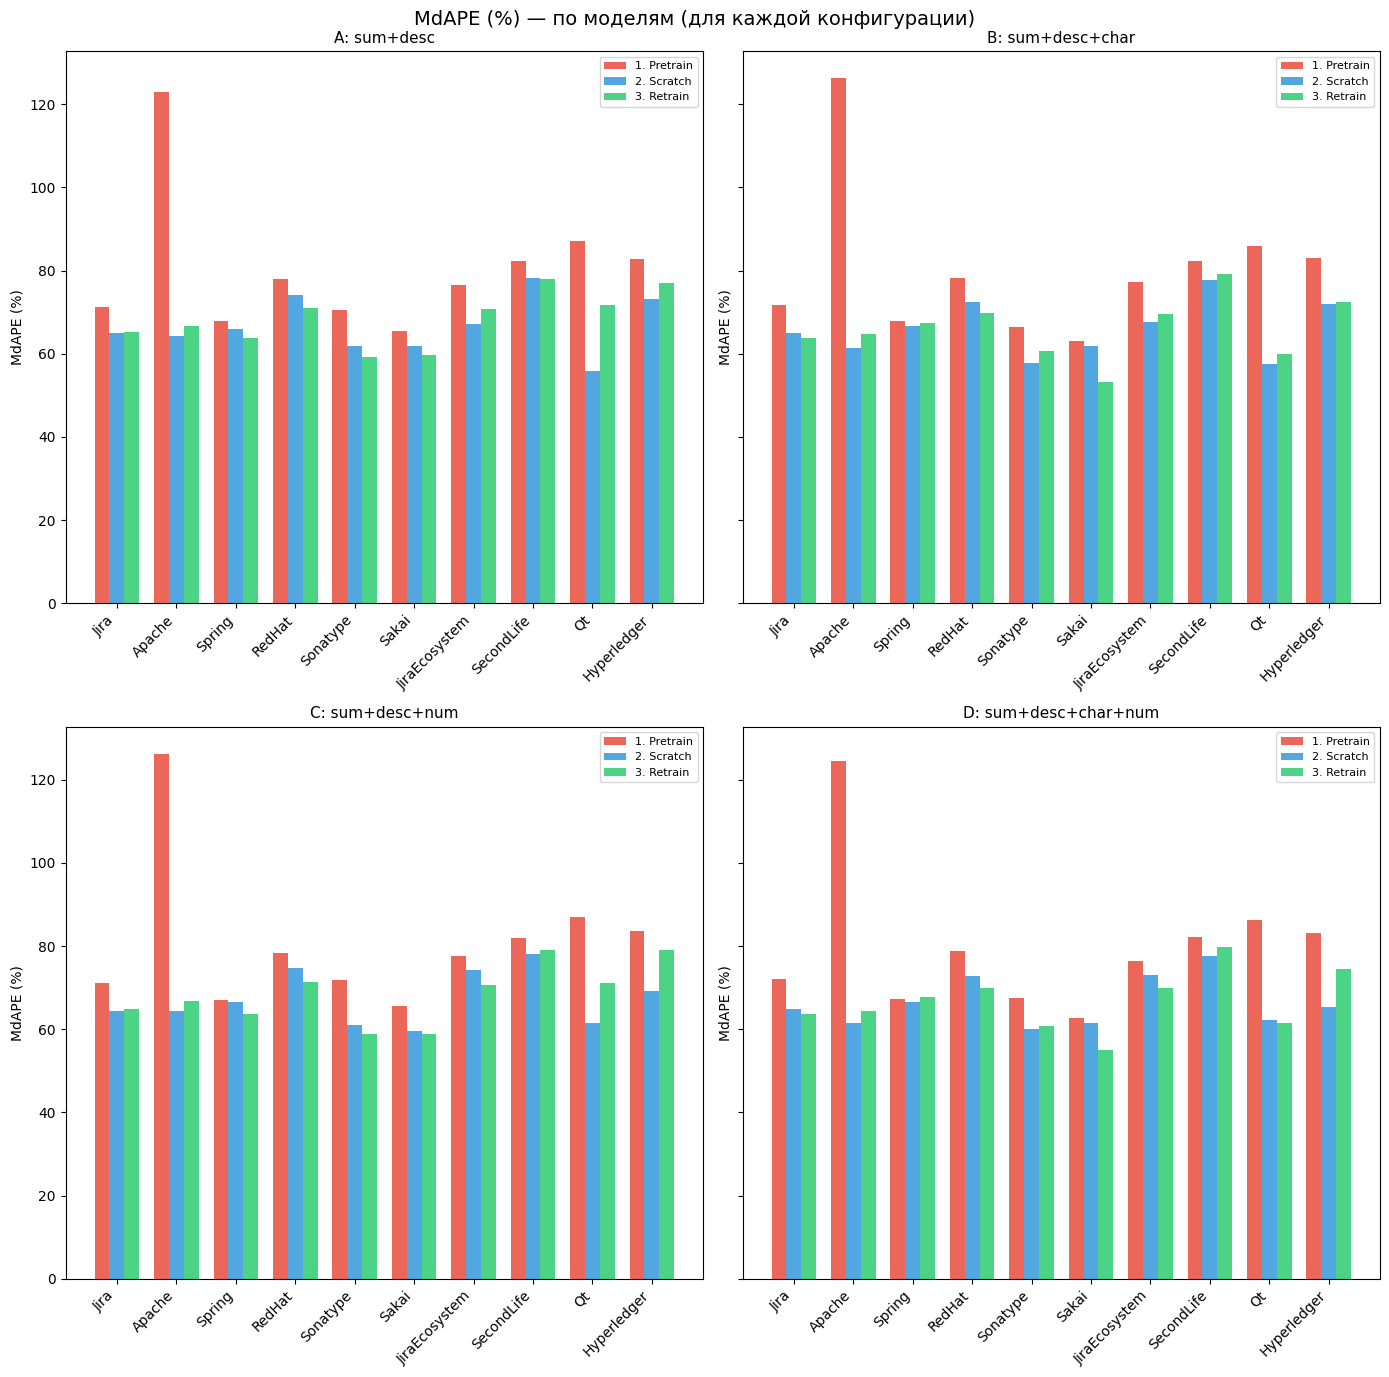

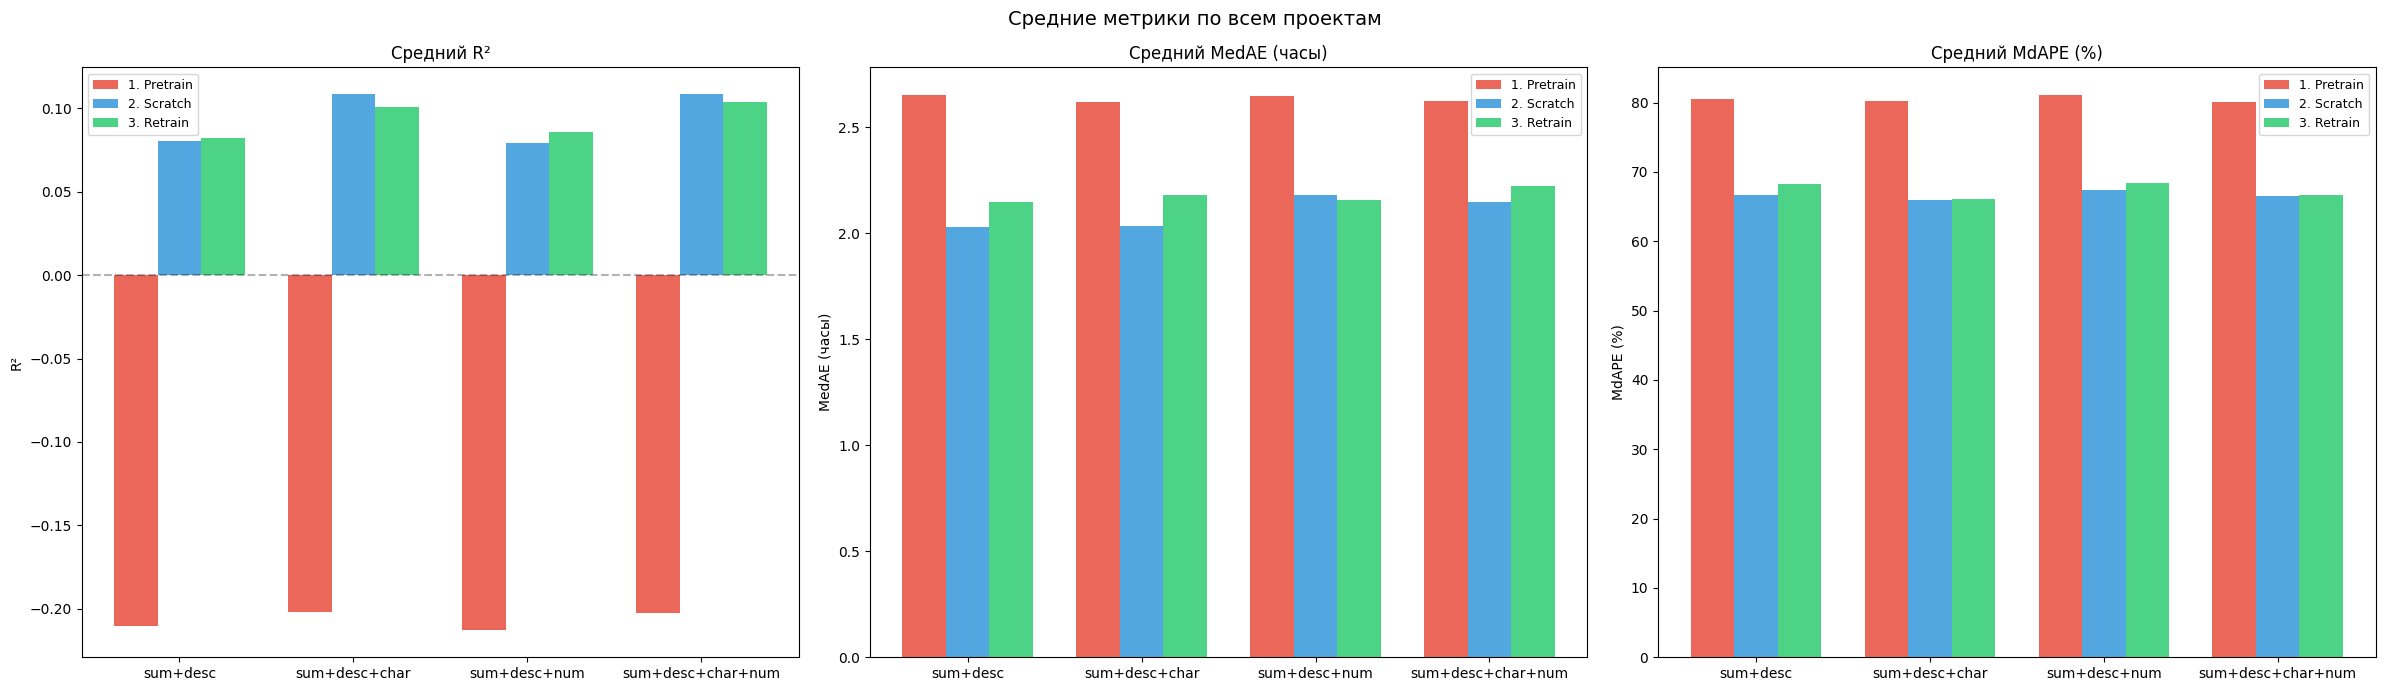

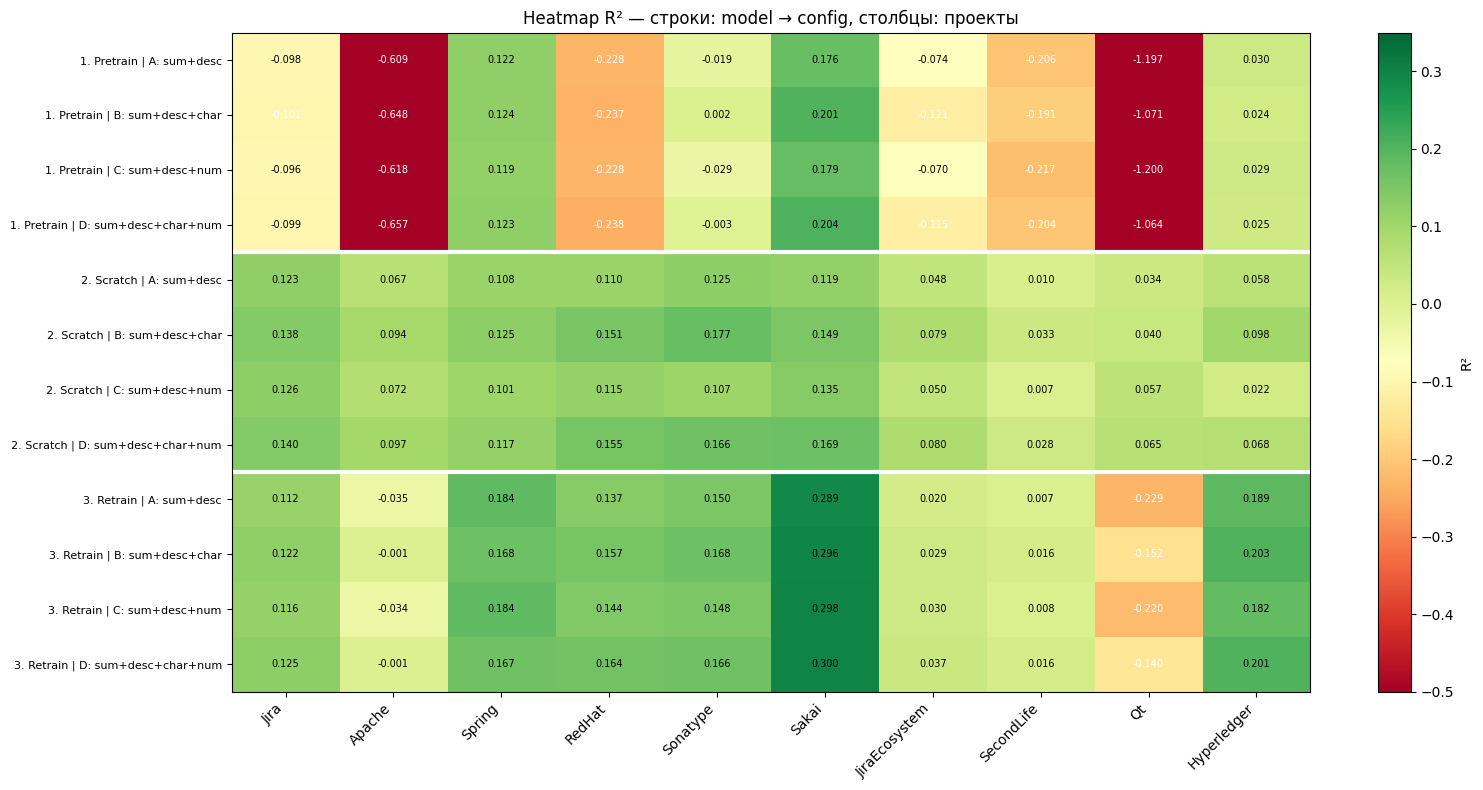

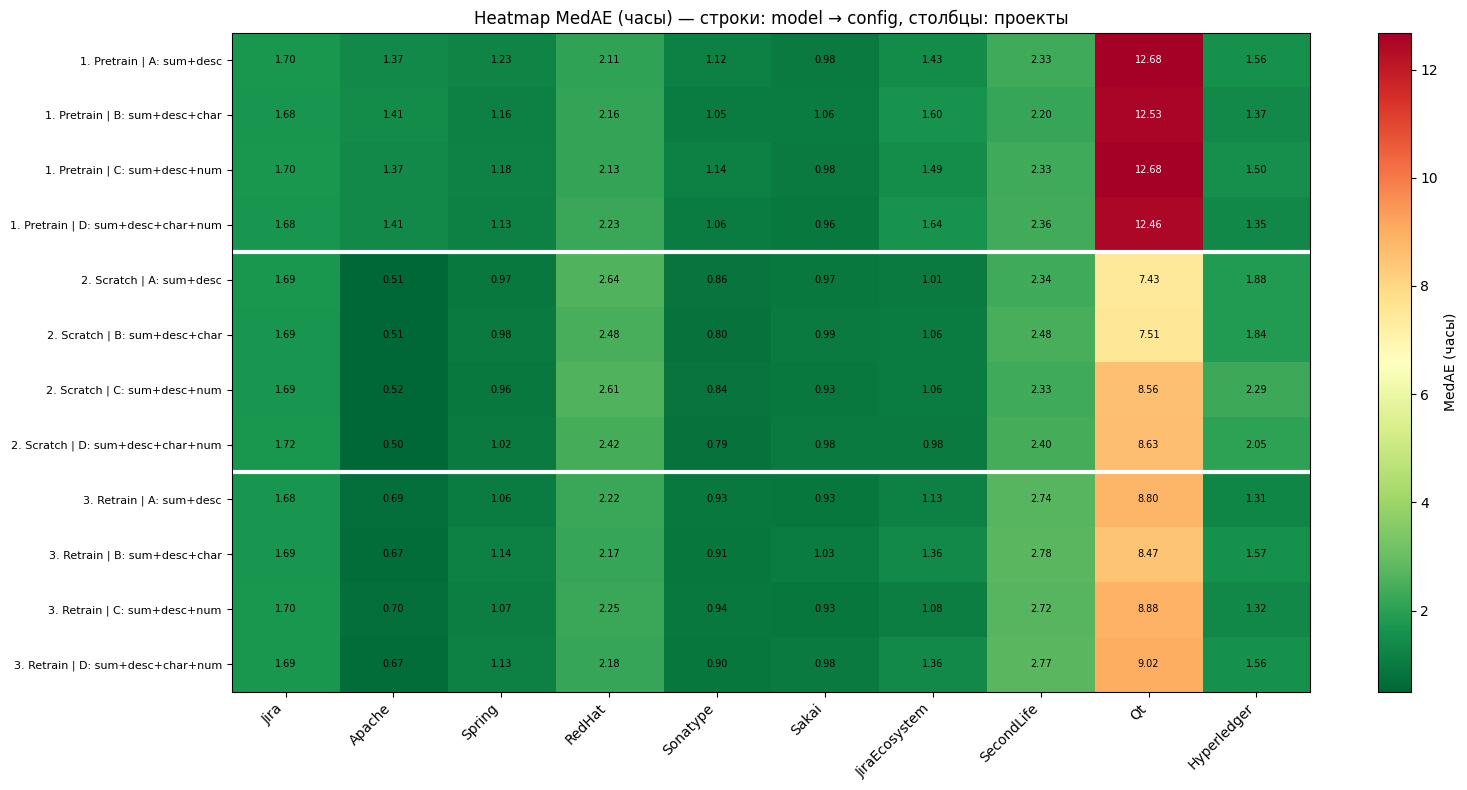

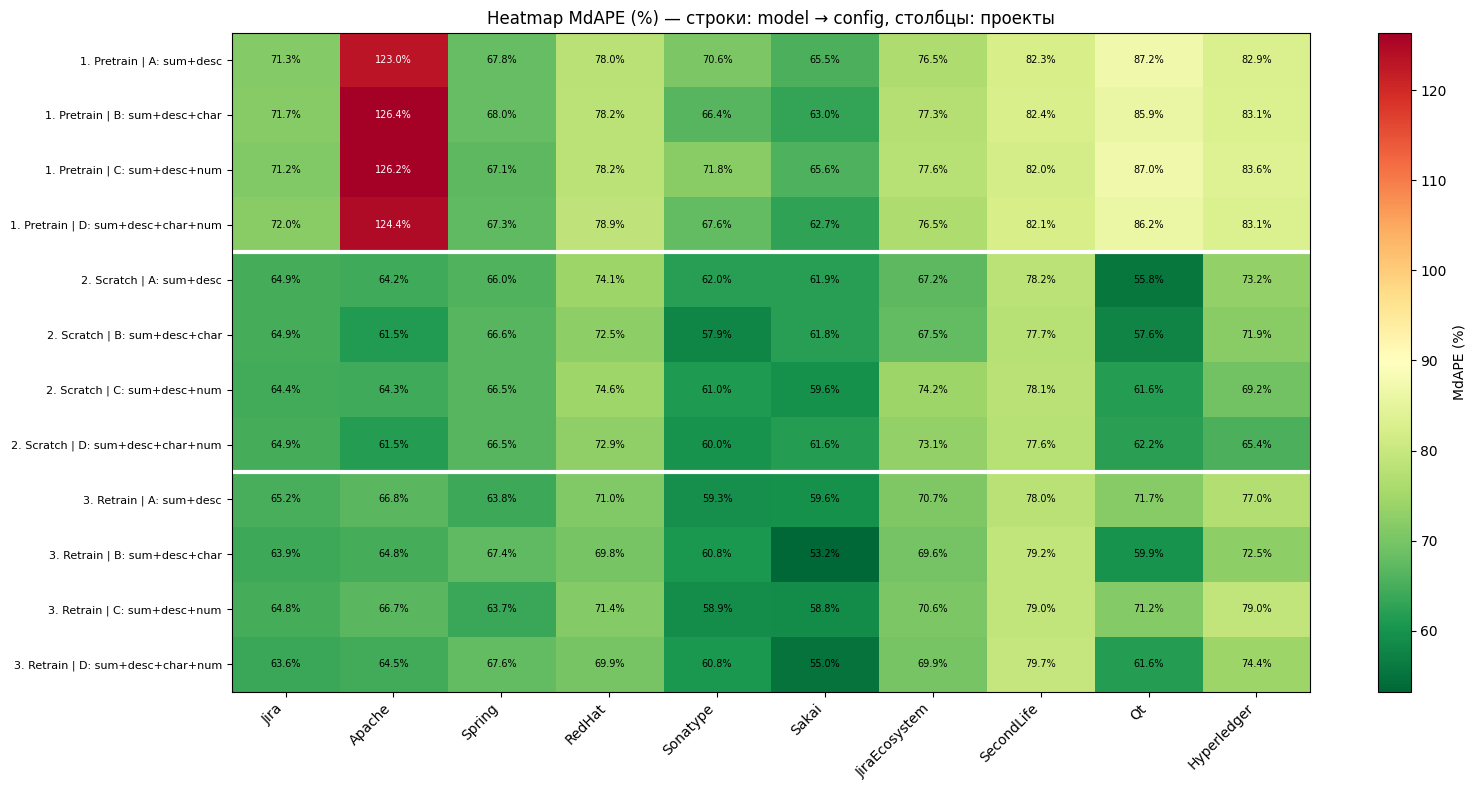

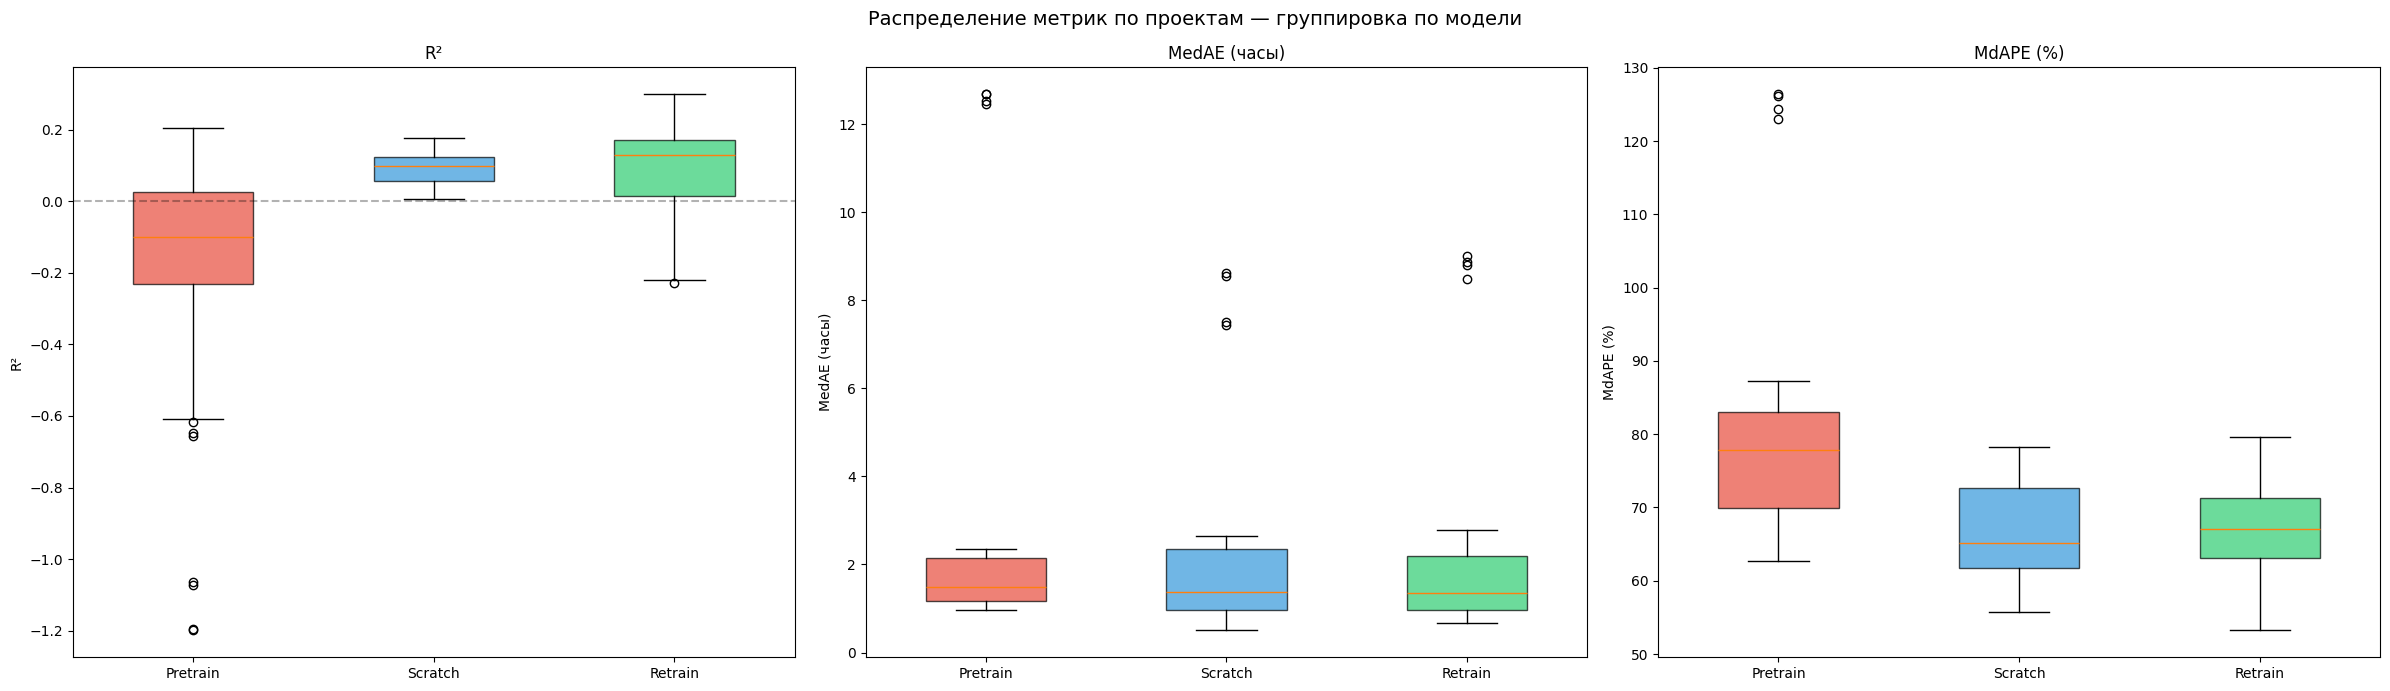

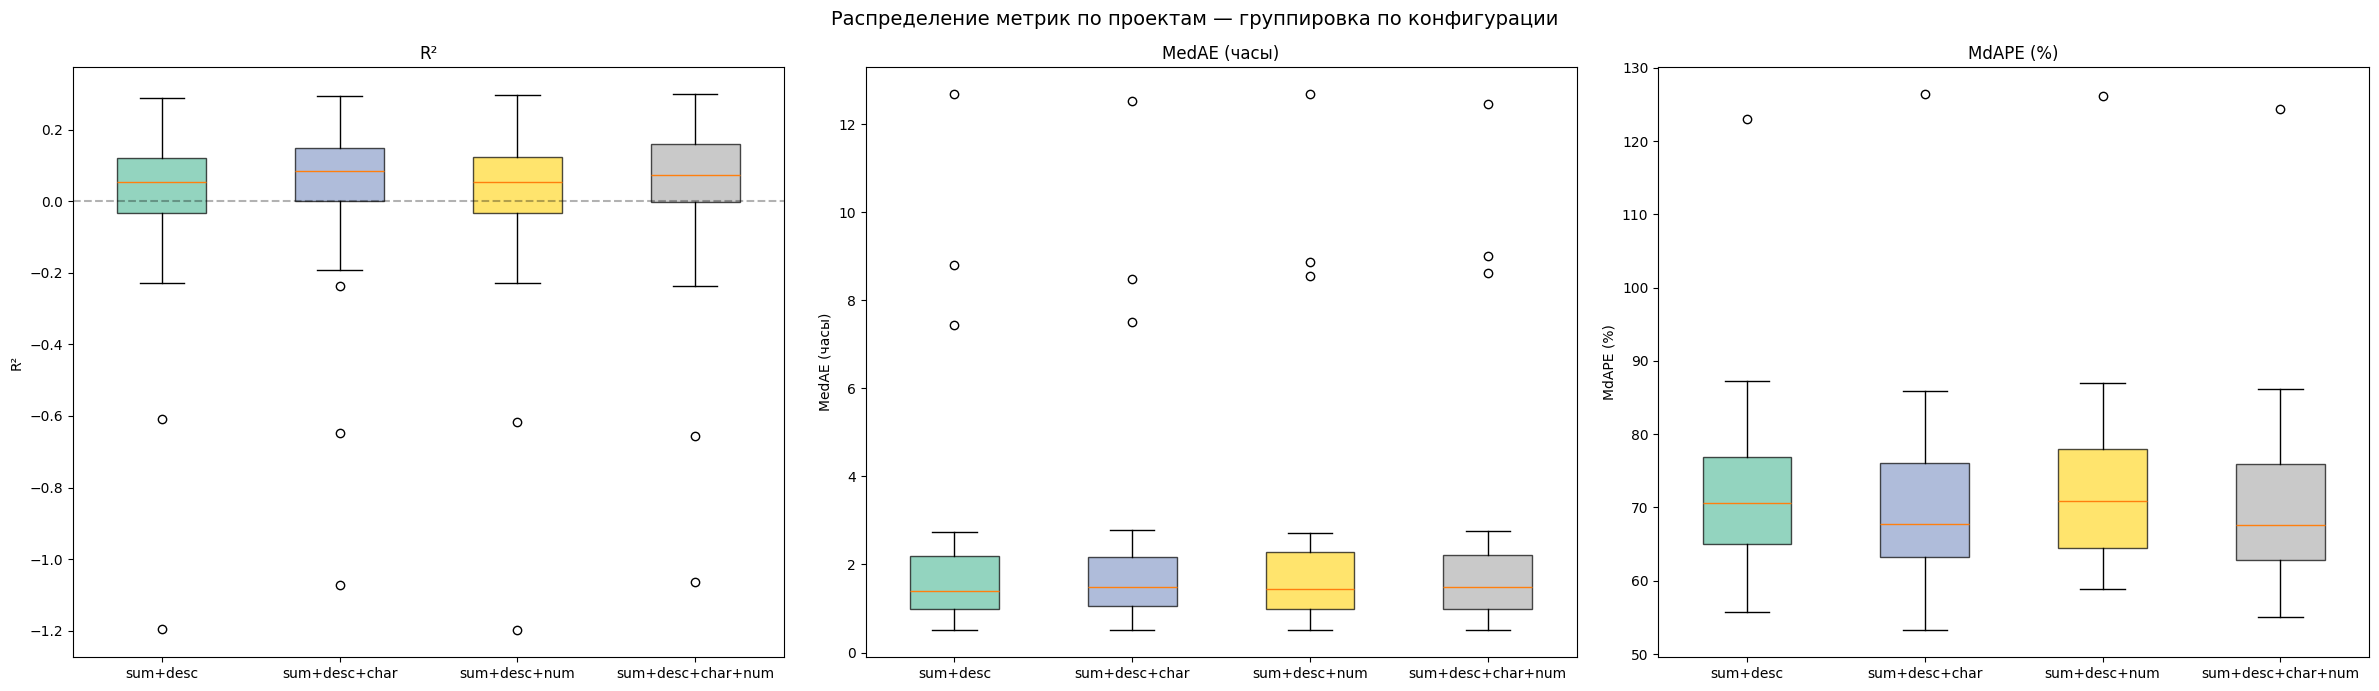

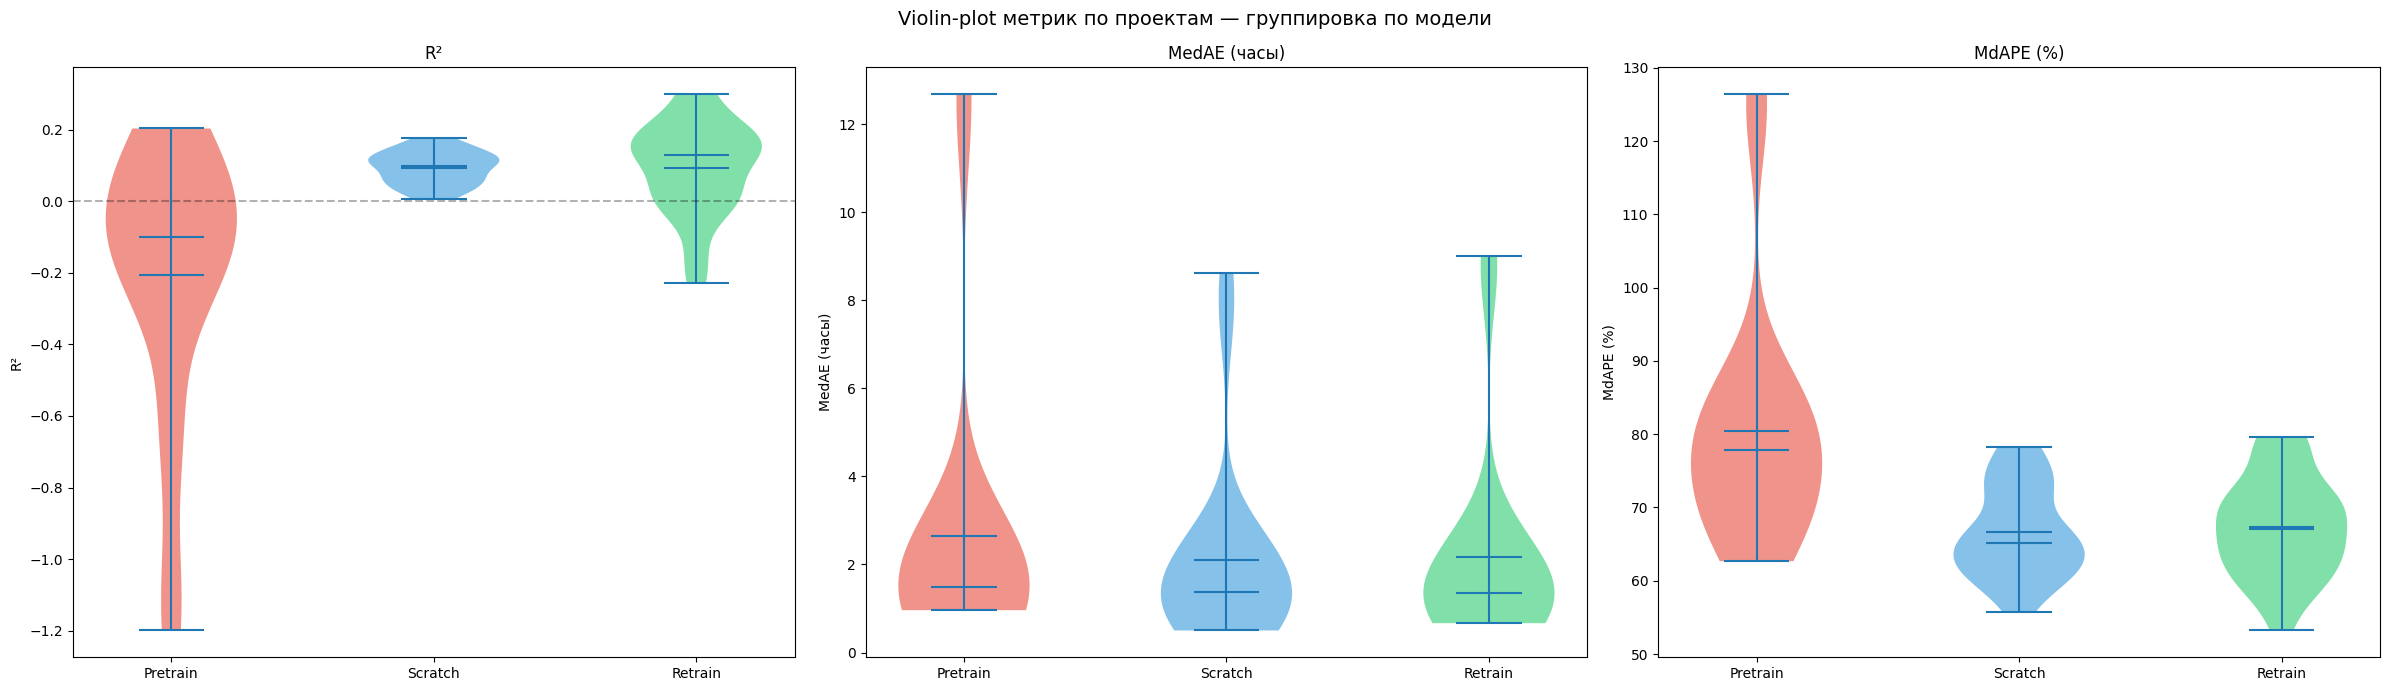

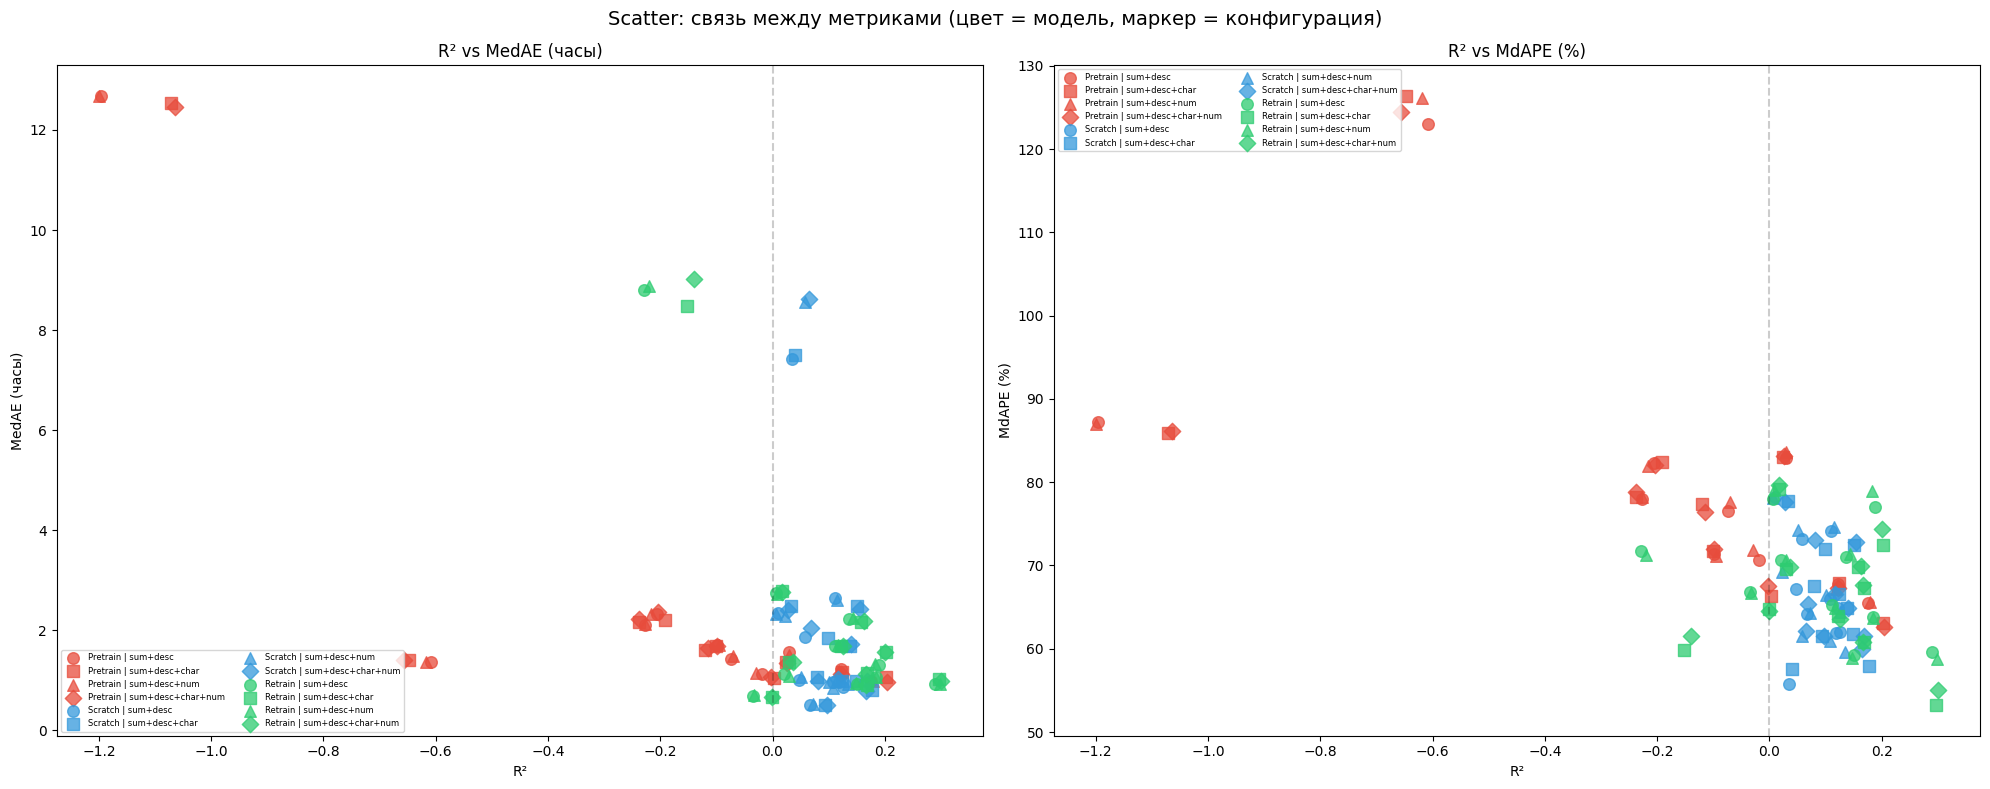

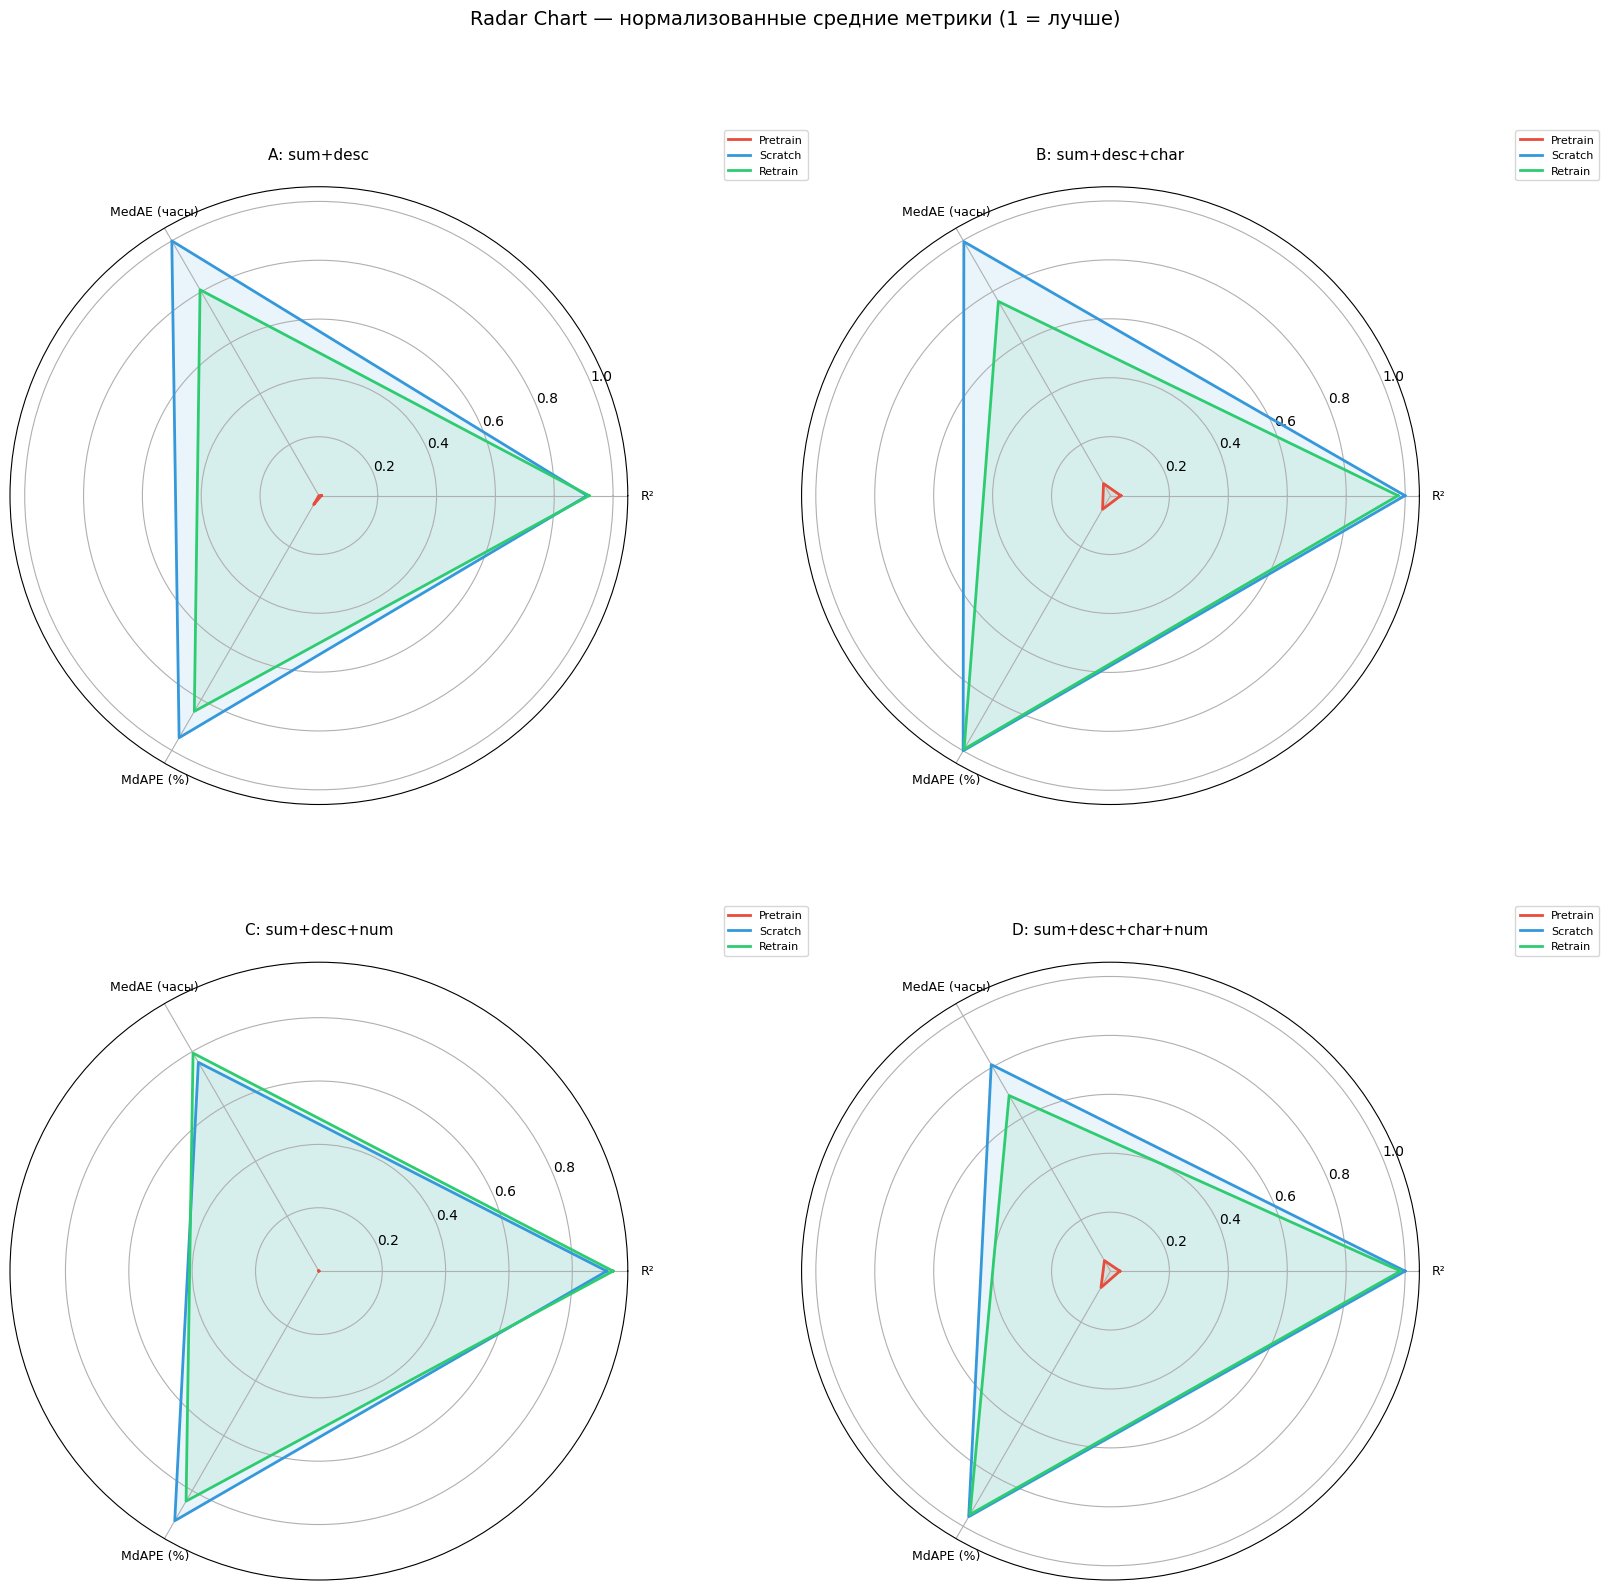

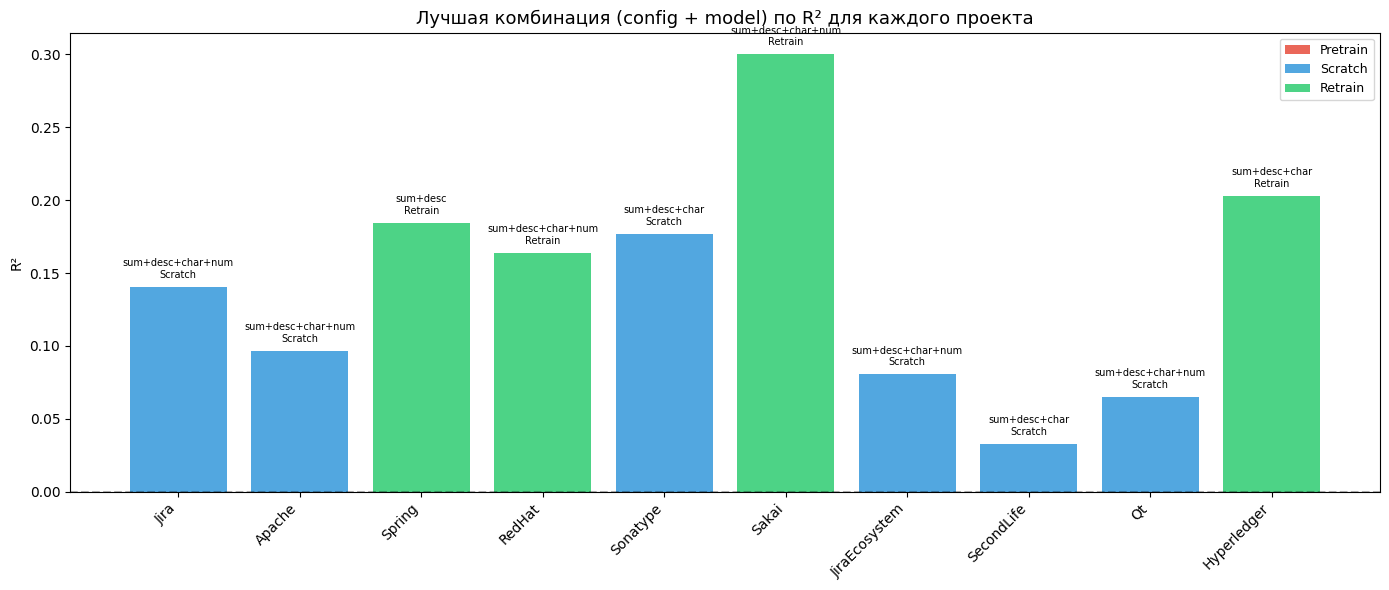

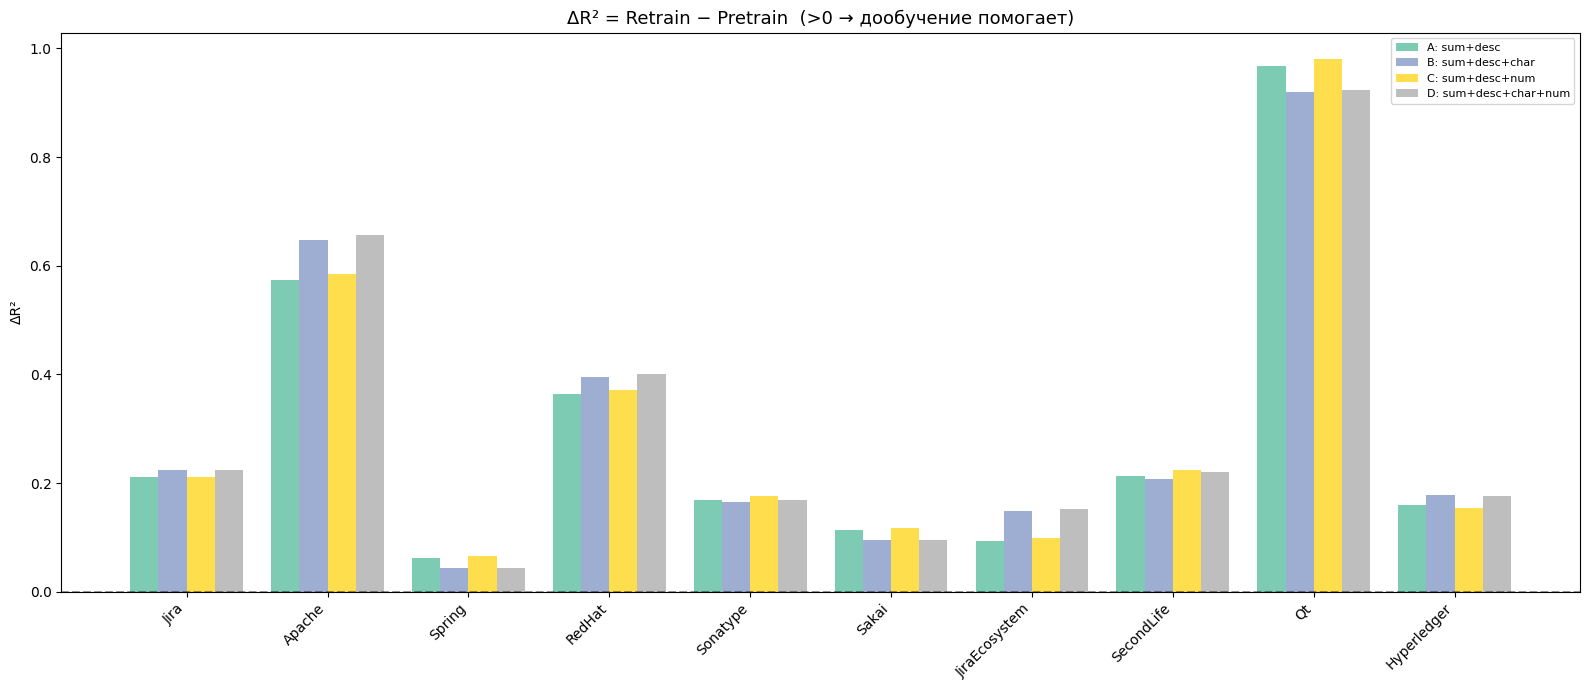

C:\Users\maxgo\AppData\Local\Temp\ipykernel_22160\824593267.py:577: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


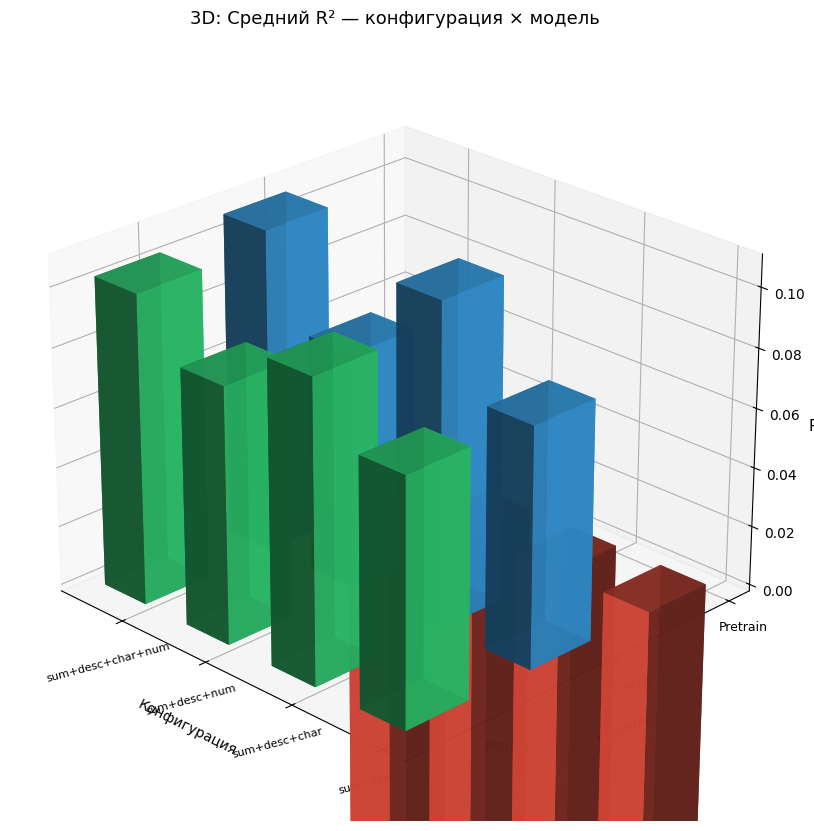

C:\Users\maxgo\AppData\Local\Temp\ipykernel_22160\824593267.py:623: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


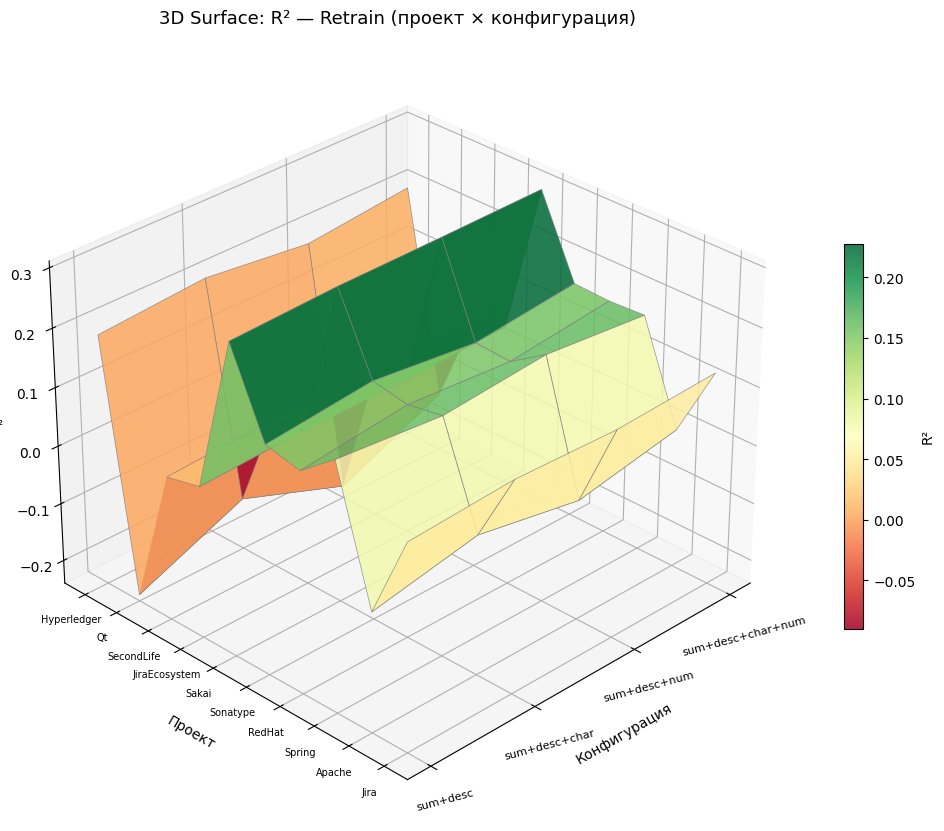

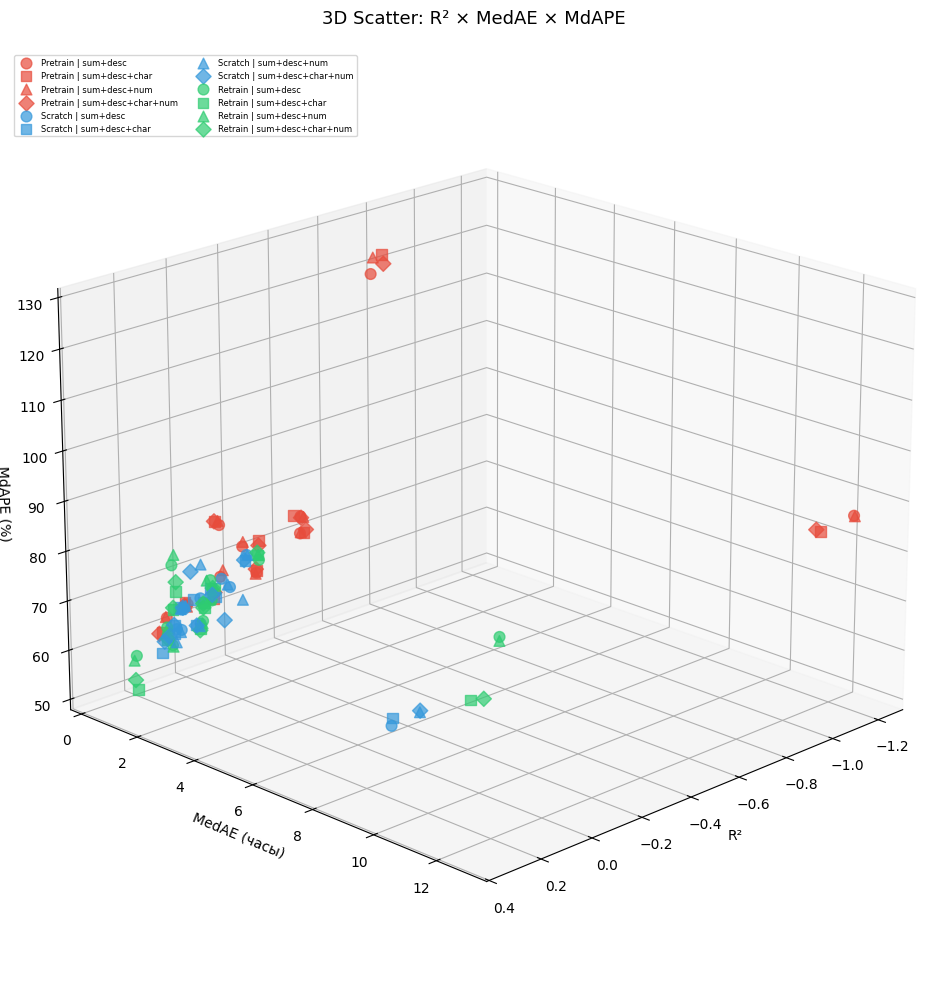


✅ Построено 14 типов диаграмм по всем метрикам и конфигурациям.


In [23]:
# ============================================================
# 1. ПОДРОБНЫЕ ТАБЛИЦЫ ПО КАЖДОМУ ПРОЕКТУ
# ============================================================

for proj in projects:
    proj_data = full_df[full_df["project"] == proj].copy()
    
    print(f"\n{'='*85}")
    n_tasks = len(df_balanced[df_balanced["source_collection"] == proj])
    print(f"  {proj} ({n_tasks} задач)")
    print(f"{'='*85}")
    
    print(f"{'Конфигурация':<25}", end="")
    for model in ["1. Pretrain", "2. Scratch", "3. Retrain"]:
        print(f"|{model:^25}", end="")
    print()
    
    print(f"{'':25}", end="")
    for _ in range(3):
        print(f"|  {'R²':>6}  {'MedAE':>6}  {'MdAPE':>6} ", end="")
    print()
    print("-" * 120)
    
    for config_name in configs.keys():
        print(f"{config_name:<25}", end="")
        for model in ["1. Pretrain", "2. Scratch", "3. Retrain"]:
            row = proj_data[(proj_data["config"] == config_name) & (proj_data["model"] == model)]
            if len(row) > 0:
                r2 = row["R2"].values[0]
                med = row["MedAE"].values[0]
                mape = row["MdAPE"].values[0]
                mape_str = f"{mape:>5.1f}%" if not np.isnan(mape) else "   N/A"
                print(f"| {r2:>7.4f}  {med:>5.2f}ч  {mape_str} ", end="")
        print()

# ============================================================
# 2. СРЕДНИЕ ПО ВСЕМ ПРОЕКТАМ
# ============================================================

print(f"\n\n{'='*85}")
print("  СРЕДНИЕ МЕТРИКИ ПО ВСЕМ ПРОЕКТАМ")
print(f"{'='*85}")

print(f"\n{'--- R² ---':^85}")
pivot_r2 = full_df.groupby(["config", "model"])["R2"].mean().unstack("model").round(4)
print(pivot_r2.to_string())

print(f"\n{'--- MedAE (часы) ---':^85}")
pivot_med = full_df.groupby(["config", "model"])["MedAE"].mean().unstack("model").round(2)
print(pivot_med.to_string())

print(f"\n{'--- MdAPE % ---':^85}")
pivot_mape = full_df.groupby(["config", "model"])["MdAPE"].mean().unstack("model").round(1)
print(pivot_mape.to_string())

# ============================================================
# 3. ЛУЧШАЯ КОМБИНАЦИЯ ПО КАЖДОМУ ПРОЕКТУ
# ============================================================

print(f"\n\n{'='*85}")
print("  ЛУЧШАЯ КОМБИНАЦИЯ (config + model) ПО R² ДЛЯ КАЖДОГО ПРОЕКТА")
print(f"{'='*85}")

for proj in projects:
    proj_data = full_df[full_df["project"] == proj]
    best_idx = proj_data["R2"].idxmax()
    best = proj_data.loc[best_idx]
    print(f"  {proj:<15} → {best['config']:<25} {best['model']:<15} "
          f"R²={best['R2']:.4f}  MedAE={best['MedAE']:.2f}ч  MdAPE={best['MdAPE']:.1f}%")


# ============================================================
# 4. ВИЗУАЛИЗАЦИЯ — МАКСИМАЛЬНОЕ ЧИСЛО ДИАГРАММ
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.mplot3d import Axes3D

# ---------- общие настройки ----------
metrics      = ["R2", "MedAE", "MdAPE"]
metric_label = {"R2": "R²", "MedAE": "MedAE (часы)", "MdAPE": "MdAPE (%)"}
metric_better = {"R2": "higher", "MedAE": "lower", "MdAPE": "lower"}

models_list  = ["1. Pretrain", "2. Scratch", "3. Retrain"]
config_names = list(configs.keys())

projects_order = sorted(
    projects,
    key=lambda p: df_balanced[df_balanced["source_collection"] == p].shape[0],
    reverse=True,
)

colors_model = {
    "1. Pretrain": "#e74c3c",
    "2. Scratch":  "#3498db",
    "3. Retrain":  "#2ecc71",
}
_cmap_cfg = plt.cm.Set2(np.linspace(0, 1, max(len(config_names), 3)))
colors_config = {c: _cmap_cfg[i] for i, c in enumerate(config_names)}

# вспомогательная функция — безопасное извлечение значения
def _val(df, proj, cfg, model, metric):
    row = df[(df["project"] == proj) &
             (df["config"] == cfg) &
             (df["model"] == model)]
    if len(row) == 0:
        return 0.0
    v = row[metric].values[0]
    return v if not np.isnan(v) else 0.0


# ============================================================
# 4.1  ДЛЯ КАЖДОЙ МЕТРИКИ × КАЖДОЙ МОДЕЛИ
#      столбцы = конфигурации, ось X = проекты
#      → 3 фигуры (по метрике), в каждой 3 subplot (по модели)
# ============================================================
for metric in metrics:
    fig, axes = plt.subplots(1, 3, figsize=(26, 7), sharey=True)
    fig.suptitle(
        f"{metric_label[metric]} — разбивка по конфигурациям (для каждой модели)",
        fontsize=14,
    )
    for ax_i, model in enumerate(models_list):
        ax = axes[ax_i]
        x = np.arange(len(projects_order))
        n = len(config_names)
        w = 0.8 / n
        for ci, cfg in enumerate(config_names):
            vals = [_val(full_df, p, cfg, model, metric) for p in projects_order]
            ax.bar(x + ci * w, vals, w,
                   label=cfg, color=colors_config[cfg], alpha=0.85)
        ax.set_title(model, fontsize=11)
        ax.set_ylabel(metric_label[metric])
        ax.set_xticks(x + w * (n - 1) / 2)
        ax.set_xticklabels(projects_order, rotation=45, ha="right")
        if metric == "R2":
            ax.axhline(0, color="k", ls="--", alpha=0.3)
        ax.legend(fontsize=7, loc="best")
    plt.tight_layout()
    plt.show()


# ============================================================
# 4.2  ДЛЯ КАЖДОЙ МЕТРИКИ × КАЖДОЙ КОНФИГУРАЦИИ
#      столбцы = модели, ось X = проекты
#      → 3 фигуры (по метрике), в каждой N subplot (по конфиг.)
# ============================================================
for metric in metrics:
    ncols = min(len(config_names), 2)
    nrows = (len(config_names) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7 * nrows), sharey=True)
    axes = np.atleast_2d(axes).reshape(nrows, ncols)
    fig.suptitle(
        f"{metric_label[metric]} — по моделям (для каждой конфигурации)",
        fontsize=14,
    )
    for ci, cfg in enumerate(config_names):
        r, c = divmod(ci, ncols)
        ax = axes[r, c]
        x = np.arange(len(projects_order))
        w = 0.25
        for mi, model in enumerate(models_list):
            vals = [_val(full_df, p, cfg, model, metric) for p in projects_order]
            ax.bar(x + mi * w, vals, w,
                   label=model, color=colors_model[model], alpha=0.85)
        ax.set_title(cfg, fontsize=11)
        ax.set_ylabel(metric_label[metric])
        ax.set_xticks(x + w)
        ax.set_xticklabels(projects_order, rotation=45, ha="right")
        if metric == "R2":
            ax.axhline(0, color="k", ls="--", alpha=0.3)
        ax.legend(fontsize=8)
    for ci in range(len(config_names), nrows * ncols):
        r, c = divmod(ci, ncols)
        axes[r, c].set_visible(False)
    plt.tight_layout()
    plt.show()


# ============================================================
# 4.3  СРЕДНИЕ МЕТРИКИ по конфигурациям (все проекты)
#      → 1 фигура, 3 subplot (по метрике)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle("Средние метрики по всем проектам", fontsize=14)
for ax_i, metric in enumerate(metrics):
    ax = axes[ax_i]
    summary = full_df.groupby(["config", "model"])[metric].mean().unstack("model")
    x = np.arange(len(summary))
    w = 0.25
    for mi, model in enumerate(models_list):
        if model in summary.columns:
            ax.bar(x + mi * w, summary[model].values, w,
                   label=model, color=colors_model[model], alpha=0.85)
    ax.set_title(f"Средний {metric_label[metric]}", fontsize=12)
    ax.set_ylabel(metric_label[metric])
    ax.set_xticks(x + w)
    ax.set_xticklabels([c.split(":")[1].strip() for c in summary.index])
    if metric == "R2":
        ax.axhline(0, color="k", ls="--", alpha=0.3)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


# ============================================================
# 4.4  HEATMAP — для КАЖДОЙ метрики
#      строки сгруппированы по model, внутри отсортированы по config
# ============================================================
for metric in metrics:
    hm = full_df.copy()
    hm = hm.sort_values(["model", "config"])
    hm["label"] = hm["model"] + " | " + hm["config"]

    # формируем порядок строк: модель → config
    ordered_labels = []
    for model in models_list:
        for cfg in sorted(hm[hm["model"] == model]["config"].unique()):
            lbl = f"{model} | {cfg}"
            ordered_labels.append(lbl)

    pivot = (
        hm.pivot_table(index="label", columns="project", values=metric)
        .round(3)
        .reindex(index=[l for l in ordered_labels if l in
                        hm.pivot_table(index="label", columns="project",
                                       values=metric).index])
    )
    col_order = [p for p in projects_order if p in pivot.columns]
    pivot = pivot[col_order]

    cmap = "RdYlGn" if metric_better[metric] == "higher" else "RdYlGn_r"
    if metric == "R2":
        vmin, vmax = -0.5, 0.35
    else:
        vmin, vmax = np.nanmin(pivot.values), np.nanmax(pivot.values)

    fig, ax = plt.subplots(
        figsize=(16, max(8, len(pivot) * 0.55))
    )
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto",
                   vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)

    # разделители между группами моделей
    prev_model = None
    for idx, lbl in enumerate(pivot.index):
        cur = lbl.split(" | ")[0]
        if prev_model and cur != prev_model:
            ax.axhline(idx - 0.5, color="white", lw=3)
        prev_model = cur

    # аннотации
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if np.isnan(v):
                continue
            if metric == "R2":
                txt = f"{v:.3f}"
            elif metric == "MedAE":
                txt = f"{v:.2f}"
            else:
                txt = f"{v:.1f}%"
            tc = ("white" if (metric == "R2" and v < -0.1)
                  else ("white" if (metric != "R2" and
                        v > vmin + 0.75 * (vmax - vmin)) else "black"))
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=7, color=tc)

    ax.set_title(
        f"Heatmap {metric_label[metric]} — "
        f"строки: model → config, столбцы: проекты",
        fontsize=12,
    )
    plt.colorbar(im, ax=ax, label=metric_label[metric])
    plt.tight_layout()
    plt.show()


# ============================================================
# 4.5  BOX-PLOTS: распределение по проектам, группировка по МОДЕЛИ
#      → 1 фигура, 3 subplot (по метрике)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle(
    "Распределение метрик по проектам — группировка по модели", fontsize=14
)
for ax_i, metric in enumerate(metrics):
    ax = axes[ax_i]
    data_bp, labels_bp, clrs = [], [], []
    for model in models_list:
        vals = full_df[full_df["model"] == model][metric].dropna().values
        data_bp.append(vals)
        labels_bp.append(model.split(". ")[1])
        clrs.append(colors_model[model])
    bp = ax.boxplot(data_bp, tick_labels=labels_bp, patch_artist=True,
                    widths=0.5)
    for patch, color in zip(bp["boxes"], clrs):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(metric_label[metric], fontsize=12)
    ax.set_ylabel(metric_label[metric])
    if metric == "R2":
        ax.axhline(0, color="k", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 4.6  BOX-PLOTS: распределение по проектам, группировка по КОНФИГУРАЦИИ
#      → 1 фигура, 3 subplot (по метрике)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle(
    "Распределение метрик по проектам — группировка по конфигурации",
    fontsize=14,
)
for ax_i, metric in enumerate(metrics):
    ax = axes[ax_i]
    data_bp, labels_bp, clrs = [], [], []
    for cfg in config_names:
        vals = full_df[full_df["config"] == cfg][metric].dropna().values
        data_bp.append(vals)
        labels_bp.append(cfg.split(":")[1].strip())
        clrs.append(colors_config[cfg])
    bp = ax.boxplot(data_bp, tick_labels=labels_bp, patch_artist=True,
                    widths=0.5)
    for patch, color in zip(bp["boxes"], clrs):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(metric_label[metric], fontsize=12)
    ax.set_ylabel(metric_label[metric])
    if metric == "R2":
        ax.axhline(0, color="k", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 4.7  VIOLIN-PLOTS: та же идея, но violin
#      → 1 фигура, 3 subplot (по метрике), группировка по модели
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle(
    "Violin-plot метрик по проектам — группировка по модели", fontsize=14
)
for ax_i, metric in enumerate(metrics):
    ax = axes[ax_i]
    data_vp = []
    for model in models_list:
        vals = full_df[full_df["model"] == model][metric].dropna().values
        data_vp.append(vals)
    parts = ax.violinplot(data_vp, showmeans=True, showmedians=True)
    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(list(colors_model.values())[i])
        pc.set_alpha(0.6)
    ax.set_xticks(range(1, len(models_list) + 1))
    ax.set_xticklabels([m.split(". ")[1] for m in models_list])
    ax.set_title(metric_label[metric], fontsize=12)
    ax.set_ylabel(metric_label[metric])
    if metric == "R2":
        ax.axhline(0, color="k", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 4.8  SCATTER: R² vs MedAE и R² vs MdAPE
#      цвет = модель, маркер = конфигурация
# ============================================================
_markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h']
markers_cfg = {c: _markers[i % len(_markers)]
               for i, c in enumerate(config_names)}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    "Scatter: связь между метриками "
    "(цвет = модель, маркер = конфигурация)",
    fontsize=14,
)

for mi, (y_metric, y_lab) in enumerate(
    [("MedAE", "MedAE (часы)"), ("MdAPE", "MdAPE (%)")]
):
    ax = axes[mi]
    for model in models_list:
        for cfg in config_names:
            sub = full_df[
                (full_df["model"] == model) & (full_df["config"] == cfg)
            ]
            ax.scatter(
                sub["R2"], sub[y_metric],
                color=colors_model[model],
                marker=markers_cfg[cfg],
                s=70, alpha=0.75,
                label=f"{model.split('. ')[1]} | {cfg.split(':')[1].strip()}",
            )
    ax.set_xlabel("R²")
    ax.set_ylabel(y_lab)
    ax.set_title(f"R² vs {y_lab}")
    ax.axvline(0, color="k", ls="--", alpha=0.2)
    # уникальная легенда
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(),
              fontsize=6, ncol=2, loc="best")

plt.tight_layout()
plt.show()


# ============================================================
# 4.9  RADAR / Spider Chart — средние метрики по моделям
#      (одна диаграмма на конфигурацию)
# ============================================================
from math import pi

# нормируем метрики в [0, 1] для radar (1 = лучше)
avg_all = full_df.groupby(["config", "model"])[metrics].mean()

norm_vals = {}
for metric in metrics:
    col = avg_all[metric]
    mn, mx = col.min(), col.max()
    if metric_better[metric] == "higher":
        norm_vals[metric] = (col - mn) / (mx - mn + 1e-9)
    else:
        norm_vals[metric] = 1 - (col - mn) / (mx - mn + 1e-9)

import pandas as pd
norm_df = pd.DataFrame(norm_vals)

ncols_r = min(len(config_names), 2)
nrows_r = (len(config_names) + ncols_r - 1) // ncols_r
fig, axes = plt.subplots(
    nrows_r, ncols_r, figsize=(8 * ncols_r, 8 * nrows_r),
    subplot_kw=dict(polar=True),
)
axes = np.atleast_2d(axes).reshape(nrows_r, ncols_r)
fig.suptitle(
    "Radar Chart — нормализованные средние метрики (1 = лучше)",
    fontsize=14, y=1.02,
)

angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

for ci, cfg in enumerate(config_names):
    r, c = divmod(ci, ncols_r)
    ax = axes[r, c]
    for model in models_list:
        if (cfg, model) in norm_df.index:
            values = norm_df.loc[(cfg, model)].tolist()
            values += values[:1]
            ax.plot(angles, values, label=model.split(". ")[1],
                    color=colors_model[model], linewidth=2)
            ax.fill(angles, values, color=colors_model[model], alpha=0.1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([metric_label[m] for m in metrics], fontsize=9)
    ax.set_title(cfg, fontsize=11, pad=20)
    ax.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.3, 1.1))

for ci in range(len(config_names), nrows_r * ncols_r):
    r, c = divmod(ci, ncols_r)
    axes[r, c].set_visible(False)
plt.tight_layout()
plt.show()


# ============================================================
# 4.10  GROUPED BAR: лучшая модель для каждого проекта (по R²)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
best_per_proj = (
    full_df.loc[full_df.groupby("project")["R2"].idxmax()]
    .set_index("project")
    .reindex(projects_order)
)
x = np.arange(len(projects_order))
bar_colors = [colors_model[m] for m in best_per_proj["model"]]
bars = ax.bar(x, best_per_proj["R2"].values, color=bar_colors, alpha=0.85)

for i, (proj, row) in enumerate(best_per_proj.iterrows()):
    ax.text(i, row["R2"] + 0.005,
            f"{row['config'].split(':')[1].strip()}\n{row['model'].split('. ')[1]}",
            ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(projects_order, rotation=45, ha="right")
ax.set_ylabel("R²")
ax.set_title("Лучшая комбинация (config + model) по R² для каждого проекта",
             fontsize=13)
ax.axhline(0, color="k", ls="--", alpha=0.3)
# кастомная легенда
from matplotlib.patches import Patch
ax.legend(
    [Patch(facecolor=colors_model[m], alpha=0.85) for m in models_list],
    [m.split(". ")[1] for m in models_list],
    fontsize=9,
)
plt.tight_layout()
plt.show()


# ============================================================
# 4.11  STACKED / GROUPED BAR: Δ R² (Retrain − Pretrain)
#       показывает выигрыш дообучения
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(projects_order))
w = 0.8 / len(config_names)
for ci, cfg in enumerate(config_names):
    deltas = []
    for proj in projects_order:
        r2_ret = _val(full_df, proj, cfg, "3. Retrain", "R2")
        r2_pre = _val(full_df, proj, cfg, "1. Pretrain", "R2")
        deltas.append(r2_ret - r2_pre)
    ax.bar(x + ci * w, deltas, w,
           label=cfg, color=colors_config[cfg], alpha=0.85)

ax.set_title("ΔR² = Retrain − Pretrain  (>0 → дообучение помогает)",
             fontsize=13)
ax.set_ylabel("ΔR²")
ax.set_xticks(x + w * (len(config_names) - 1) / 2)
ax.set_xticklabels(projects_order, rotation=45, ha="right")
ax.axhline(0, color="k", ls="--", alpha=0.4)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 4.12  3D СТОЛБЧАТАЯ ДИАГРАММА
#       Средний R² — ось X = конфигурация, Y = модель, Z = R²
# ============================================================
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

avg = full_df.groupby(["config", "model"])["R2"].mean().reset_index()

cfg_labels = sorted(avg["config"].unique())
mdl_labels = sorted(avg["model"].unique())
cfg_idx = {c: i for i, c in enumerate(cfg_labels)}
mdl_idx = {m: i for i, m in enumerate(mdl_labels)}

xpos, ypos, zpos = [], [], []
dx, dy, dz, bar_colors_3d = [], [], [], []

for _, row in avg.iterrows():
    xpos.append(cfg_idx[row["config"]])
    ypos.append(mdl_idx[row["model"]])
    zpos.append(0)
    dx.append(0.5)
    dy.append(0.5)
    dz.append(row["R2"])
    bar_colors_3d.append(colors_model[row["model"]])

ax.bar3d(xpos, ypos, zpos, dx, dy, dz,
         color=bar_colors_3d, alpha=0.85, zsort="average")

ax.set_xticks(range(len(cfg_labels)))
ax.set_xticklabels([c.split(":")[1].strip() for c in cfg_labels],
                   rotation=15, fontsize=8)
ax.set_xlabel("Конфигурация", labelpad=10)
ax.set_yticks(range(len(mdl_labels)))
ax.set_yticklabels([m.split(". ")[1] for m in mdl_labels], fontsize=9)
ax.set_ylabel("Модель", labelpad=10)
ax.set_zlabel("R²", fontsize=11)
ax.set_title("3D: Средний R² — конфигурация × модель",
             fontsize=13, pad=20)
ax.view_init(elev=25, azim=135)
plt.tight_layout()
plt.show()


# ============================================================
# 4.13  3D SURFACE: R² по проектам × конфигурациям (для Retrain)
# ============================================================
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection="3d")

model_3d = "3. Retrain"
sub_3d = full_df[full_df["model"] == model_3d]

cfg_list = sorted(sub_3d["config"].unique())
proj_list = projects_order

Z = np.full((len(proj_list), len(cfg_list)), np.nan)
for pi, proj in enumerate(proj_list):
    for ci, cfg in enumerate(cfg_list):
        row = sub_3d[(sub_3d["project"] == proj) & (sub_3d["config"] == cfg)]
        if len(row):
            Z[pi, ci] = row["R2"].values[0]

X, Y = np.meshgrid(range(len(cfg_list)), range(len(proj_list)))
Z_safe = np.nan_to_num(Z, nan=0.0)

surf = ax.plot_surface(
    X, Y, Z_safe, cmap="RdYlGn",
    alpha=0.85, edgecolor="gray", linewidth=0.5,
)

ax.set_xticks(range(len(cfg_list)))
ax.set_xticklabels([c.split(":")[1].strip() for c in cfg_list],
                   rotation=15, fontsize=8)
ax.set_xlabel("Конфигурация", labelpad=10)
ax.set_yticks(range(len(proj_list)))
ax.set_yticklabels(proj_list, fontsize=7)
ax.set_ylabel("Проект", labelpad=10)
ax.set_zlabel("R²")
ax.set_title(
    f"3D Surface: R² — {model_3d.split('. ')[1]} "
    f"(проект × конфигурация)",
    fontsize=13, pad=20,
)
ax.view_init(elev=30, azim=225)
plt.colorbar(surf, ax=ax, shrink=0.5, label="R²")
plt.tight_layout()
plt.show()


# ============================================================
# 4.14  3D SCATTER: все точки (R², MedAE, MdAPE)
#       цвет = модель, маркер = конфигурация
# ============================================================
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

for model in models_list:
    for cfg in config_names:
        sub = full_df[
            (full_df["model"] == model) & (full_df["config"] == cfg)
        ].dropna(subset=metrics)
        ax.scatter(
            sub["R2"], sub["MedAE"], sub["MdAPE"],
            color=colors_model[model],
            marker=markers_cfg[cfg],
            s=60, alpha=0.7,
            label=f"{model.split('. ')[1]} | {cfg.split(':')[1].strip()}",
        )

ax.set_xlabel("R²")
ax.set_ylabel("MedAE (часы)")
ax.set_zlabel("MdAPE (%)")
ax.set_title("3D Scatter: R² × MedAE × MdAPE", fontsize=13, pad=20)
h, l = ax.get_legend_handles_labels()
ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(),
          fontsize=6, ncol=2, loc="upper left")
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

print("\n✅ Построено 14 типов диаграмм по всем метрикам и конфигурациям.")

### Графики распределения ошибок

Лучшие конфигурации:
  Sonatype        → B: sum+desc+char          2. Scratch      R²=0.1768
  SecondLife      → B: sum+desc+char          2. Scratch      R²=0.0326
  RedHat          → D: sum+desc+char+num      3. Retrain      R²=0.1637
  Spring          → A: sum+desc               3. Retrain      R²=0.1844
  Qt              → D: sum+desc+char+num      2. Scratch      R²=0.0649
  Sakai           → D: sum+desc+char+num      3. Retrain      R²=0.3000
  Jira            → D: sum+desc+char+num      2. Scratch      R²=0.1405
  JiraEcosystem   → D: sum+desc+char+num      2. Scratch      R²=0.0805
  Hyperledger     → B: sum+desc+char          3. Retrain      R²=0.2028
  Apache          → D: sum+desc+char+num      2. Scratch      R²=0.0967


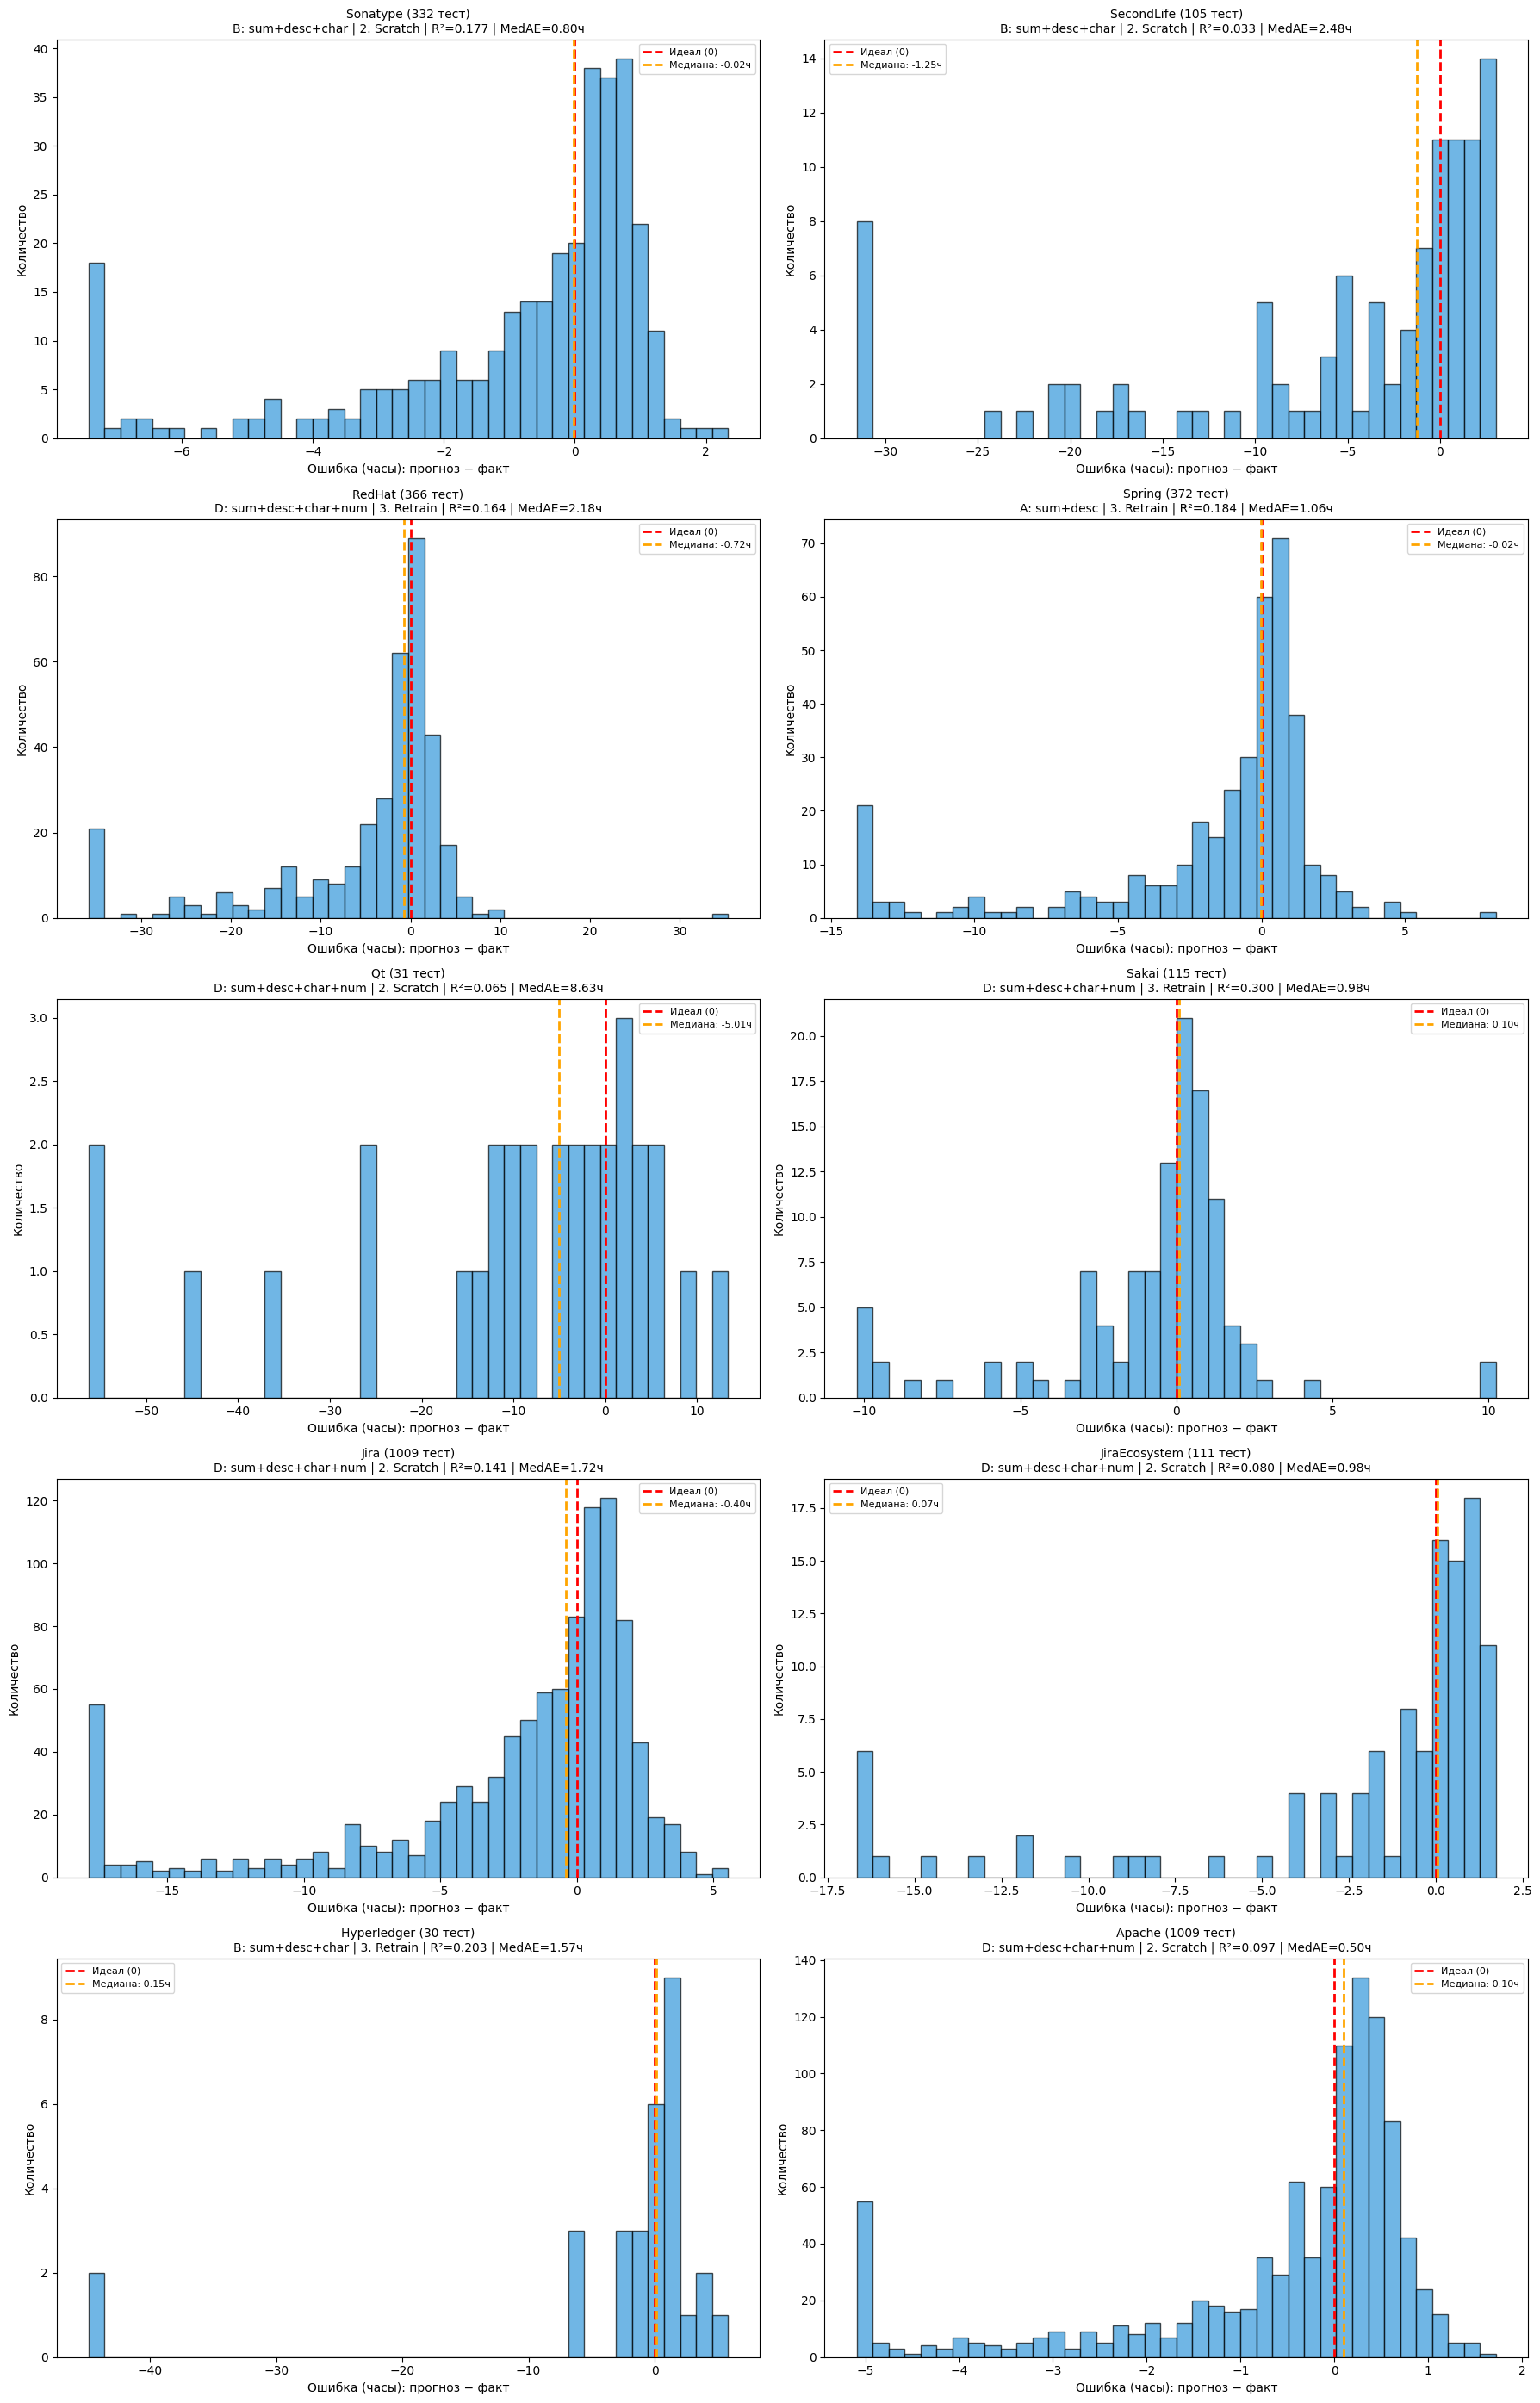

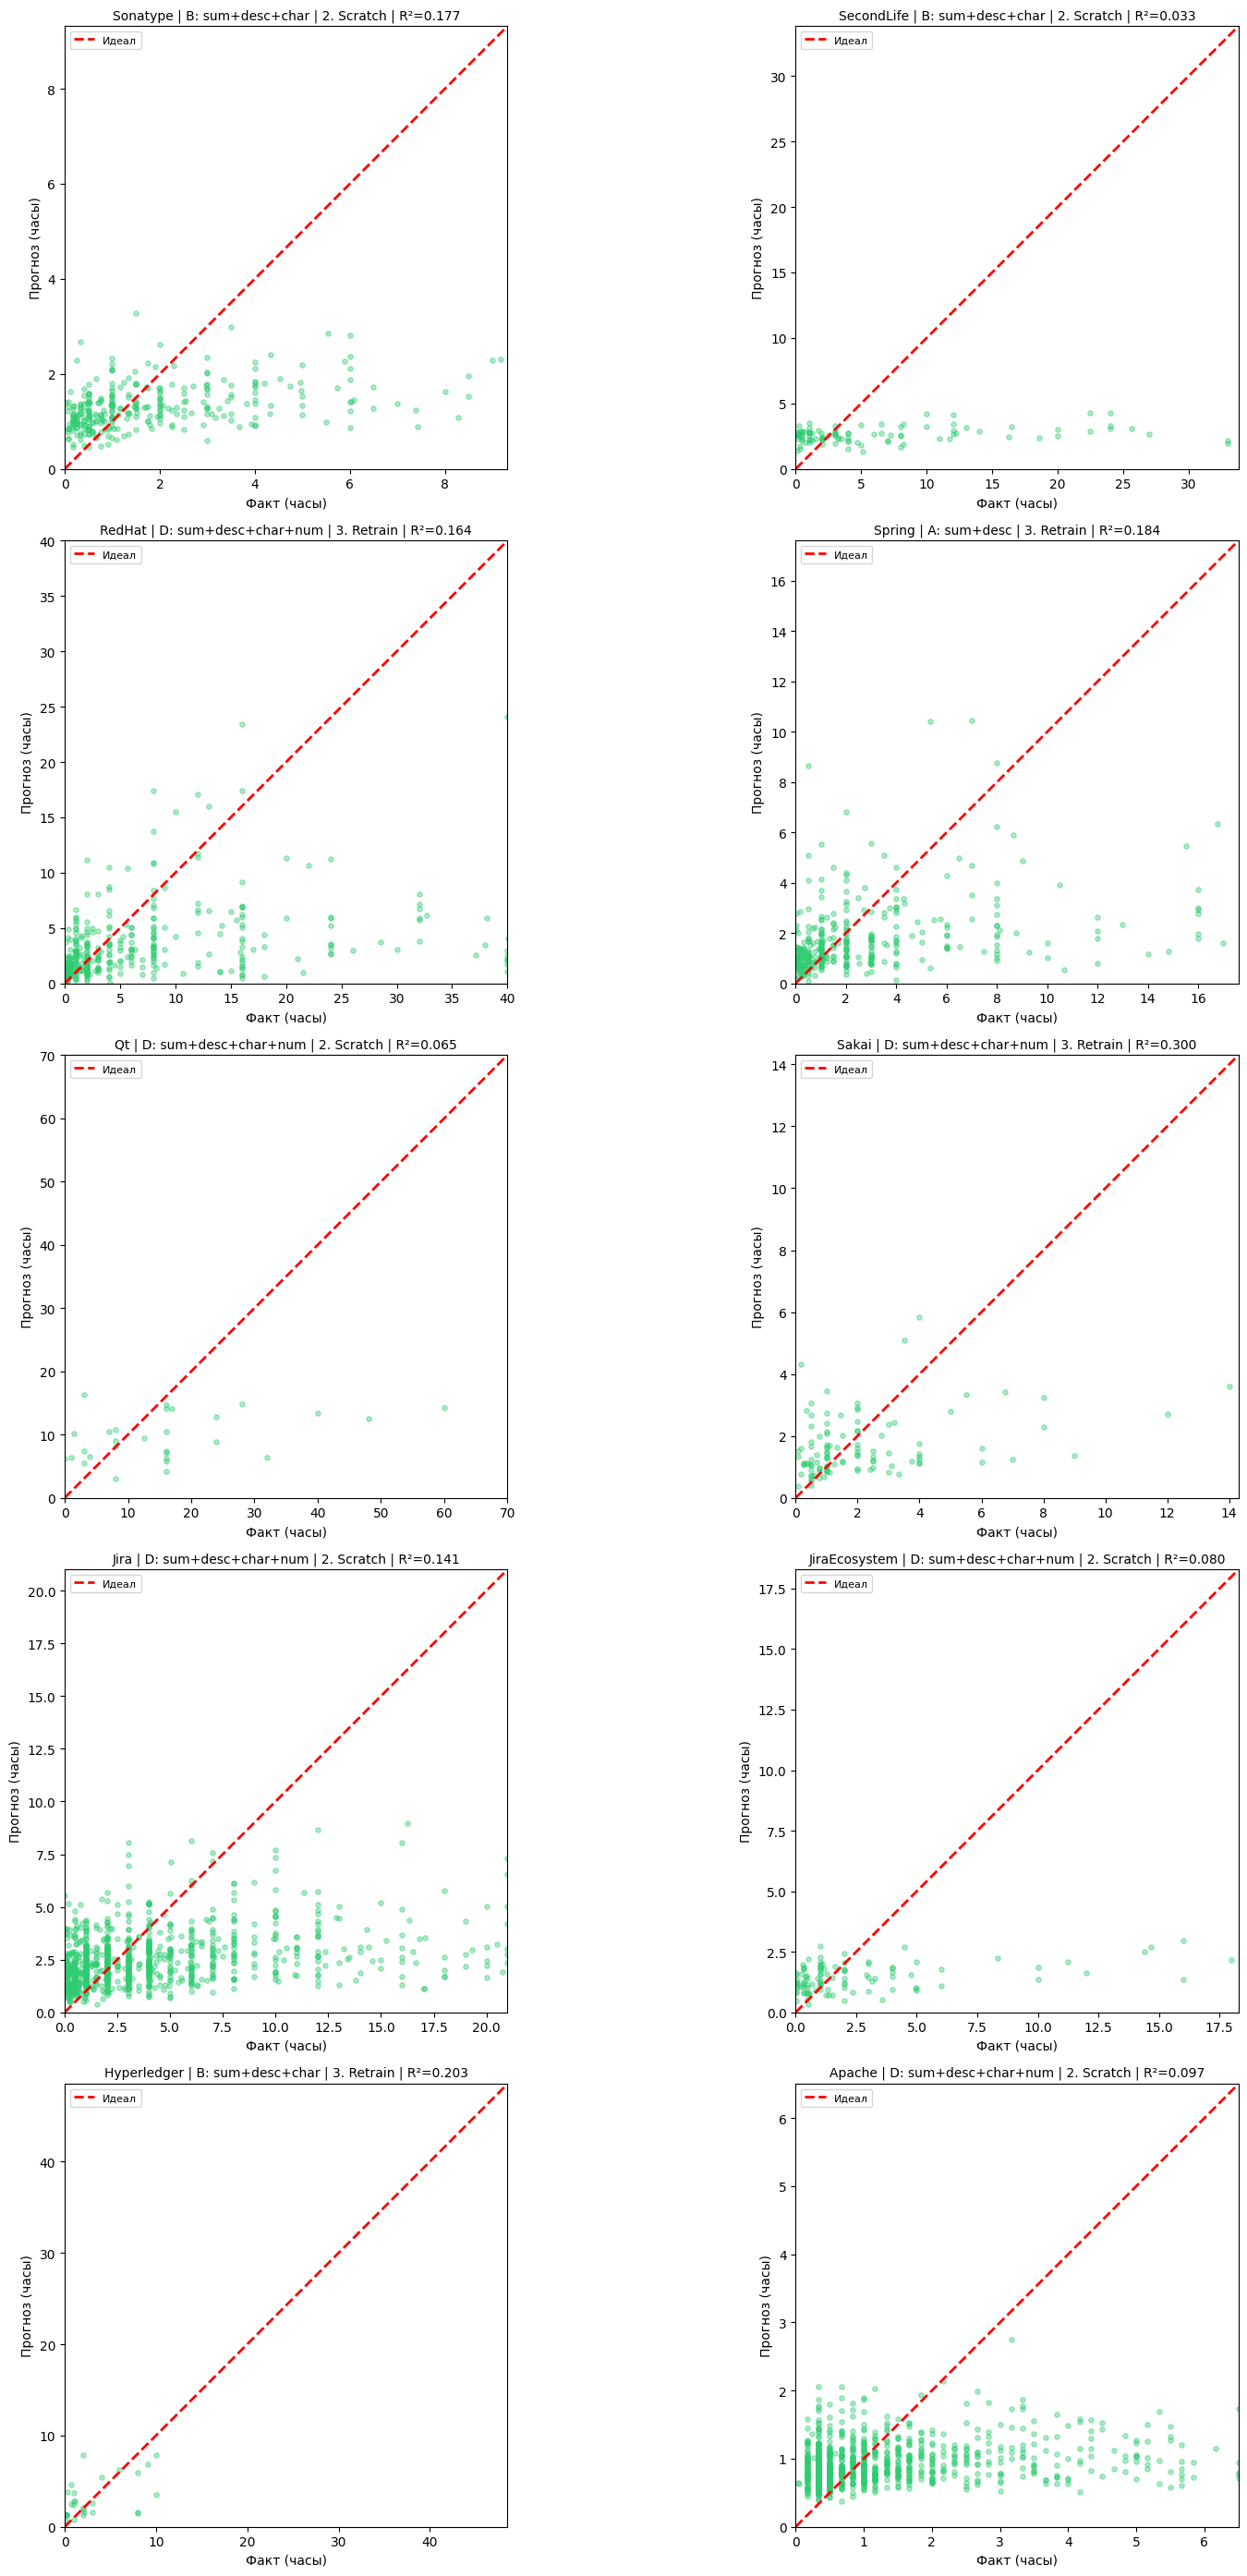

In [25]:
# ============================================================
# Выбор лучших конфигураций
# ============================================================

best_configs = {}
for proj in projects:
    proj_data = full_df[full_df["project"] == proj]
    best_idx = proj_data["R2"].idxmax()
    best = proj_data.loc[best_idx]
    best_configs[proj] = (best["config"], best["model"])

print("Лучшие конфигурации:")
for proj, (cfg, mdl) in best_configs.items():
    r2 = full_df[(full_df["project"] == proj) & 
                 (full_df["config"] == cfg) & 
                 (full_df["model"] == mdl)]["R2"].values[0]
    print(f"  {proj:<15} → {cfg:<25} {mdl:<15} R²={r2:.4f}")

# ============================================================
# Графики распределения ошибок
# ============================================================

fig, axes = plt.subplots(5, 2, figsize=(18, 28))
axes = axes.flatten()

# Сохраняем предсказания для scatter-графиков
saved_predictions = {}

for idx, target_project in enumerate(projects):
    config_name, model_name = best_configs[target_project]
    config = configs[config_name]
    
    mask_target = df_balanced["source_collection"] == target_project
    df_pretrain_raw = df_balanced[~mask_target]
    df_target_raw = df_balanced[mask_target]
    df_finetune_raw, df_test_raw = train_test_split(
        df_target_raw, test_size=0.2, random_state=42
    )
    
    # TF-IDF summary
    tfidf_sum = TfidfVectorizer(
        max_features=15000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    s_pre = tfidf_sum.fit_transform(df_pretrain_raw["summary"].fillna(""))
    s_ft = tfidf_sum.transform(df_finetune_raw["summary"].fillna(""))
    s_te = tfidf_sum.transform(df_test_raw["summary"].fillna(""))
    
    # TF-IDF description
    tfidf_desc = TfidfVectorizer(
        max_features=35000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    d_pre = tfidf_desc.fit_transform(df_pretrain_raw["description"].fillna(""))
    d_ft = tfidf_desc.transform(df_finetune_raw["description"].fillna(""))
    d_te = tfidf_desc.transform(df_test_raw["description"].fillna(""))
    
    parts_pre, parts_ft, parts_te = [s_pre, d_pre], [s_ft, d_ft], [s_te, d_te]
    
    if config["char"]:
        tfidf_char = TfidfVectorizer(
            max_features=20000, analyzer="char_wb",
            ngram_range=(3, 5), min_df=3, max_df=0.95, sublinear_tf=True
        )
        c_pre = tfidf_char.fit_transform(df_pretrain_raw["text"])
        c_ft = tfidf_char.transform(df_finetune_raw["text"])
        c_te = tfidf_char.transform(df_test_raw["text"])
        parts_pre.append(c_pre); parts_ft.append(c_ft); parts_te.append(c_te)
    
    if config["num"]:
        def make_num(df):
            return np.hstack([
                df["summary"].fillna("").str.len().values.reshape(-1, 1),
                df["description"].fillna("").str.len().values.reshape(-1, 1),
                (df["description"].fillna("").str.len() > 0).astype(int).values.reshape(-1, 1),
                df["text"].str.len().values.reshape(-1, 1)
            ])
        scaler = StandardScaler()
        n_pre = scaler.fit_transform(make_num(df_pretrain_raw))
        n_ft = scaler.transform(make_num(df_finetune_raw))
        n_te = scaler.transform(make_num(df_test_raw))
        parts_pre.append(csr_matrix(n_pre*20))
        parts_ft.append(csr_matrix(n_ft*20))
        parts_te.append(csr_matrix(n_te*20))
    
    X_pre = hstack(parts_pre); X_ft = hstack(parts_ft); X_te = hstack(parts_te)
    y_pre = df_pretrain_raw["log_timespent"].values
    y_ft = df_finetune_raw["log_timespent"].values
    y_te = df_test_raw["log_timespent"].values
    
    if model_name == "1. Pretrain":
        model = Ridge(alpha=10.0).fit(X_pre, y_pre)
    elif model_name == "2. Scratch":
        model = Ridge(alpha=10.0).fit(X_ft, y_ft)
    else:
        w = len(y_pre) / len(y_ft)
        X_c = vstack([X_pre, X_ft])
        y_c = np.concatenate([y_pre, y_ft])
        wts = np.concatenate([np.ones(len(y_pre)), np.ones(len(y_ft)) * w])
        model = Ridge(alpha=10.0).fit(X_c, y_c, sample_weight=wts)
    
    y_pred = model.predict(X_te)
    
    y_te_sec = np.expm1(y_te)
    y_pred_sec = np.expm1(y_pred)
    errors_hours = (y_pred_sec - y_te_sec) / 3600
    abs_errors_hours = np.abs(errors_hours)
    r2 = r2_score(y_te, y_pred)
    med_err = np.median(abs_errors_hours)
    
    saved_predictions[target_project] = {
        "y_te": y_te, "y_pred": y_pred, "r2": r2
    }
    
    # Гистограмма ошибок
    ax = axes[idx]
    clip_val = np.percentile(np.abs(errors_hours), 95)
    errors_clipped = np.clip(errors_hours, -clip_val, clip_val)
    
    ax.hist(errors_clipped, bins=40, edgecolor="black", alpha=0.7, color="#3498db")
    ax.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Идеал (0)")
    ax.axvline(x=np.median(errors_hours), color="orange", linestyle="--",
               linewidth=2, label=f"Медиана: {np.median(errors_hours):.2f}ч")
    
    ax.set_title(f"{target_project} ({len(df_test_raw)} тест)\n"
                 f"{config_name} | {model_name} | R²={r2:.3f} | MedAE={med_err:.2f}ч",
                 fontsize=10)
    ax.set_xlabel("Ошибка (часы): прогноз − факт")
    ax.set_ylabel("Количество")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# Scatter: факт vs прогноз
# ============================================================

fig, axes = plt.subplots(5, 2, figsize=(18, 28))
axes = axes.flatten()

for idx, target_project in enumerate(projects):
    config_name, model_name = best_configs[target_project]
    sp = saved_predictions[target_project]
    
    y_te_h = np.expm1(sp["y_te"]) / 3600
    y_pred_h = np.expm1(sp["y_pred"]) / 3600
    
    ax = axes[idx]
    max_val = np.percentile(y_te_h, 95)
    
    ax.scatter(y_te_h, y_pred_h, alpha=0.4, s=15, color="#2ecc71")
    ax.plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Идеал")
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel("Факт (часы)")
    ax.set_ylabel("Прогноз (часы)")
    ax.set_title(f"{target_project} | {config_name} | {model_name} | R²={sp['r2']:.3f}",
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### Поиск оптимального alpha

In [ ]:
from scipy.sparse import hstack, vstack, csr_matrix

# ============================================================
# Перебор alpha для Ridge на конфигурации B: sum+desc+char
# ============================================================

max_per_project = df_clean[df_clean["source_collection"] != "Apache"]["source_collection"].value_counts().max()
print(f"Второй по размеру проект: {max_per_project} задач")

df_apache = df_clean[df_clean["source_collection"] == "Apache"].sample(
    n=max_per_project, random_state=42
)
df_other = df_clean[df_clean["source_collection"] != "Apache"]
df_balanced = pd.concat([df_other, df_apache]).reset_index(drop=True)
projects = df_clean["source_collection"].unique()

alphas = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]

alpha_results = []

for target_project in projects:
    mask_target = df_balanced["source_collection"] == target_project
    df_pretrain_raw = df_balanced[~mask_target]
    df_target_raw = df_balanced[mask_target]
    df_finetune_raw, df_test_raw = train_test_split(
        df_target_raw, test_size=0.2, random_state=42
    )
    
    # TF-IDF summary
    tfidf_sum = TfidfVectorizer(
        max_features=15000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    s_pre = tfidf_sum.fit_transform(df_pretrain_raw["summary"].fillna(""))
    s_ft = tfidf_sum.transform(df_finetune_raw["summary"].fillna(""))
    s_te = tfidf_sum.transform(df_test_raw["summary"].fillna(""))
    
    # TF-IDF description
    tfidf_desc = TfidfVectorizer(
        max_features=35000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    d_pre = tfidf_desc.fit_transform(df_pretrain_raw["description"].fillna(""))
    d_ft = tfidf_desc.transform(df_finetune_raw["description"].fillna(""))
    d_te = tfidf_desc.transform(df_test_raw["description"].fillna(""))
    
    # Char n-grams
    tfidf_char = TfidfVectorizer(
        max_features=20000, analyzer="char_wb",
        ngram_range=(3, 5), min_df=3, max_df=0.95, sublinear_tf=True
    )
    c_pre = tfidf_char.fit_transform(df_pretrain_raw["text"])
    c_ft = tfidf_char.transform(df_finetune_raw["text"])
    c_te = tfidf_char.transform(df_test_raw["text"])
    
    X_pre = hstack([s_pre, d_pre, c_pre])
    X_ft = hstack([s_ft, d_ft, c_ft])
    X_te = hstack([s_te, d_te, c_te])
    
    y_pre = df_pretrain_raw["log_timespent"].values
    y_ft = df_finetune_raw["log_timespent"].values
    y_te = df_test_raw["log_timespent"].values
    y_te_sec = np.expm1(y_te)
    
    def calc_metrics(y_pred_log):
        r2 = r2_score(y_te, y_pred_log)
        yp = np.expm1(y_pred_log)
        med = np.median(np.abs(y_te_sec - yp)) / 3600
        mask = y_te_sec > 600
        mape = np.median(np.abs(y_te_sec[mask] - yp[mask]) / y_te_sec[mask]) * 100 if mask.sum() > 5 else np.nan
        return r2, med, mape
    
    w = len(y_pre) / len(y_ft)
    X_comb = vstack([X_pre, X_ft])
    y_comb = np.concatenate([y_pre, y_ft])
    wts = np.concatenate([np.ones(len(y_pre)), np.ones(len(y_ft)) * w])
    
    for alpha in alphas:
        # Scratch
        m = Ridge(alpha=alpha).fit(X_ft, y_ft)
        r2, med, mape = calc_metrics(m.predict(X_te))
        alpha_results.append({
            "project": target_project, "model": "Scratch",
            "alpha": alpha, "R2": r2, "MedAE": med, "MdAPE": mape
        })
        
        # Retrain adaptive
        m = Ridge(alpha=alpha).fit(X_comb, y_comb, sample_weight=wts)
        r2, med, mape = calc_metrics(m.predict(X_te))
        alpha_results.append({
            "project": target_project, "model": "Retrain",
            "alpha": alpha, "R2": r2, "MedAE": med, "MdAPE": mape
        })
    
    print(f"✅ {target_project}")

alpha_df = pd.DataFrame(alpha_results)

# ============================================================
# Сводные таблицы
# ============================================================

print("\n" + "="*80)
print("СРЕДНИЙ R² ПО ВСЕМ ПРОЕКТАМ")
print("="*80)
pivot = alpha_df.groupby(["alpha", "model"])["R2"].mean().unstack("model").round(4)
print(pivot.to_string())

print("\n\nСРЕДНИЙ MdAPE % ПО ВСЕМ ПРОЕКТАМ")
print("="*80)
pivot_mape = alpha_df.groupby(["alpha", "model"])["MdAPE"].mean().unstack("model").round(1)
print(pivot_mape.to_string())

# Лучшие alpha
best_scratch_alpha = pivot["Scratch"].idxmax()
best_retrain_alpha = pivot["Retrain"].idxmax()
print(f"\n\nЛучшая alpha для Scratch:  {best_scratch_alpha}  (R²={pivot.loc[best_scratch_alpha, 'Scratch']:.4f})")
print(f"Лучшая alpha для Retrain:  {best_retrain_alpha}  (R²={pivot.loc[best_retrain_alpha, 'Retrain']:.4f})")

# ============================================================
# Детально: лучшая alpha по каждому проекту
# ============================================================

print(f"\n\n{'='*80}")
print("ЛУЧШАЯ ALPHA ПО КАЖДОМУ ПРОЕКТУ")
print(f"{'='*80}")
print(f"{'Проект':<15} | {'Scratch':^25} | {'Retrain':^25}")
print(f"{'':15} | {'alpha':>6} {'R²':>8} {'MdAPE':>7} | {'alpha':>6} {'R²':>8} {'MdAPE':>7}")
print("-"*75)

for proj in projects:
    for mdl in ["Scratch", "Retrain"]:
        proj_mdl = alpha_df[(alpha_df["project"] == proj) & (alpha_df["model"] == mdl)]
        best = proj_mdl.loc[proj_mdl["R2"].idxmax()]
        if mdl == "Scratch":
            print(f"{proj:<15} | {best['alpha']:>6.1f} {best['R2']:>8.4f} {best['MdAPE']:>6.1f}%", end="")
        else:
            print(f" | {best['alpha']:>6.1f} {best['R2']:>8.4f} {best['MdAPE']:>6.1f}%")

Второй по размеру проект: 5041 задач
✅ Sonatype
✅ SecondLife
✅ RedHat
✅ Spring
✅ Qt
✅ Sakai
✅ Jira
✅ JiraEcosystem
✅ Apache
✅ Hyperledger

СРЕДНИЙ R² ПО ВСЕМ ПРОЕКТАМ
model         Retrain   Scratch
alpha                          
0.100000    -0.462800  0.033100
0.500000    -0.154600  0.099500
1.000000    -0.058900  0.123000
5.000000     0.073400  0.128500
10.000000    0.100700  0.108300
50.000000    0.113100  0.048000
100.000000   0.099000  0.027400
500.000000   0.033300  0.000900
1000.000000  0.000700 -0.003700


СРЕДНИЙ MdAPE % ПО ВСЕМ ПРОЕКТАМ
model         Retrain   Scratch
alpha                          
0.100000    78.700000 68.400000
0.500000    73.100000 67.100000
1.000000    70.100000 66.200000
5.000000    67.100000 65.800000
10.000000   66.100000 66.000000
50.000000   67.300000 67.400000
100.000000  68.100000 67.700000
500.000000  70.700000 69.000000
1000.000000 71.100000 69.300000


Лучшая alpha для Scratch:  5.0  (R²=0.1285)
Лучшая alpha для Retrain:  50.0  (R²=0.1131)


Л

NameError: name 'plt' is not defined

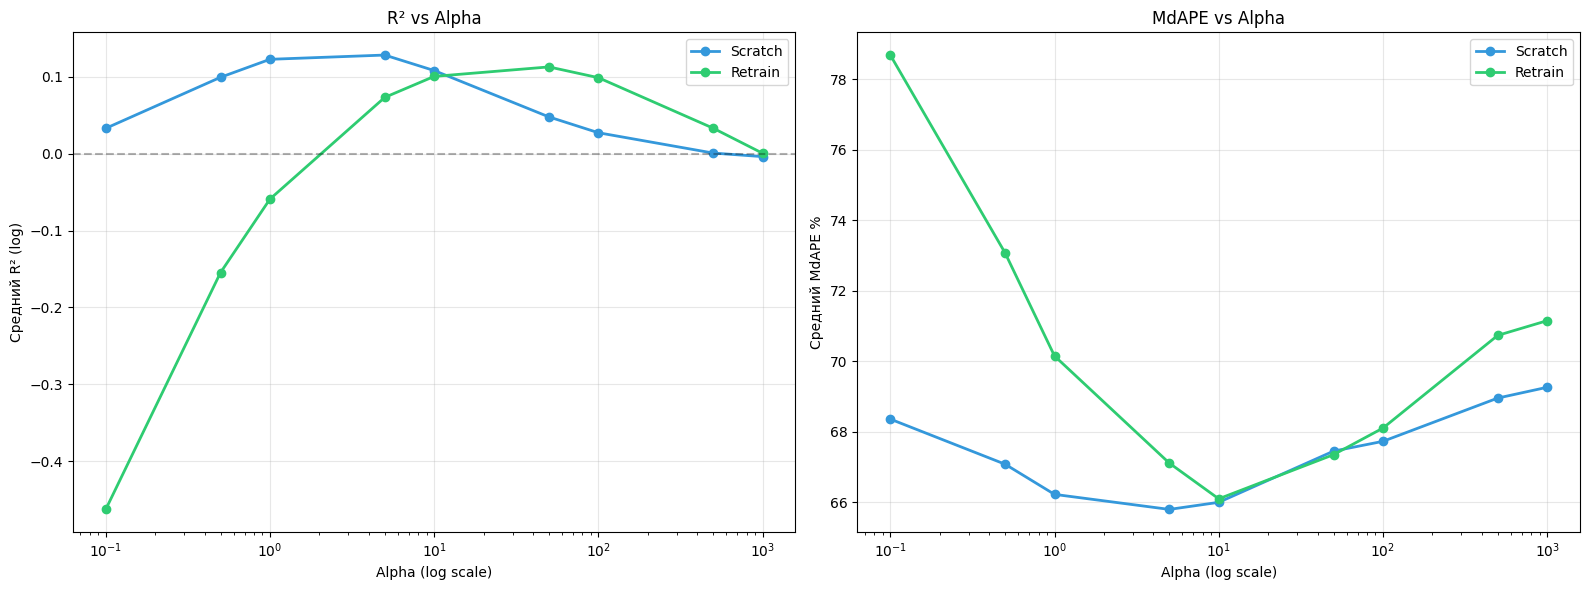

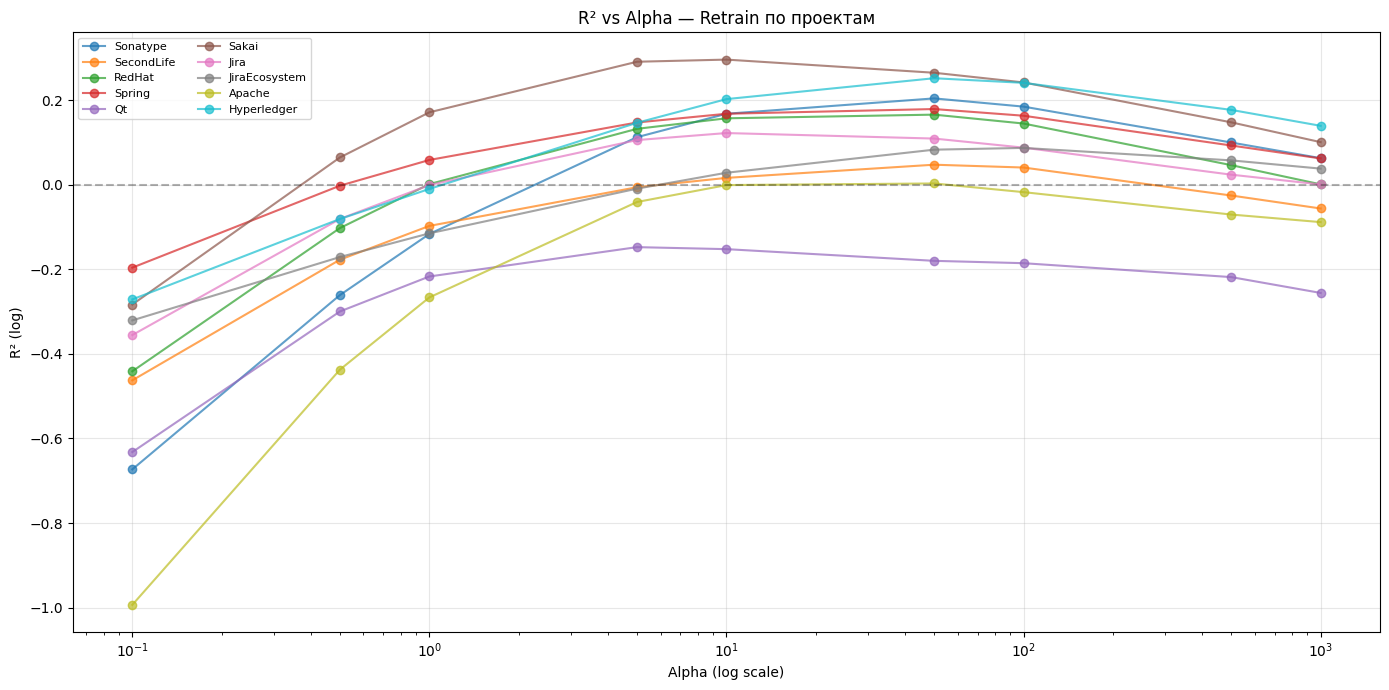

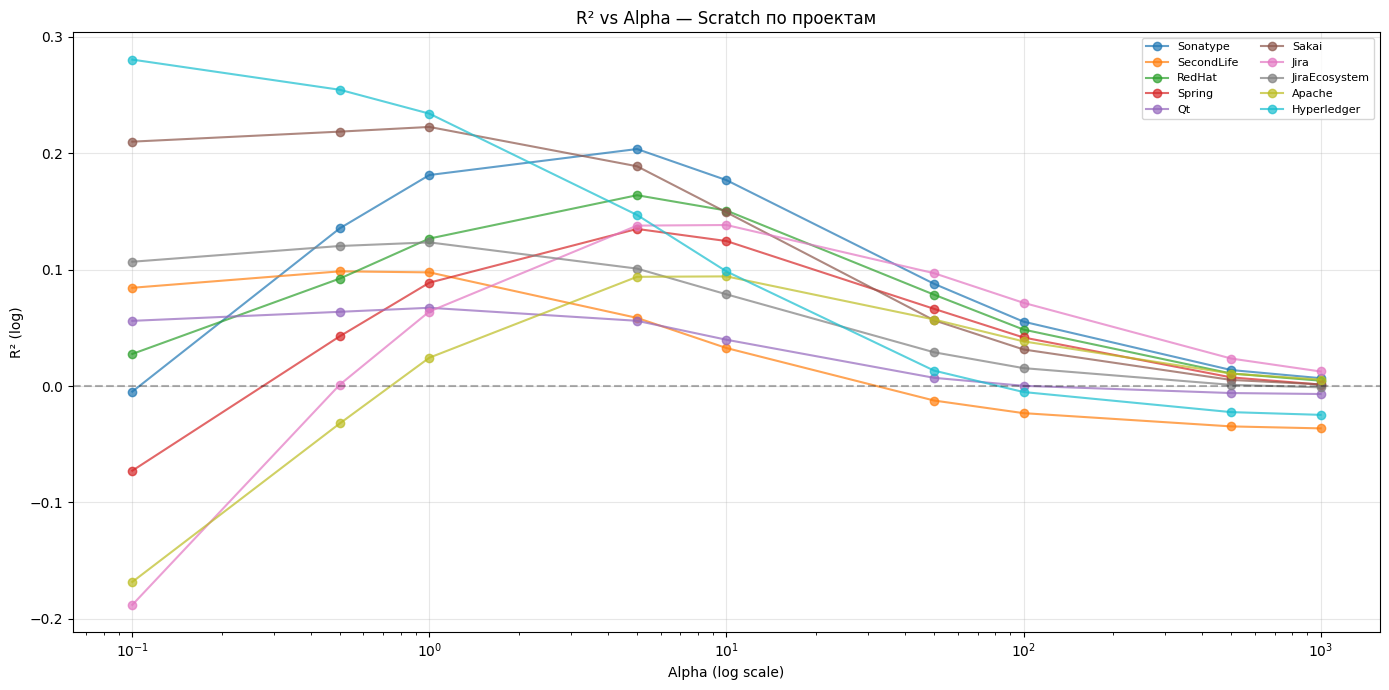

In [8]:
import matplotlib.pyplot as plt
# ============================================================
# Визуализация
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Средний R² vs alpha
ax = axes[0]
for mdl, color in [("Scratch", "#3498db"), ("Retrain", "#2ecc71")]:
    means = alpha_df[alpha_df["model"] == mdl].groupby("alpha")["R2"].mean()
    ax.plot(means.index, means.values, "o-", label=mdl, color=color, linewidth=2, markersize=6)

ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Средний R² (log)")
ax.set_title("R² vs Alpha")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)

# График 2: Средний MdAPE vs alpha
ax = axes[1]
for mdl, color in [("Scratch", "#3498db"), ("Retrain", "#2ecc71")]:
    means = alpha_df[alpha_df["model"] == mdl].groupby("alpha")["MdAPE"].mean()
    ax.plot(means.index, means.values, "o-", label=mdl, color=color, linewidth=2, markersize=6)

ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Средний MdAPE %")
ax.set_title("MdAPE vs Alpha")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# График 3: R² vs alpha по каждому проекту (только Retrain)
fig, ax = plt.subplots(figsize=(14, 7))
for proj in projects:
    proj_data = alpha_df[(alpha_df["project"] == proj) & (alpha_df["model"] == "Retrain")]
    ax.plot(proj_data["alpha"], proj_data["R2"], "o-", label=proj, alpha=0.7)

ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("R² (log)")
ax.set_title("R² vs Alpha — Retrain по проектам")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# График 4: R² vs alpha по каждому проекту (только Scratch)
fig, ax = plt.subplots(figsize=(14, 7))
for proj in projects:
    proj_data = alpha_df[(alpha_df["project"] == proj) & (alpha_df["model"] == "Scratch")]
    ax.plot(proj_data["alpha"], proj_data["R2"], "o-", label=proj, alpha=0.7)

ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("R² (log)")
ax.set_title("R² vs Alpha — Scratch по проектам")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### Перебор количества признаков

In [ ]:
# ============================================================
# Получаем лучшие alpha для каждого проекта из alpha_df
# ============================================================

best_alphas = {}
for proj in projects:
    proj_data = alpha_df[alpha_df["project"] == proj]
    best_scratch = proj_data[proj_data["model"] == "Scratch"].loc[
        proj_data[proj_data["model"] == "Scratch"]["R2"].idxmax()
    ]["alpha"]
    best_retrain = proj_data[proj_data["model"] == "Retrain"].loc[
        proj_data[proj_data["model"] == "Retrain"]["R2"].idxmax()
    ]["alpha"]
    best_alphas[proj] = {"Scratch": best_scratch, "Retrain": best_retrain}

print("Лучшие alpha по проектам:")
for proj, alphas in best_alphas.items():
    print(f"  {proj:<15} Scratch={alphas['Scratch']:<6.1f} Retrain={alphas['Retrain']:<6.1f}")

# ============================================================
# Перебор max_features для summary, description, char
# ============================================================

summary_sizes = [5000, 15000, 25000]
desc_sizes = [20000, 35000, 50000]
char_sizes = [10000, 20000, 30000]

total = len(summary_sizes) * len(desc_sizes) * len(char_sizes)
print(f"\nКомбинаций: {total} × {len(projects)} проектов × 2 модели = {total * len(projects) * 2} обучений")

feat_results = []
combo_idx = 0

for s_size in summary_sizes:
    for d_size in desc_sizes:
        for c_size in char_sizes:
            combo_idx += 1
            combo_name = f"s{s_size//1000}k_d{d_size//1000}k_c{c_size//1000}k"
            
            for target_project in projects:
                mask_target = df_balanced["source_collection"] == target_project
                df_pretrain_raw = df_balanced[~mask_target]
                df_target_raw = df_balanced[mask_target]
                df_finetune_raw, df_test_raw = train_test_split(
                    df_target_raw, test_size=0.2, random_state=42
                )
                
                tfidf_sum = TfidfVectorizer(
                    max_features=s_size, ngram_range=(1, 2),
                    min_df=3, max_df=0.95, sublinear_tf=True
                )
                s_pre = tfidf_sum.fit_transform(df_pretrain_raw["summary"].fillna(""))
                s_ft = tfidf_sum.transform(df_finetune_raw["summary"].fillna(""))
                s_te = tfidf_sum.transform(df_test_raw["summary"].fillna(""))
                
                tfidf_desc = TfidfVectorizer(
                    max_features=d_size, ngram_range=(1, 2),
                    min_df=3, max_df=0.95, sublinear_tf=True
                )
                d_pre = tfidf_desc.fit_transform(df_pretrain_raw["description"].fillna(""))
                d_ft = tfidf_desc.transform(df_finetune_raw["description"].fillna(""))
                d_te = tfidf_desc.transform(df_test_raw["description"].fillna(""))
                
                tfidf_char = TfidfVectorizer(
                    max_features=c_size, analyzer="char_wb",
                    ngram_range=(3, 5), min_df=3, max_df=0.95, sublinear_tf=True
                )
                c_pre = tfidf_char.fit_transform(df_pretrain_raw["text"])
                c_ft = tfidf_char.transform(df_finetune_raw["text"])
                c_te = tfidf_char.transform(df_test_raw["text"])
                
                X_pre = hstack([s_pre, d_pre, c_pre])
                X_ft = hstack([s_ft, d_ft, c_ft])
                X_te = hstack([s_te, d_te, c_te])
                
                y_pre = df_pretrain_raw["log_timespent"].values
                y_ft = df_finetune_raw["log_timespent"].values
                y_te = df_test_raw["log_timespent"].values
                y_te_sec = np.expm1(y_te)
                
                def calc_metrics(y_pred_log):
                    r2 = r2_score(y_te, y_pred_log)
                    yp = np.expm1(y_pred_log)
                    med = np.median(np.abs(y_te_sec - yp)) / 3600
                    mask = y_te_sec > 600
                    mape = np.median(np.abs(y_te_sec[mask] - yp[mask]) / y_te_sec[mask]) * 100 if mask.sum() > 5 else np.nan
                    return r2, med, mape
                
                # Scratch с лучшей alpha
                a_s = best_alphas[target_project]["Scratch"]
                m = Ridge(alpha=a_s).fit(X_ft, y_ft)
                r2, med, mape = calc_metrics(m.predict(X_te))
                feat_results.append({
                    "combo": combo_name, "s": s_size, "d": d_size, "c": c_size,
                    "project": target_project, "model": "Scratch",
                    "alpha": a_s, "R2": r2, "MedAE": med, "MdAPE": mape
                })
                
                # Retrain с лучшей alpha
                a_r = best_alphas[target_project]["Retrain"]
                w = len(y_pre) / len(y_ft)
                X_c = vstack([X_pre, X_ft])
                y_c = np.concatenate([y_pre, y_ft])
                wts = np.concatenate([np.ones(len(y_pre)), np.ones(len(y_ft)) * w])
                m = Ridge(alpha=a_r).fit(X_c, y_c, sample_weight=wts)
                r2, med, mape = calc_metrics(m.predict(X_te))
                feat_results.append({
                    "combo": combo_name, "s": s_size, "d": d_size, "c": c_size,
                    "project": target_project, "model": "Retrain",
                    "alpha": a_r, "R2": r2, "MedAE": med, "MdAPE": mape
                })
            
            print(f"  [{combo_idx}/{total}] {combo_name} ✅")

feat_df = pd.DataFrame(feat_results)

# ============================================================
# СВОДКИ
# ============================================================

# Средний R² по комбинациям
print("\n" + "="*80)
print("СРЕДНИЙ R² ПО КОМБИНАЦИЯМ (все проекты)")
print("="*80)

pivot_feat = feat_df.groupby(["combo", "model"])["R2"].mean().unstack("model").round(4)
pivot_feat["best"] = pivot_feat.max(axis=1)
pivot_feat = pivot_feat.sort_values("best", ascending=False)
print(pivot_feat.to_string())

# Средний MdAPE
print("\n\nСРЕДНИЙ MdAPE % ПО КОМБИНАЦИЯМ")
print("="*80)
pivot_mape = feat_df.groupby(["combo", "model"])["MdAPE"].mean().unstack("model").round(1)
pivot_mape = pivot_mape.loc[pivot_feat.index]  # тот же порядок
print(pivot_mape.to_string())

# Лучшая комбинация
best_scratch_combo = pivot_feat["Scratch"].idxmax()
best_retrain_combo = pivot_feat["Retrain"].idxmax()
print(f"\n\nЛучшая комбинация Scratch:  {best_scratch_combo}  R²={pivot_feat.loc[best_scratch_combo, 'Scratch']:.4f}")
print(f"Лучшая комбинация Retrain:  {best_retrain_combo}  R²={pivot_feat.loc[best_retrain_combo, 'Retrain']:.4f}")

# Детально по проектам для лучших комбинаций
print(f"\n\n{'='*80}")
print("ЛУЧШАЯ КОМБИНАЦИЯ ПО КАЖДОМУ ПРОЕКТУ")
print(f"{'='*80}")
print(f"{'Проект':<15} | {'Scratch':^35} | {'Retrain':^35}")
print(f"{'':15} | {'combo':>18} {'R²':>7} {'MdAPE':>6} | {'combo':>18} {'R²':>7} {'MdAPE':>6}")
print("-"*90)

for proj in projects:
    for mdl in ["Scratch", "Retrain"]:
        proj_mdl = feat_df[(feat_df["project"] == proj) & (feat_df["model"] == mdl)]
        best = proj_mdl.loc[proj_mdl["R2"].idxmax()]
        if mdl == "Scratch":
            print(f"{proj:<15} | {best['combo']:>18} {best['R2']:>7.4f} {best['MdAPE']:>5.1f}%", end="")
        else:
            print(f" | {best['combo']:>18} {best['R2']:>7.4f} {best['MdAPE']:>5.1f}%")

# ============================================================
# Визуализация: влияние каждого параметра
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, param, label in zip(axes, ["s", "d", "c"], 
                              ["Summary max_features", "Description max_features", "Char max_features"]):
    for mdl, color in [("Scratch", "#3498db"), ("Retrain", "#2ecc71")]:
        means = feat_df[feat_df["model"] == mdl].groupby(param)["R2"].mean()
        ax.plot(means.index, means.values, "o-", label=mdl, color=color, linewidth=2, markersize=8)
    
    ax.set_xlabel(label)
    ax.set_ylabel("Средний R²")
    ax.set_title(f"R² vs {label}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Перебор весов для признаков

Комбинаций весов: 125
✅ Sonatype
✅ SecondLife
✅ RedHat
✅ Spring
✅ Qt
✅ Sakai
✅ Jira
✅ JiraEcosystem
✅ Apache
✅ Hyperledger

ТОП-10 КОМБИНАЦИЙ ВЕСОВ ПО СРЕДНЕМУ R²

--- Scratch ---
                                 R2     MdAPE
ws       wd       wc                         
1.000000 2.000000 1.000000 0.152800 65.480400
         1.000000 1.000000 0.152700 66.075000
0.500000 1.000000 1.000000 0.150500 65.374200
         0.500000 1.000000 0.146300 65.478100
1.000000 2.000000 0.500000 0.145800 65.541200
0.500000 2.000000 1.000000 0.144800 65.905400
1.000000 0.500000 1.000000 0.144700 66.542600
         2.000000 2.000000 0.143500 65.010700
         3.000000 1.000000 0.141700 65.775200
         1.000000 2.000000 0.139800 65.762700

--- Retrain ---
                                 R2     MdAPE
ws       wd       wc                         
0.500000 1.000000 2.000000 0.123100 65.701200
                  1.000000 0.122900 65.598200
1.000000 1.000000 2.000000 0.122700 65.003000
                  1.0

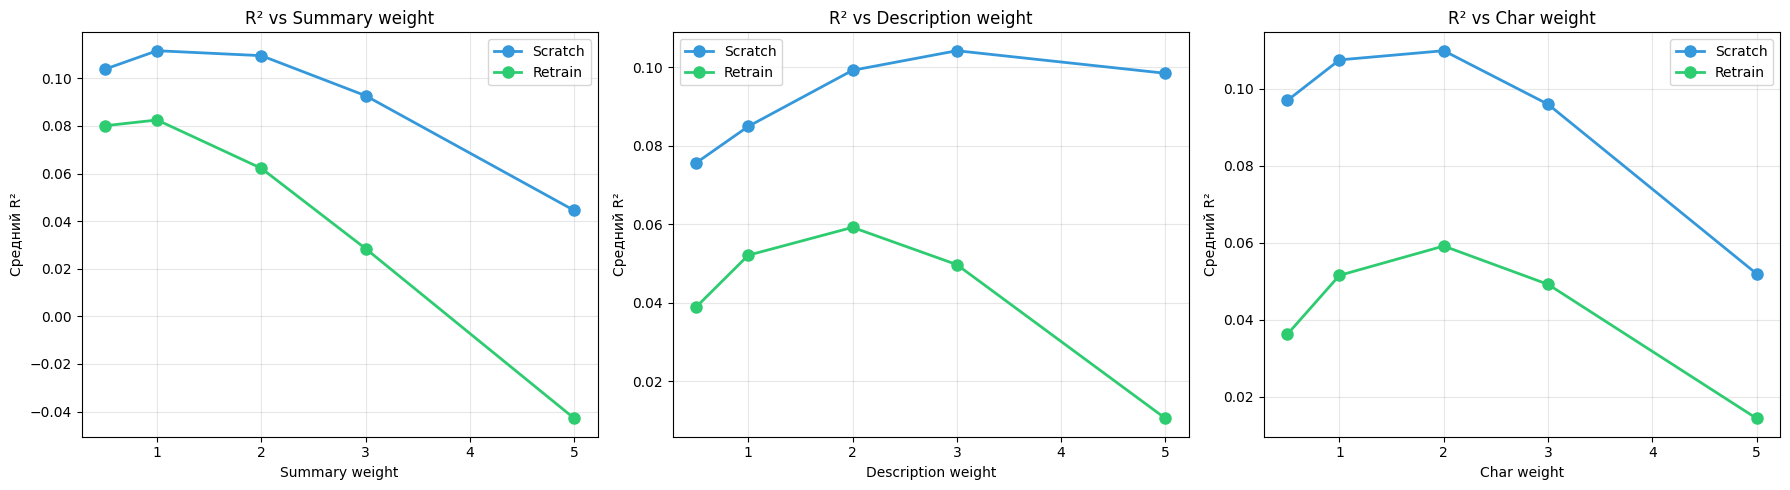

In [ ]:
# ============================================================
# Перебор весов для summary, description, char
# TF-IDF считается один раз, потом домножаем и обучаем Ridge
# ============================================================

weight_options = [0.5, 1.0, 2.0, 3.0, 5.0]

total_combos = len(weight_options) ** 3
print(f"Комбинаций весов: {total_combos}")

weight_results = []

for target_project in projects:
    mask_target = df_balanced["source_collection"] == target_project
    df_pretrain_raw = df_balanced[~mask_target]
    df_target_raw = df_balanced[mask_target]
    df_finetune_raw, df_test_raw = train_test_split(
        df_target_raw, test_size=0.2, random_state=42
    )
    
    # TF-IDF — считаем один раз
    tfidf_sum = TfidfVectorizer(
        max_features=15000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    s_pre = tfidf_sum.fit_transform(df_pretrain_raw["summary"].fillna(""))
    s_ft = tfidf_sum.transform(df_finetune_raw["summary"].fillna(""))
    s_te = tfidf_sum.transform(df_test_raw["summary"].fillna(""))
    
    tfidf_desc = TfidfVectorizer(
        max_features=35000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    d_pre = tfidf_desc.fit_transform(df_pretrain_raw["description"].fillna(""))
    d_ft = tfidf_desc.transform(df_finetune_raw["description"].fillna(""))
    d_te = tfidf_desc.transform(df_test_raw["description"].fillna(""))
    
    tfidf_char = TfidfVectorizer(
        max_features=20000, analyzer="char_wb",
        ngram_range=(3, 5), min_df=3, max_df=0.95, sublinear_tf=True
    )
    c_pre = tfidf_char.fit_transform(df_pretrain_raw["text"])
    c_ft = tfidf_char.transform(df_finetune_raw["text"])
    c_te = tfidf_char.transform(df_test_raw["text"])
    
    y_pre = df_pretrain_raw["log_timespent"].values
    y_ft = df_finetune_raw["log_timespent"].values
    y_te = df_test_raw["log_timespent"].values
    y_te_sec = np.expm1(y_te)
    
    a_s = best_alphas[target_project]["Scratch"]
    a_r = best_alphas[target_project]["Retrain"]
    w_sample = len(y_pre) / len(y_ft)
    
    def calc_metrics(y_pred_log):
        r2 = r2_score(y_te, y_pred_log)
        yp = np.expm1(y_pred_log)
        med = np.median(np.abs(y_te_sec - yp)) / 3600
        mask = y_te_sec > 600
        mape = np.median(np.abs(y_te_sec[mask] - yp[mask]) / y_te_sec[mask]) * 100 if mask.sum() > 5 else np.nan
        return r2, med, mape
    
    for ws in weight_options:
        for wd in weight_options:
            for wc in weight_options:
                X_pre = hstack([s_pre * ws, d_pre * wd, c_pre * wc])
                X_ft = hstack([s_ft * ws, d_ft * wd, c_ft * wc])
                X_te = hstack([s_te * ws, d_te * wd, c_te * wc])
                
                # Scratch
                m = Ridge(alpha=a_s).fit(X_ft, y_ft)
                r2, med, mape = calc_metrics(m.predict(X_te))
                weight_results.append({
                    "ws": ws, "wd": wd, "wc": wc,
                    "project": target_project, "model": "Scratch",
                    "R2": r2, "MedAE": med, "MdAPE": mape
                })
                
                # Retrain
                X_c = vstack([X_pre, X_ft])
                y_c = np.concatenate([y_pre, y_ft])
                wts = np.concatenate([np.ones(len(y_pre)), np.ones(len(y_ft)) * w_sample])
                m = Ridge(alpha=a_r).fit(X_c, y_c, sample_weight=wts)
                r2, med, mape = calc_metrics(m.predict(X_te))
                weight_results.append({
                    "ws": ws, "wd": wd, "wc": wc,
                    "project": target_project, "model": "Retrain",
                    "R2": r2, "MedAE": med, "MdAPE": mape
                })
    
    print(f"✅ {target_project}")

wt_df = pd.DataFrame(weight_results)


ТОП-10 КОМБИНАЦИЙ ВЕСОВ ПО СРЕДНЕМУ R²

--- Scratch ---
                                 R2     MdAPE
ws       wd       wc                         
1.000000 2.000000 1.000000 0.152800 65.480400
         1.000000 1.000000 0.152700 66.075000
0.500000 1.000000 1.000000 0.150500 65.374200
         0.500000 1.000000 0.146300 65.478100
1.000000 2.000000 0.500000 0.145800 65.541200
0.500000 2.000000 1.000000 0.144800 65.905400
1.000000 0.500000 1.000000 0.144700 66.542600
         2.000000 2.000000 0.143500 65.010700
         3.000000 1.000000 0.141700 65.775200
         1.000000 2.000000 0.139800 65.762700

--- Retrain ---
                                 R2     MdAPE
ws       wd       wc                         
0.500000 1.000000 2.000000 0.123100 65.701200
                  1.000000 0.122900 65.598200
1.000000 1.000000 2.000000 0.122700 65.003000
                  1.000000 0.121100 65.683300
0.500000 0.500000 2.000000 0.118300 65.979900
1.000000 2.000000 1.000000 0.117700 65.896500
      

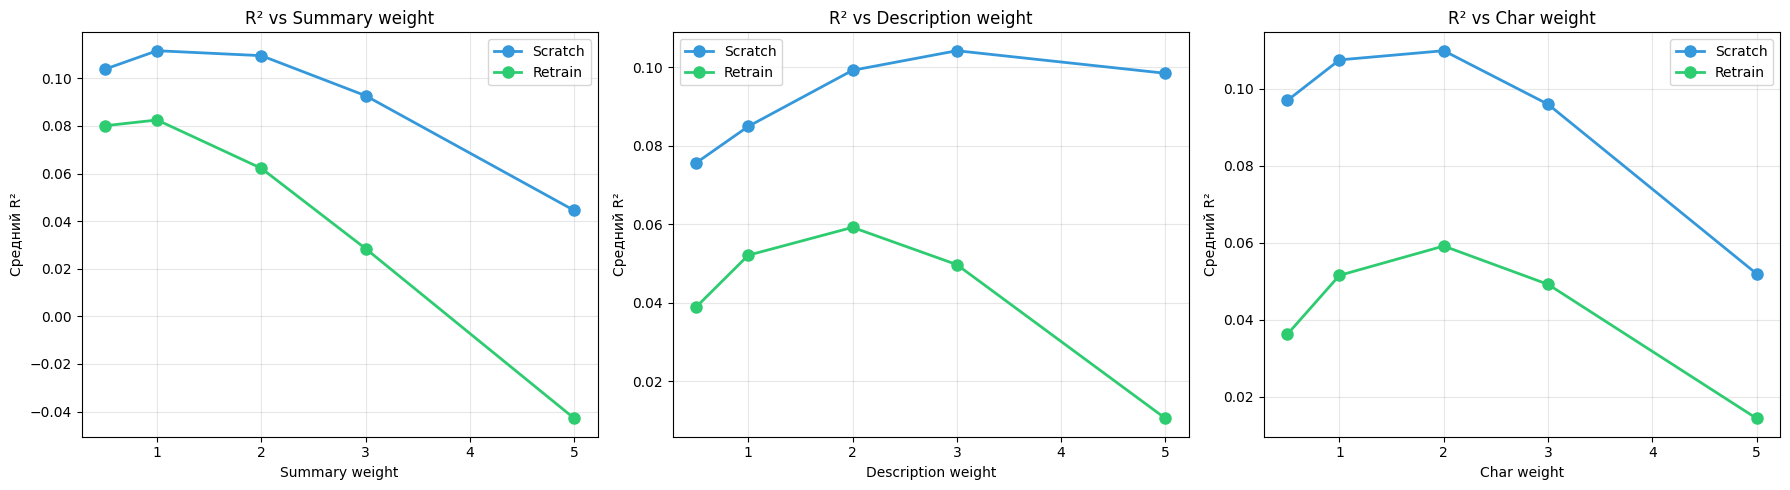

In [33]:
# ============================================================
# СВОДКИ
# ============================================================

wt_df["combo"] = "s" + wt_df["ws"].astype(str) + "_d" + wt_df["wd"].astype(str) + "_c" + wt_df["wc"].astype(str)

# Средний R² — топ-10 комбинаций
print("\n" + "="*80)
print("ТОП-10 КОМБИНАЦИЙ ВЕСОВ ПО СРЕДНЕМУ R²")
print("="*80)

for mdl in ["Scratch", "Retrain"]:
    print(f"\n--- {mdl} ---")
    top = wt_df[wt_df["model"] == mdl].groupby(["ws", "wd", "wc"]).agg({
        "R2": "mean", "MdAPE": "mean"
    }).round(4).sort_values("R2", ascending=False).head(10)
    print(top.to_string())

# ============================================================
# Влияние каждого веса отдельно
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, param, label in zip(axes, ["ws", "wd", "wc"],
                              ["Summary weight", "Description weight", "Char weight"]):
    for mdl, color in [("Scratch", "#3498db"), ("Retrain", "#2ecc71")]:
        means = wt_df[wt_df["model"] == mdl].groupby(param)["R2"].mean()
        ax.plot(means.index, means.values, "o-", label=mdl, color=color, linewidth=2, markersize=8)
    
    ax.set_xlabel(label)
    ax.set_ylabel("Средний R²")
    ax.set_title(f"R² vs {label}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
print(f"\n{'='*145}")
print("ЛУЧШИЕ ВЕСА ПО КАЖДОМУ ПРОЕКТУ (R2)")
print(f"{'='*145}")
print(f"{'':15} | {'Scratch':^56} | {'Retrain':^56}")
print(f"{'Проект':<15} | {'--- best ---':^27}  {'--- 1 1 1 ---':^27} | {'--- best ---':^27}  {'--- 1 1 1 ---':^27}")
print(f"{'':15} | {'ws  wd  wc':>8} {'R²':>8} {'MedAE':>6} {'MdAPE':>6}  {'R²':>7} {'MedAE':>6} {'MdAPE':>6} | {'ws  wd  wc':>8} {'R²':>8} {'MedAE':>6} {'MdAPE':>6}  {'R²':>7} {'MedAE':>6} {'MdAPE':>6}")
print("-"*145)

for proj in projects:
    print(f"{proj:<15}", end="")
    for mdl in ["Scratch", "Retrain"]:
        proj_mdl = wt_df[(wt_df["project"] == proj) & (wt_df["model"] == mdl)]
        best = proj_mdl.loc[proj_mdl["R2"].idxmax()]
        base = proj_mdl[(proj_mdl["ws"] == 1.0) & (proj_mdl["wd"] == 1.0) & (proj_mdl["wc"] == 1.0)].iloc[0]
        
        w_str = f"{best['ws']:.1f} {best['wd']:.1f} {best['wc']:.1f}"
        b_mape = f"{best['MdAPE']:>5.1f}%" if not np.isnan(best['MdAPE']) else "   N/A"
        base_mape = f"{base['MdAPE']:>5.1f}%" if not np.isnan(base['MdAPE']) else "   N/A"
        
        print(f" | {w_str:>8} {best['R2']:>7.4f} {best['MedAE']:>5.2f}ч {b_mape}"
              f"  {base['R2']:>7.4f} {base['MedAE']:>5.2f}ч {base_mape}", end="")
    print()

print(f"\n{'='*145}")
print("ЛУЧШИЕ ВЕСА ПО КАЖДОМУ ПРОЕКТУ (MedAE)")
print(f"{'='*145}")
print(f"{'':15} | {'Scratch':^56} | {'Retrain':^56}")
print(f"{'Проект':<15} | {'--- best ---':^27}  {'--- 1 1 1 ---':^27} | {'--- best ---':^27}  {'--- 1 1 1 ---':^27}")
print(f"{'':15} | {'ws  wd  wc':>8} {'R²':>8} {'MedAE':>6} {'MdAPE':>6}  {'R²':>7} {'MedAE':>6} {'MdAPE':>6} | {'ws  wd  wc':>8} {'R²':>8} {'MedAE':>6} {'MdAPE':>6}  {'R²':>7} {'MedAE':>6} {'MdAPE':>6}")
print("-"*145)

for proj in projects:
    print(f"{proj:<15}", end="")
    for mdl in ["Scratch", "Retrain"]:
        proj_mdl = wt_df[(wt_df["project"] == proj) & (wt_df["model"] == mdl)]
        best = proj_mdl.loc[proj_mdl["MedAE"].idxmin()]
        base = proj_mdl[(proj_mdl["ws"] == 1.0) & (proj_mdl["wd"] == 1.0) & (proj_mdl["wc"] == 1.0)].iloc[0]
        
        w_str = f"{best['ws']:.1f} {best['wd']:.1f} {best['wc']:.1f}"
        b_mape = f"{best['MdAPE']:>5.1f}%" if not np.isnan(best['MdAPE']) else "   N/A"
        base_mape = f"{base['MdAPE']:>5.1f}%" if not np.isnan(base['MdAPE']) else "   N/A"
        
        print(f" | {w_str:>8} {best['R2']:>7.4f} {best['MedAE']:>5.2f}ч {b_mape}"
              f"  {base['R2']:>7.4f} {base['MedAE']:>5.2f}ч {base_mape}", end="")
    print()

print(f"\n{'='*145}")
print("ЛУЧШИЕ ВЕСА ПО КАЖДОМУ ПРОЕКТУ (MdAPE)")
print(f"{'='*145}")
print(f"{'':15} | {'Scratch':^56} | {'Retrain':^56}")
print(f"{'Проект':<15} | {'--- best ---':^27}  {'--- 1 1 1 ---':^27} | {'--- best ---':^27}  {'--- 1 1 1 ---':^27}")
print(f"{'':15} | {'ws  wd  wc':>8} {'R²':>8} {'MedAE':>6} {'MdAPE':>6}  {'R²':>7} {'MedAE':>6} {'MdAPE':>6} | {'ws  wd  wc':>8} {'R²':>8} {'MedAE':>6} {'MdAPE':>6}  {'R²':>7} {'MedAE':>6} {'MdAPE':>6}")
print("-"*145)

for proj in projects:
    print(f"{proj:<15}", end="")
    for mdl in ["Scratch", "Retrain"]:
        proj_mdl = wt_df[(wt_df["project"] == proj) & (wt_df["model"] == mdl)]
        best = proj_mdl.loc[proj_mdl["MdAPE"].idxmin()]
        base = proj_mdl[(proj_mdl["ws"] == 1.0) & (proj_mdl["wd"] == 1.0) & (proj_mdl["wc"] == 1.0)].iloc[0]
        
        w_str = f"{best['ws']:.1f} {best['wd']:.1f} {best['wc']:.1f}"
        b_mape = f"{best['MdAPE']:>5.1f}%" if not np.isnan(best['MdAPE']) else "   N/A"
        base_mape = f"{base['MdAPE']:>5.1f}%" if not np.isnan(base['MdAPE']) else "   N/A"
        
        print(f" | {w_str:>8} {best['R2']:>7.4f} {best['MedAE']:>5.2f}ч {b_mape}"
              f"  {base['R2']:>7.4f} {base['MedAE']:>5.2f}ч {base_mape}", end="")
    print()


# Сравнение средних
print(f"\n\n{'='*80}")
print("СРЕДНЕЕ: лучшие веса vs 1 1 1")
print(f"{'='*80}")

for mdl in ["Scratch", "Retrain"]:
    baseline = wt_df[(wt_df["model"] == mdl) & 
                      (wt_df["ws"] == 1.0) & (wt_df["wd"] == 1.0) & (wt_df["wc"] == 1.0)]
    base_r2 = baseline["R2"].mean()
    base_mape = baseline["MdAPE"].mean()
    base_med = baseline["MedAE"].mean()
    
    best_per_proj = wt_df[wt_df["model"] == mdl].loc[
        wt_df[wt_df["model"] == mdl].groupby("project")["R2"].idxmax()
    ]
    best_r2 = best_per_proj["R2"].mean()
    best_mape = best_per_proj["MdAPE"].mean()
    best_med = best_per_proj["MedAE"].mean()
    
    print(f"\n{mdl}:")
    print(f"  1 1 1:         R²={base_r2:.4f}  MedAE={base_med:.2f}ч  MdAPE={base_mape:.1f}%")
    print(f"  Best per proj: R²={best_r2:.4f}  MedAE={best_med:.2f}ч  MdAPE={best_mape:.1f}%")
    print(f"  Прирост R²:    +{best_r2 - base_r2:.4f}")


ЛУЧШИЕ ВЕСА ПО КАЖДОМУ ПРОЕКТУ (R2)
                |                         Scratch                          |                         Retrain                         
Проект          |        --- best ---                 --- 1 1 1 ---        |        --- best ---                 --- 1 1 1 ---       
                | ws  wd  wc       R²  MedAE  MdAPE       R²  MedAE  MdAPE | ws  wd  wc       R²  MedAE  MdAPE       R²  MedAE  MdAPE
-------------------------------------------------------------------------------------------------------------------------------------------------
Sonatype        | 1.0 2.0 2.0  0.2088  0.74ч  55.5%   0.2035  0.81ч  56.1% | 1.0 1.0 1.0  0.2044  0.81ч  57.9%   0.2044  0.81ч  57.9%
SecondLife      | 0.5 0.5 1.0  0.1134  2.63ч  75.2%   0.0985  2.90ч  75.9% | 0.5 1.0 1.0  0.0556  2.52ч  78.4%   0.0476  2.70ч  79.0%
RedHat          | 0.5 2.0 1.0  0.1813  2.45ч  72.0%   0.1639  2.52ч  72.9% | 0.5 2.0 2.0  0.1865  2.15ч  68.0%   0.1660  2.20ч  69.9%
Spring       

## Кривые обучения

Данные: 17379
source_collection
Jira             5041
Apache           5041
Spring           1858
RedHat           1826
Sonatype         1659
Sakai             574
JiraEcosystem     555
SecondLife        522
Qt                153
Hyperledger       150
Name: count, dtype: int64
✅ Sonatype (finetune=1327, test=332)
✅ SecondLife (finetune=417, test=105)
✅ RedHat (finetune=1460, test=366)
✅ Spring (finetune=1486, test=372)
✅ Qt (finetune=122, test=31)
✅ Sakai (finetune=459, test=115)
✅ Jira (finetune=4032, test=1009)
✅ JiraEcosystem (finetune=444, test=111)
✅ Hyperledger (finetune=120, test=30)
✅ Apache (finetune=4032, test=1009)


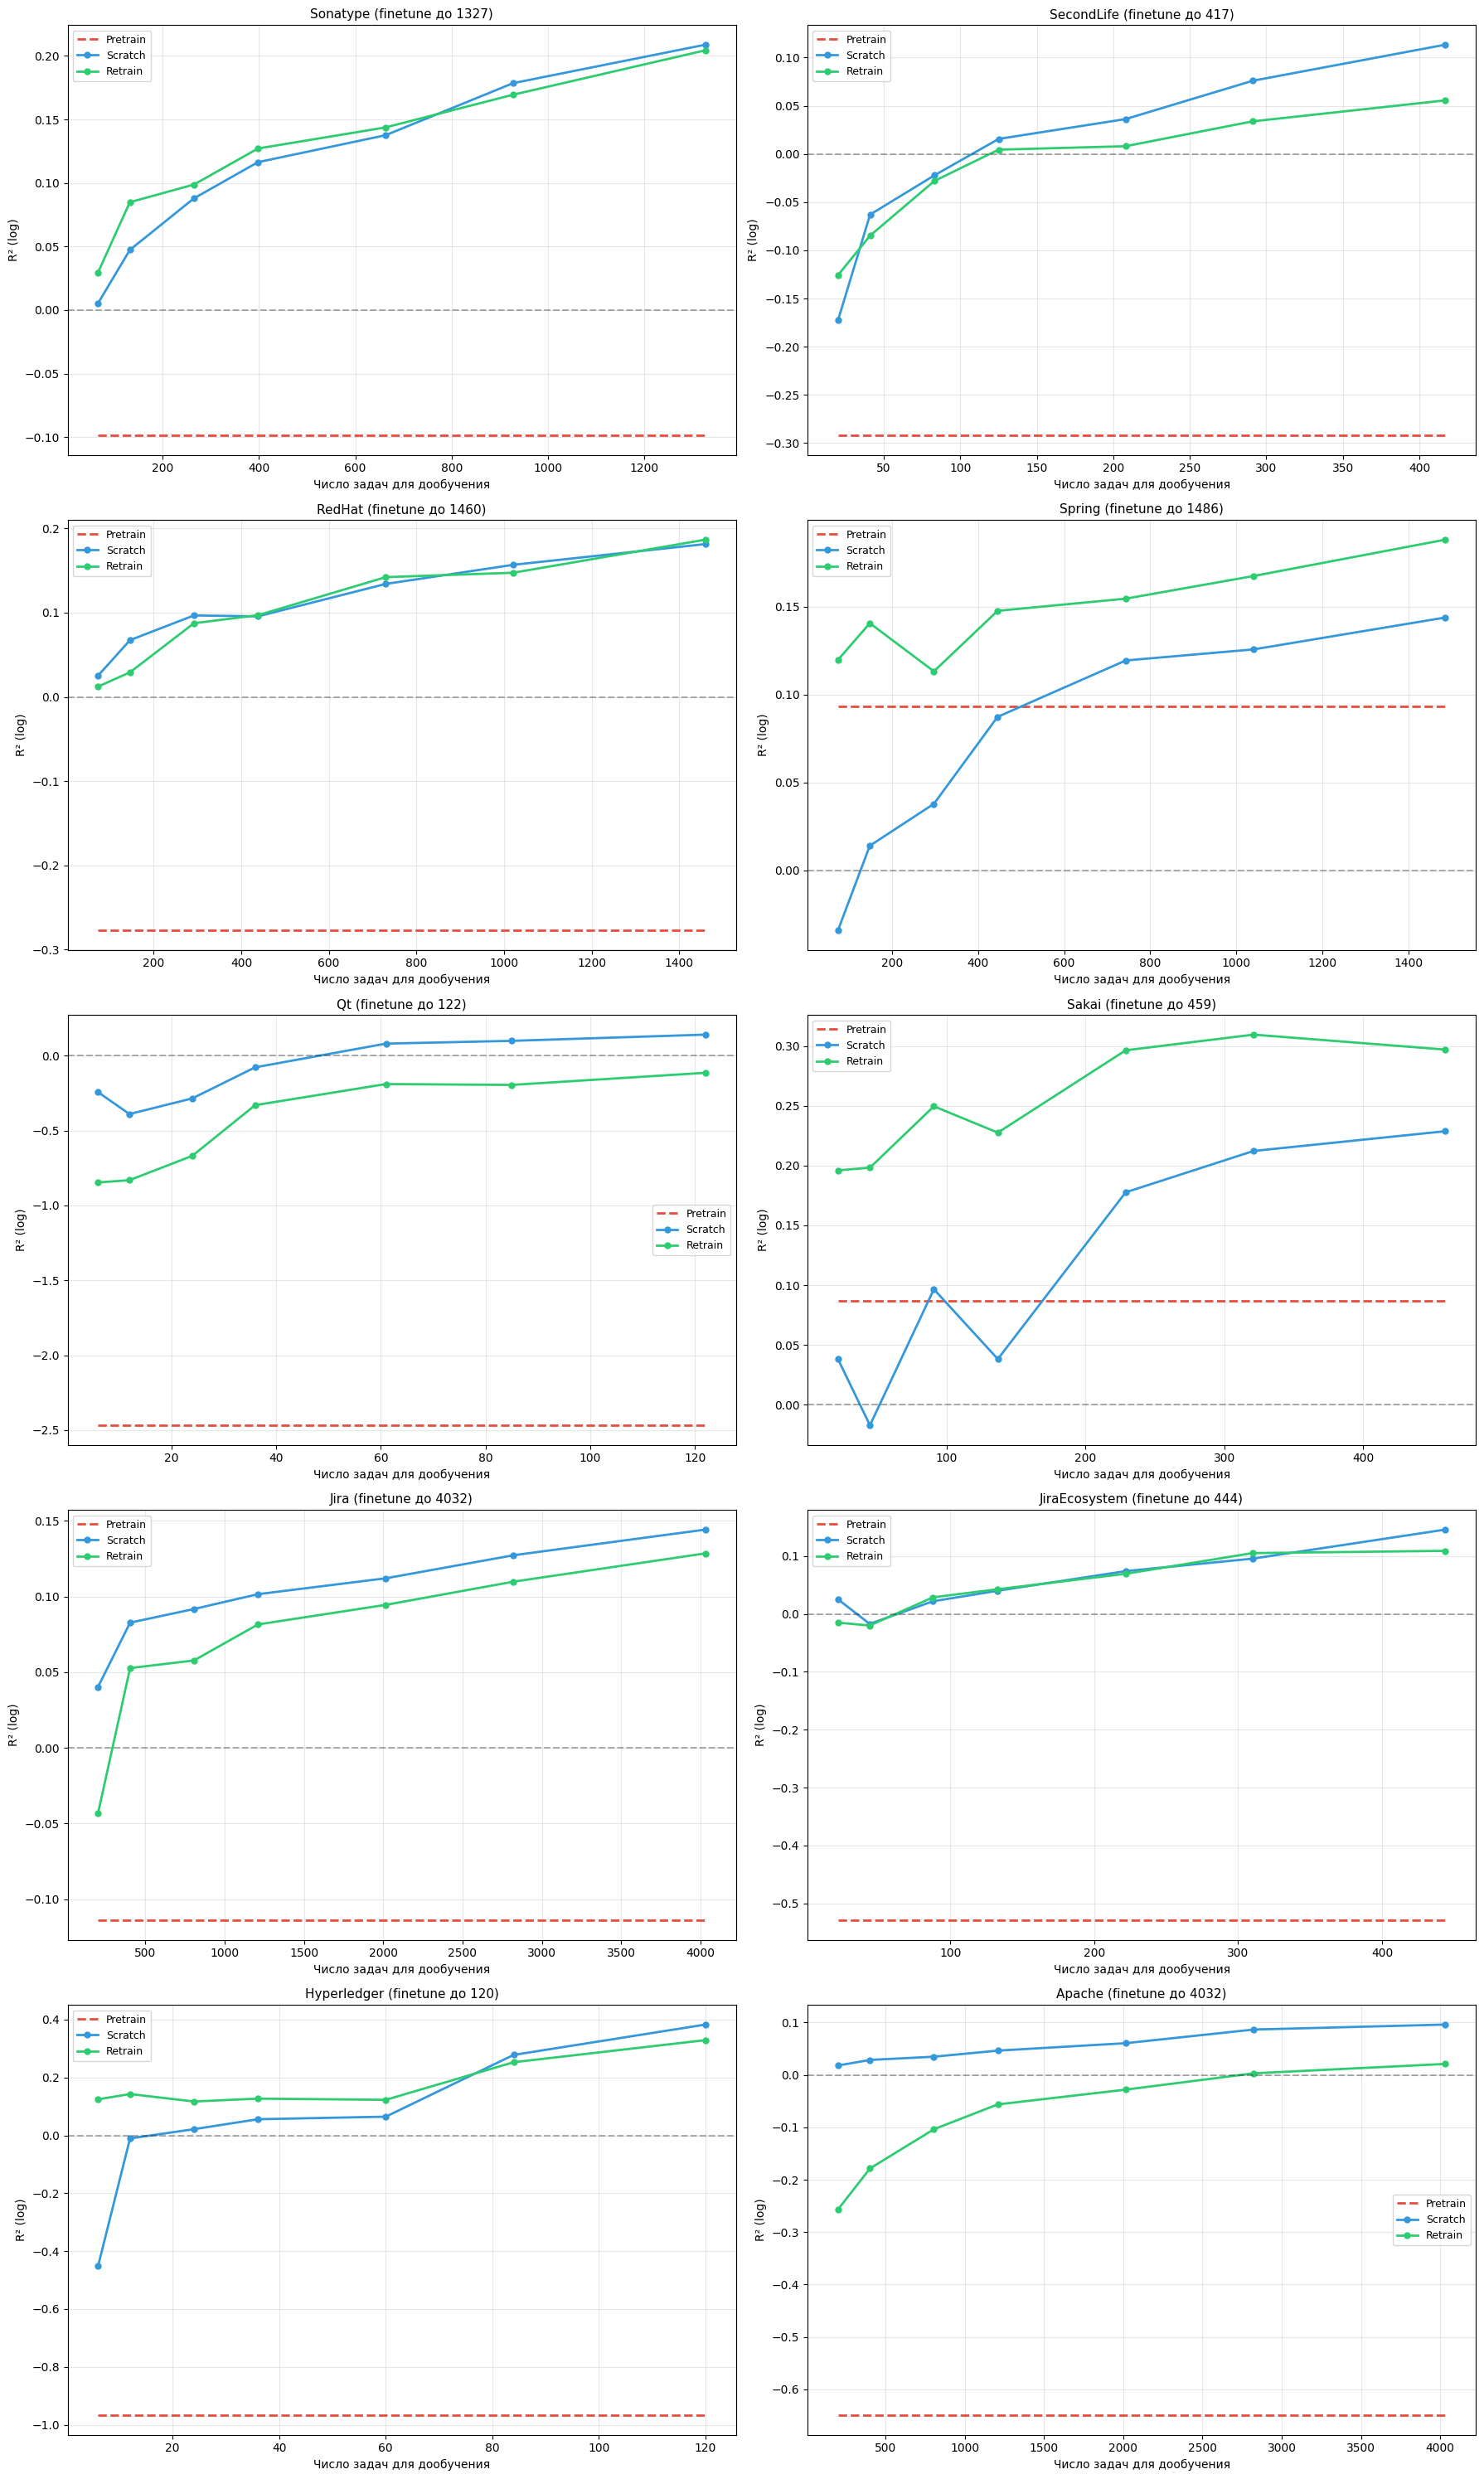

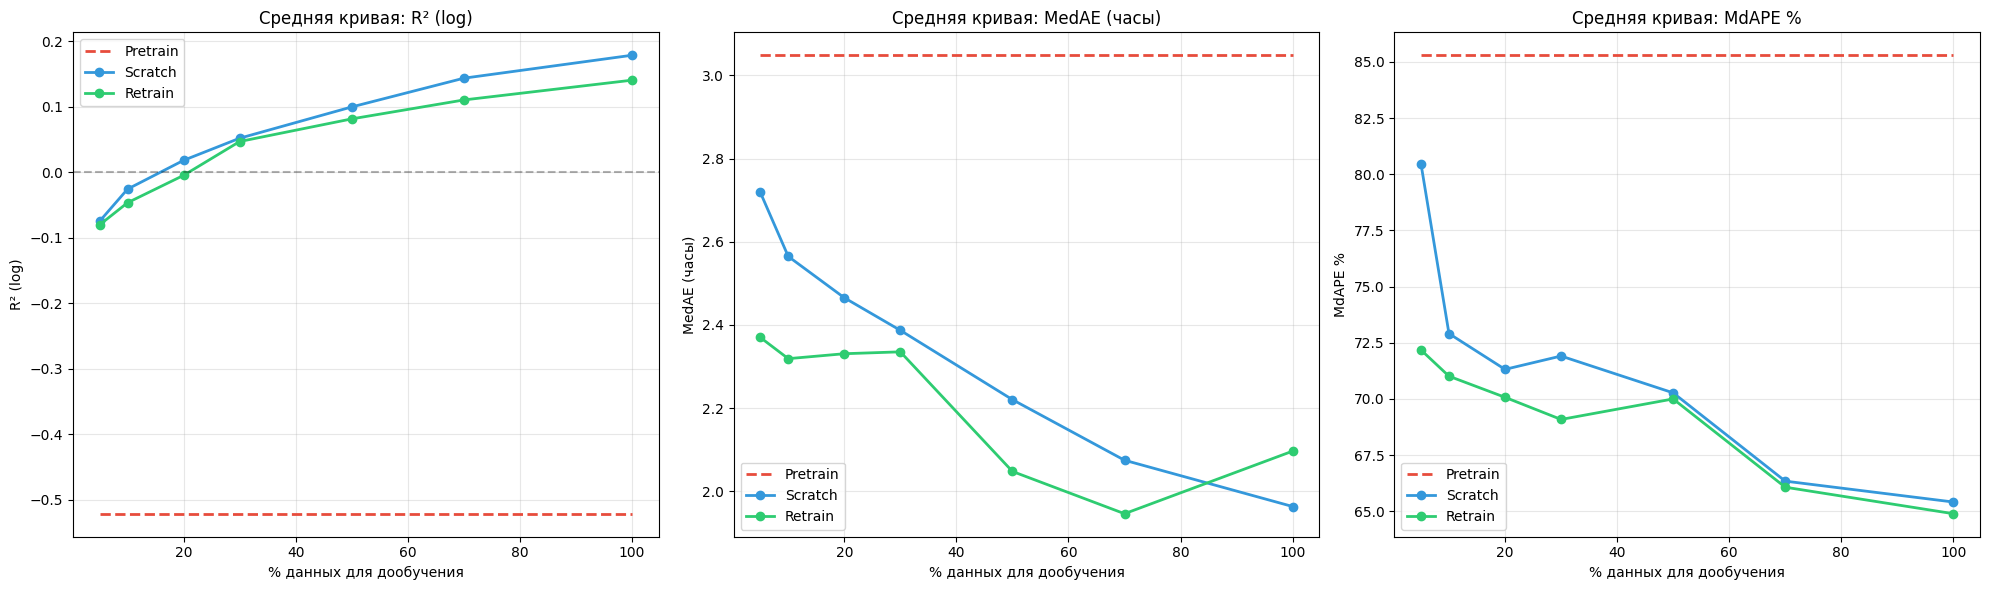


СРЕДНИЕ МЕТРИКИ ПО ФРАКЦИЯМ

--- Pretrain ---
       avg_n      R2  MedAE_h   MdAPE%
frac                                  
0.05    69.1 -0.5214   3.0484  85.2992
0.10   138.6 -0.5214   3.0484  85.2992
0.20   277.6 -0.5214   3.0484  85.2992
0.30   416.6 -0.5214   3.0484  85.2992
0.50   694.8 -0.5214   3.0484  85.2992
0.70   972.4 -0.5214   3.0484  85.2992
1.00  1389.9 -0.5214   3.0484  85.2992

--- Scratch ---
       avg_n      R2  MedAE_h   MdAPE%
frac                                  
0.05    69.1 -0.0751   2.7193  80.4760
0.10   138.6 -0.0258   2.5648  72.9072
0.20   277.6  0.0181   2.4655  71.3132
0.30   416.6  0.0518   2.3872  71.9071
0.50   694.8  0.0996   2.2206  70.2682
0.70   972.4  0.1435   2.0749  66.3366
1.00  1389.9  0.1785   1.9636  65.4068

--- Retrain ---
       avg_n      R2  MedAE_h   MdAPE%
frac                                  
0.05    69.1 -0.0805   2.3702  72.1790
0.10   138.6 -0.0466   2.3191  71.0094
0.20   277.6 -0.0049   2.3310  70.0695
0.30   416.6  0.0468  

In [3]:
import pymongo
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.sparse import hstack, vstack
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 1. Загрузка и подготовка данных
# ============================================================

client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["JiraRepos"]
collection = db["Merged"]

cursor = collection.find({}, {
    "_id": 1, "summary": 1, "description": 1,
    "timespent": 1, "source_collection": 1
})
df = pd.DataFrame(list(cursor))

df["description"] = df["description"].fillna("")
df["text"] = df["summary"] + " " + df["description"]
df = df[df["timespent"] > 0].copy()
hours = df["timespent"] / 3600
df = df[(df["timespent"] >= 60) & (hours <= 100)].copy()
df["log_timespent"] = np.log1p(df["timespent"])

max_non_apache = df[df["source_collection"] != "Apache"]["source_collection"].value_counts().max()
df_apache = df[df["source_collection"] == "Apache"].sample(n=max_non_apache, random_state=42)
df_other = df[df["source_collection"] != "Apache"]
df_balanced = pd.concat([df_other, df_apache]).reset_index(drop=True)

projects = df_balanced["source_collection"].unique()
print(f"Данные: {len(df_balanced)}")
print(df_balanced["source_collection"].value_counts())

# ============================================================
# 2. Лучшие параметры из предыдущих экспериментов
# ============================================================

best_project_params = {
    "Sonatype": {
        "Scratch": {"alpha": 5.0,  "ws": 1.0, "wd": 2.0, "wc": 2.0},
        "Retrain": {"alpha": 50.0, "ws": 1.0, "wd": 1.0, "wc": 1.0},
    },
    "SecondLife": {
        "Scratch": {"alpha": 0.5,  "ws": 0.5, "wd": 0.5, "wc": 1.0},
        "Retrain": {"alpha": 50.0, "ws": 0.5, "wd": 1.0, "wc": 1.0},
    },
    "RedHat": {
        "Scratch": {"alpha": 5.0,  "ws": 0.5, "wd": 2.0, "wc": 1.0},
        "Retrain": {"alpha": 50.0, "ws": 0.5, "wd": 2.0, "wc": 2.0},
    },
    "Spring": {
        "Scratch": {"alpha": 5.0,  "ws": 2.0, "wd": 2.0, "wc": 0.5},
        "Retrain": {"alpha": 50.0, "ws": 2.0, "wd": 2.0, "wc": 0.5},
    },
    "Qt": {
        "Scratch": {"alpha": 1.0,  "ws": 1.0, "wd": 5.0, "wc": 0.5},
        "Retrain": {"alpha": 5.0,  "ws": 0.5, "wd": 1.0, "wc": 2.0},
    },
    "Sakai": {
        "Scratch": {"alpha": 1.0,  "ws": 1.0, "wd": 1.0, "wc": 0.5},
        "Retrain": {"alpha": 10.0, "ws": 1.0, "wd": 1.0, "wc": 0.5},
    },
    "Jira": {
        "Scratch": {"alpha": 10.0, "ws": 1.0, "wd": 2.0, "wc": 1.0},
        "Retrain": {"alpha": 10.0, "ws": 0.5, "wd": 1.0, "wc": 1.0},
    },
    "JiraEcosystem": {
        "Scratch": {"alpha": 1.0,  "ws": 2.0, "wd": 5.0, "wc": 2.0},
        "Retrain": {"alpha": 100.0,"ws": 0.5, "wd": 3.0, "wc": 1.0},
    },
    "Apache": {
        "Scratch": {"alpha": 10.0, "ws": 1.0, "wd": 0.5, "wc": 1.0},
        "Retrain": {"alpha": 50.0, "ws": 1.0, "wd": 0.5, "wc": 2.0},
    },
    "Hyperledger": {
        "Scratch": {"alpha": 0.1,  "ws": 2.0, "wd": 0.5, "wc": 5.0},
        "Retrain": {"alpha": 50.0, "ws": 0.5, "wd": 0.5, "wc": 2.0},
    },
}

# ============================================================
# 3. Кривые обучения
# ============================================================

fractions = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
lc_results = []

for target_project in projects:
    mask_target = df_balanced["source_collection"] == target_project
    df_pretrain_raw = df_balanced[~mask_target]
    df_target_raw = df_balanced[mask_target]
    
    df_finetune_raw, df_test_raw = train_test_split(
        df_target_raw, test_size=0.2, random_state=42
    )
    
    n_ft_total = len(df_finetune_raw)
    
    # TF-IDF — один раз на pretrain
    tfidf_sum = TfidfVectorizer(
        max_features=15000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    s_pre = tfidf_sum.fit_transform(df_pretrain_raw["summary"].fillna(""))
    s_ft_full = tfidf_sum.transform(df_finetune_raw["summary"].fillna(""))
    s_te = tfidf_sum.transform(df_test_raw["summary"].fillna(""))
    
    tfidf_desc = TfidfVectorizer(
        max_features=35000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    d_pre = tfidf_desc.fit_transform(df_pretrain_raw["description"].fillna(""))
    d_ft_full = tfidf_desc.transform(df_finetune_raw["description"].fillna(""))
    d_te = tfidf_desc.transform(df_test_raw["description"].fillna(""))
    
    tfidf_char = TfidfVectorizer(
        max_features=20000, analyzer="char_wb",
        ngram_range=(3, 5), min_df=3, max_df=0.95, sublinear_tf=True
    )
    c_pre = tfidf_char.fit_transform(df_pretrain_raw["text"])
    c_ft_full = tfidf_char.transform(df_finetune_raw["text"])
    c_te = tfidf_char.transform(df_test_raw["text"])
    
    y_pre = df_pretrain_raw["log_timespent"].values
    y_ft_full = df_finetune_raw["log_timespent"].values
    y_te = df_test_raw["log_timespent"].values
    y_te_sec = np.expm1(y_te)
    
    params = best_project_params[target_project]
    
    def calc_metrics(y_pred_log):
        r2 = r2_score(y_te, y_pred_log)
        yp = np.expm1(y_pred_log)
        med = np.median(np.abs(y_te_sec - yp)) / 3600
        mask = y_te_sec > 600
        mape = np.median(np.abs(y_te_sec[mask] - yp[mask]) / y_te_sec[mask]) * 100 if mask.sum() > 5 else np.nan
        return r2, med, mape
    
    def apply_weights(s, d, c, ws, wd, wc):
        return hstack([s * ws, d * wd, c * wc])
    
    # Pretrain — не зависит от количества finetune данных
    p = params["Scratch"]  # веса не так важны для pretrain, берём от scratch
    X_pre_w = apply_weights(s_pre, d_pre, c_pre, p["ws"], p["wd"], p["wc"])
    X_te_w = apply_weights(s_te, d_te, c_te, p["ws"], p["wd"], p["wc"])
    m = Ridge(alpha=p["alpha"]).fit(X_pre_w, y_pre)
    r2_pretrain, med_pretrain, mape_pretrain = calc_metrics(m.predict(X_te_w))
    
    for frac in fractions:
        n_ft = max(int(n_ft_total * frac), 5)
        
        idx = np.random.RandomState(42).choice(n_ft_total, size=n_ft, replace=False)
        
        s_ft = s_ft_full[idx]
        d_ft = d_ft_full[idx]
        c_ft = c_ft_full[idx]
        y_ft = y_ft_full[idx]
        
        # Pretrain (постоянная линия)
        lc_results.append({
            "project": target_project, "model": "Pretrain",
            "frac": frac, "n_ft": n_ft,
            "R2": r2_pretrain, "MedAE": med_pretrain, "MdAPE": mape_pretrain
        })
        
        # Scratch
        p_s = params["Scratch"]
        X_ft_w = apply_weights(s_ft, d_ft, c_ft, p_s["ws"], p_s["wd"], p_s["wc"])
        X_te_w = apply_weights(s_te, d_te, c_te, p_s["ws"], p_s["wd"], p_s["wc"])
        m = Ridge(alpha=p_s["alpha"]).fit(X_ft_w, y_ft)
        r2, med, mape = calc_metrics(m.predict(X_te_w))
        lc_results.append({
            "project": target_project, "model": "Scratch",
            "frac": frac, "n_ft": n_ft,
            "R2": r2, "MedAE": med, "MdAPE": mape
        })
        
        # Retrain
        p_r = params["Retrain"]
        X_pre_w = apply_weights(s_pre, d_pre, c_pre, p_r["ws"], p_r["wd"], p_r["wc"])
        X_ft_w = apply_weights(s_ft, d_ft, c_ft, p_r["ws"], p_r["wd"], p_r["wc"])
        X_te_w = apply_weights(s_te, d_te, c_te, p_r["ws"], p_r["wd"], p_r["wc"])
        
        w_sample = len(y_pre) / len(y_ft)
        X_c = vstack([X_pre_w, X_ft_w])
        y_c = np.concatenate([y_pre, y_ft])
        wts = np.concatenate([np.ones(len(y_pre)), np.ones(len(y_ft)) * w_sample])
        m = Ridge(alpha=p_r["alpha"]).fit(X_c, y_c, sample_weight=wts)
        r2, med, mape = calc_metrics(m.predict(X_te_w))
        lc_results.append({
            "project": target_project, "model": "Retrain",
            "frac": frac, "n_ft": n_ft,
            "R2": r2, "MedAE": med, "MdAPE": mape
        })
    
    print(f"✅ {target_project} (finetune={n_ft_total}, test={len(df_test_raw)})")

lc_df = pd.DataFrame(lc_results)

# ============================================================
# 4. Графики — кривая обучения по каждому проекту
# ============================================================

colors = {"Pretrain": "#e74c3c", "Scratch": "#3498db", "Retrain": "#2ecc71"}

fig, axes = plt.subplots(5, 2, figsize=(18, 30))
axes = axes.flatten()

for idx, proj in enumerate(projects):
    ax = axes[idx]
    proj_data = lc_df[lc_df["project"] == proj]
    
    for mdl in ["Pretrain", "Scratch", "Retrain"]:
        mdl_data = proj_data[proj_data["model"] == mdl].sort_values("n_ft")
        style = "--" if mdl == "Pretrain" else "o-"
        ax.plot(mdl_data["n_ft"], mdl_data["R2"], style,
                label=mdl, color=colors[mdl], linewidth=2, markersize=5)
    
    n_total = proj_data["n_ft"].max()
    ax.set_title(f"{proj} (finetune до {n_total})", fontsize=11)
    ax.set_xlabel("Число задач для дообучения")
    ax.set_ylabel("R² (log)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 5. Средняя кривая обучения по всем проектам
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label in zip(axes, ["R2", "MedAE", "MdAPE"],
                                    ["R² (log)", "MedAE (часы)", "MdAPE %"]):
    for mdl in ["Pretrain", "Scratch", "Retrain"]:
        means = lc_df[lc_df["model"] == mdl].groupby("frac")[metric].mean()
        style = "--" if mdl == "Pretrain" else "o-"
        ax.plot(means.index * 100, means.values, style,
                label=mdl, color=colors[mdl], linewidth=2, markersize=6)
    
    ax.set_xlabel("% данных для дообучения")
    ax.set_ylabel(label)
    ax.set_title(f"Средняя кривая: {label}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    if metric == "R2":
        ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 6. Таблица: средние метрики по фракциям
# ============================================================

print("\n" + "="*80)
print("СРЕДНИЕ МЕТРИКИ ПО ФРАКЦИЯМ")
print("="*80)

for mdl in ["Pretrain", "Scratch", "Retrain"]:
    print(f"\n--- {mdl} ---")
    mdl_data = lc_df[lc_df["model"] == mdl]
    table = mdl_data.groupby("frac").agg({
        "n_ft": "mean", "R2": "mean", "MedAE": "mean", "MdAPE": "mean"
    }).round(4)
    table.columns = ["avg_n", "R2", "MedAE_h", "MdAPE%"]
    print(table.to_string())

✅ Sonatype (max finetune=1327, sizes=[5, 10, 25, 50, 100, 200, 500, 1000, 1327])
✅ SecondLife (max finetune=417, sizes=[5, 10, 25, 50, 100, 200, 417])
✅ RedHat (max finetune=1460, sizes=[5, 10, 25, 50, 100, 200, 500, 1000, 1460])
✅ Spring (max finetune=1486, sizes=[5, 10, 25, 50, 100, 200, 500, 1000, 1486])
✅ Qt (max finetune=122, sizes=[5, 10, 25, 50, 100, 122])
✅ Sakai (max finetune=459, sizes=[5, 10, 25, 50, 100, 200, 459])
✅ Jira (max finetune=4032, sizes=[5, 10, 25, 50, 100, 200, 500, 1000, 2000, 4000, 4032])
✅ JiraEcosystem (max finetune=444, sizes=[5, 10, 25, 50, 100, 200, 444])
✅ Hyperledger (max finetune=120, sizes=[5, 10, 25, 50, 100, 120])
✅ Apache (max finetune=4032, sizes=[5, 10, 25, 50, 100, 200, 500, 1000, 2000, 4000, 4032])


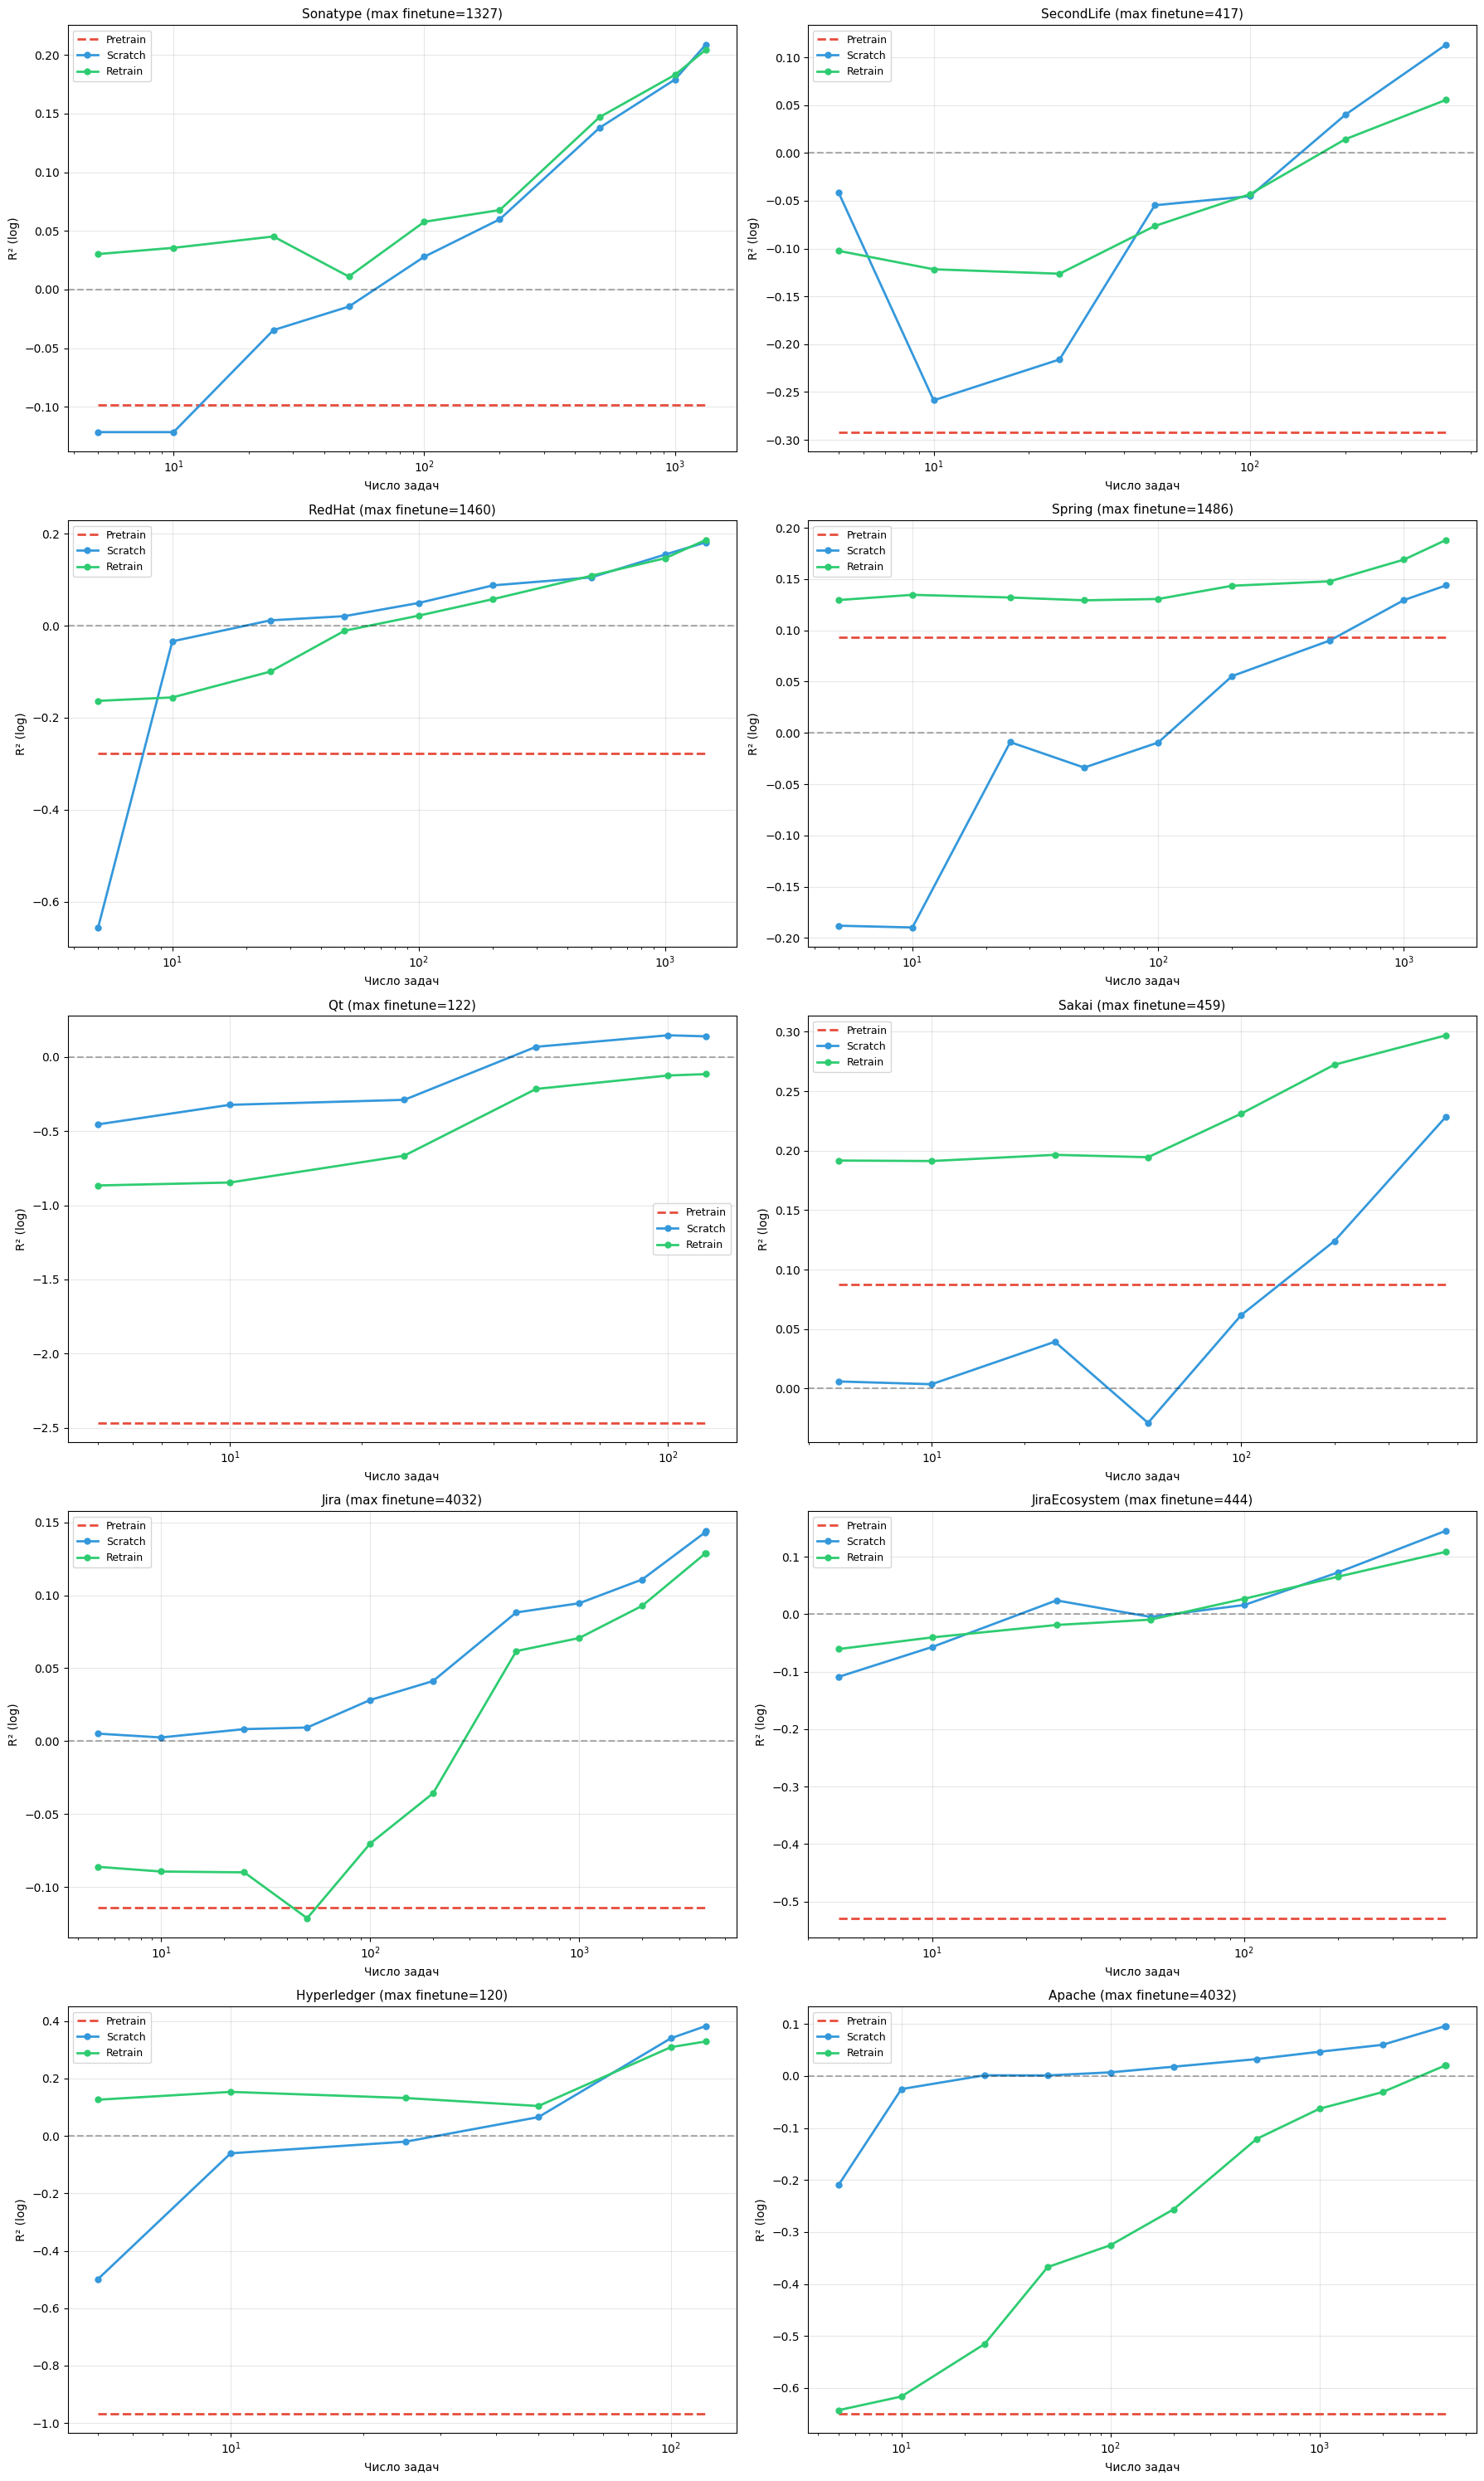

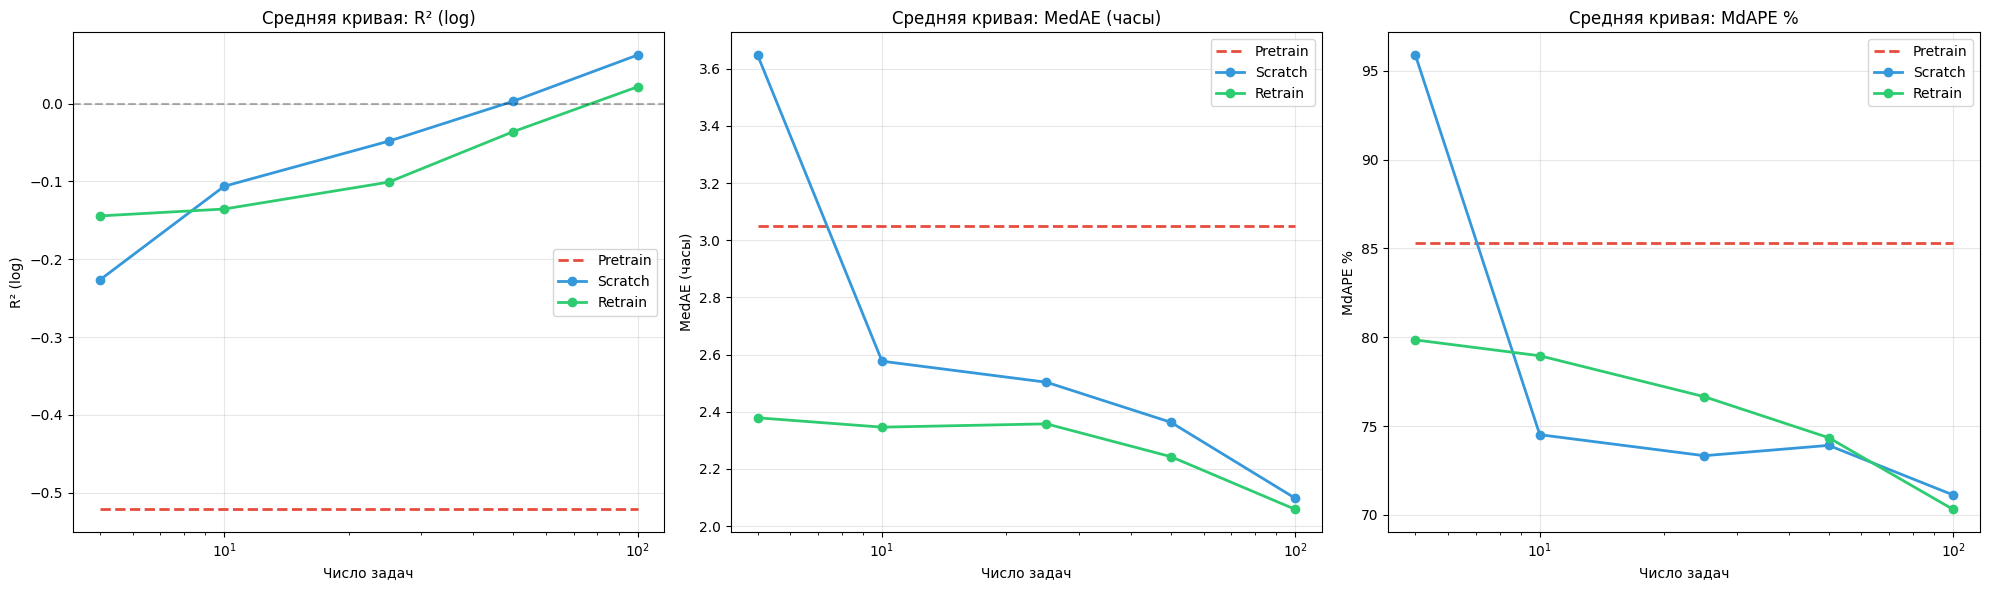


СРЕДНИЕ МЕТРИКИ ПО ЧИСЛУ ЗАДАЧ (общие размеры)

 n_tasks |      R²   MedAE   MdAPE  |      R²   MedAE   MdAPE  |      R²   MedAE   MdAPE  |
         |         Pretrain        |         Scratch         |         Retrain         |
------------------------------------------------------------------------------------------
       5 |  -0.5214   3.05ч   85.3%  |  -0.2266   3.65ч   95.9%  |  -0.1443   2.38ч   79.9%  |
      10 |  -0.5214   3.05ч   85.3%  |  -0.1062   2.58ч   74.5%  |  -0.1355   2.35ч   79.0%  |
      25 |  -0.5214   3.05ч   85.3%  |  -0.0483   2.50ч   73.3%  |  -0.1009   2.36ч   76.7%  |
      50 |  -0.5214   3.05ч   85.3%  |  0.0030   2.36ч   73.9%  |  -0.0361   2.24ч   74.3%  |
     100 |  -0.5214   3.05ч   85.3%  |  0.0623   2.10ч   71.1%  |  0.0215   2.06ч   70.3%  |


ТОЧКА ПЕРЕСЕЧЕНИЯ Retrain/Scratch:
  n=    5: Scratch R²=-0.2266  Retrain R²=-0.1443
  n=   10: Scratch R²=-0.1062  Retrain R²=-0.1355 ← Scratch обгоняет
  n=   25: Scratch R²=-0.0483  Retrain R²=-0.1009 ←

In [4]:
# ============================================================
# Кривая обучения по фиксированному числу задач
# ============================================================

fixed_sizes = [5, 10, 25, 50, 100, 200, 500, 1000, 2000, 4000]

lc_fixed_results = []

for target_project in projects:
    mask_target = df_balanced["source_collection"] == target_project
    df_pretrain_raw = df_balanced[~mask_target]
    df_target_raw = df_balanced[mask_target]
    
    df_finetune_raw, df_test_raw = train_test_split(
        df_target_raw, test_size=0.2, random_state=42
    )
    
    n_ft_total = len(df_finetune_raw)
    
    # TF-IDF
    tfidf_sum = TfidfVectorizer(
        max_features=15000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    s_pre = tfidf_sum.fit_transform(df_pretrain_raw["summary"].fillna(""))
    s_ft_full = tfidf_sum.transform(df_finetune_raw["summary"].fillna(""))
    s_te = tfidf_sum.transform(df_test_raw["summary"].fillna(""))
    
    tfidf_desc = TfidfVectorizer(
        max_features=35000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    d_pre = tfidf_desc.fit_transform(df_pretrain_raw["description"].fillna(""))
    d_ft_full = tfidf_desc.transform(df_finetune_raw["description"].fillna(""))
    d_te = tfidf_desc.transform(df_test_raw["description"].fillna(""))
    
    tfidf_char = TfidfVectorizer(
        max_features=20000, analyzer="char_wb",
        ngram_range=(3, 5), min_df=3, max_df=0.95, sublinear_tf=True
    )
    c_pre = tfidf_char.fit_transform(df_pretrain_raw["text"])
    c_ft_full = tfidf_char.transform(df_finetune_raw["text"])
    c_te = tfidf_char.transform(df_test_raw["text"])
    
    y_pre = df_pretrain_raw["log_timespent"].values
    y_ft_full = df_finetune_raw["log_timespent"].values
    y_te = df_test_raw["log_timespent"].values
    y_te_sec = np.expm1(y_te)
    
    params = best_project_params[target_project]
    
    def calc_metrics(y_pred_log):
        r2 = r2_score(y_te, y_pred_log)
        yp = np.expm1(y_pred_log)
        med = np.median(np.abs(y_te_sec - yp)) / 3600
        mask = y_te_sec > 600
        mape = np.median(np.abs(y_te_sec[mask] - yp[mask]) / y_te_sec[mask]) * 100 if mask.sum() > 5 else np.nan
        return r2, med, mape
    
    def apply_weights(s, d, c, ws, wd, wc):
        return hstack([s * ws, d * wd, c * wc])
    
    # Pretrain — один раз
    p_s = params["Scratch"]
    X_pre_w = apply_weights(s_pre, d_pre, c_pre, p_s["ws"], p_s["wd"], p_s["wc"])
    X_te_w_s = apply_weights(s_te, d_te, c_te, p_s["ws"], p_s["wd"], p_s["wc"])
    m = Ridge(alpha=p_s["alpha"]).fit(X_pre_w, y_pre)
    r2_pretrain, med_pretrain, mape_pretrain = calc_metrics(m.predict(X_te_w_s))
    
    # Фильтруем размеры, которые не больше доступных данных
    available_sizes = [n for n in fixed_sizes if n <= n_ft_total]
    if n_ft_total not in available_sizes:
        available_sizes.append(n_ft_total)
    
    for n_ft in available_sizes:
        idx = np.random.RandomState(42).choice(n_ft_total, size=n_ft, replace=False)
        
        s_ft = s_ft_full[idx]
        d_ft = d_ft_full[idx]
        c_ft = c_ft_full[idx]
        y_ft = y_ft_full[idx]
        
        # Pretrain
        lc_fixed_results.append({
            "project": target_project, "model": "Pretrain",
            "n_ft": n_ft,
            "R2": r2_pretrain, "MedAE": med_pretrain, "MdAPE": mape_pretrain
        })
        
        # Scratch
        p_s = params["Scratch"]
        X_ft_w = apply_weights(s_ft, d_ft, c_ft, p_s["ws"], p_s["wd"], p_s["wc"])
        X_te_w = apply_weights(s_te, d_te, c_te, p_s["ws"], p_s["wd"], p_s["wc"])
        m = Ridge(alpha=p_s["alpha"]).fit(X_ft_w, y_ft)
        r2, med, mape = calc_metrics(m.predict(X_te_w))
        lc_fixed_results.append({
            "project": target_project, "model": "Scratch",
            "n_ft": n_ft,
            "R2": r2, "MedAE": med, "MdAPE": mape
        })
        
        # Retrain
        p_r = params["Retrain"]
        X_pre_w = apply_weights(s_pre, d_pre, c_pre, p_r["ws"], p_r["wd"], p_r["wc"])
        X_ft_w = apply_weights(s_ft, d_ft, c_ft, p_r["ws"], p_r["wd"], p_r["wc"])
        X_te_w = apply_weights(s_te, d_te, c_te, p_r["ws"], p_r["wd"], p_r["wc"])
        
        w_sample = len(y_pre) / len(y_ft)
        X_c = vstack([X_pre_w, X_ft_w])
        y_c = np.concatenate([y_pre, y_ft])
        wts = np.concatenate([np.ones(len(y_pre)), np.ones(len(y_ft)) * w_sample])
        m = Ridge(alpha=p_r["alpha"]).fit(X_c, y_c, sample_weight=wts)
        r2, med, mape = calc_metrics(m.predict(X_te_w))
        lc_fixed_results.append({
            "project": target_project, "model": "Retrain",
            "n_ft": n_ft,
            "R2": r2, "MedAE": med, "MdAPE": mape
        })
    
    print(f"✅ {target_project} (max finetune={n_ft_total}, sizes={available_sizes})")

lc_fix = pd.DataFrame(lc_fixed_results)

# ============================================================
# Графики по каждому проекту
# ============================================================

colors = {"Pretrain": "#e74c3c", "Scratch": "#3498db", "Retrain": "#2ecc71"}

fig, axes = plt.subplots(5, 2, figsize=(18, 30))
axes = axes.flatten()

for idx, proj in enumerate(projects):
    ax = axes[idx]
    proj_data = lc_fix[lc_fix["project"] == proj]
    
    for mdl in ["Pretrain", "Scratch", "Retrain"]:
        mdl_data = proj_data[proj_data["model"] == mdl].sort_values("n_ft")
        style = "--" if mdl == "Pretrain" else "o-"
        ax.plot(mdl_data["n_ft"], mdl_data["R2"], style,
                label=mdl, color=colors[mdl], linewidth=2, markersize=5)
    
    n_total = proj_data["n_ft"].max()
    ax.set_title(f"{proj} (max finetune={n_total})", fontsize=11)
    ax.set_xlabel("Число задач")
    ax.set_ylabel("R² (log)")
    ax.set_xscale("log")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Средняя кривая (только по общим размерам)
# ============================================================

common_sizes = [n for n in fixed_sizes if n <= lc_fix.groupby("project")["n_ft"].max().min()]

lc_common = lc_fix[lc_fix["n_ft"].isin(common_sizes)]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label in zip(axes, ["R2", "MedAE", "MdAPE"],
                                    ["R² (log)", "MedAE (часы)", "MdAPE %"]):
    for mdl in ["Pretrain", "Scratch", "Retrain"]:
        mdl_data = lc_common[lc_common["model"] == mdl]
        means = mdl_data.groupby("n_ft")[metric].mean().sort_index()
        style = "--" if mdl == "Pretrain" else "o-"
        ax.plot(means.index, means.values, style,
                label=mdl, color=colors[mdl], linewidth=2, markersize=6)
    
    ax.set_xlabel("Число задач")
    ax.set_ylabel(label)
    ax.set_title(f"Средняя кривая: {label}")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
    if metric == "R2":
        ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Таблица: средние метрики по числу задач
# ============================================================

print("\n" + "="*90)
print("СРЕДНИЕ МЕТРИКИ ПО ЧИСЛУ ЗАДАЧ (общие размеры)")
print("="*90)

print(f"\n{'n_tasks':>8} |", end="")
for mdl in ["Pretrain", "Scratch", "Retrain"]:
    print(f"  {'R²':>6}  {'MedAE':>6}  {'MdAPE':>6}  |", end="")
print(f"\n{'':>8} |", end="")
for mdl in ["Pretrain", "Scratch", "Retrain"]:
    print(f"  {mdl:^22} |", end="")
print()
print("-"*90)

for n in common_sizes:
    print(f"{n:>8} |", end="")
    for mdl in ["Pretrain", "Scratch", "Retrain"]:
        d = lc_common[(lc_common["n_ft"] == n) & (lc_common["model"] == mdl)]
        r2 = d["R2"].mean()
        med = d["MedAE"].mean()
        mape = d["MdAPE"].mean()
        mape_str = f"{mape:>5.1f}%" if not np.isnan(mape) else "   N/A"
        print(f"  {r2:>6.4f}  {med:>5.2f}ч  {mape_str}  |", end="")
    print()

# Точка пересечения Retrain и Scratch
print("\n\nТОЧКА ПЕРЕСЕЧЕНИЯ Retrain/Scratch:")
for n in common_sizes:
    r_scratch = lc_common[(lc_common["n_ft"] == n) & (lc_common["model"] == "Scratch")]["R2"].mean()
    r_retrain = lc_common[(lc_common["n_ft"] == n) & (lc_common["model"] == "Retrain")]["R2"].mean()
    marker = " ← Scratch обгоняет" if r_scratch > r_retrain else ""
    print(f"  n={n:>5}: Scratch R²={r_scratch:.4f}  Retrain R²={r_retrain:.4f}{marker}")

## Перенос записей в SQLite

In [14]:
import pymongo
import sqlite3
import random

# ============================================================
# 1. Подключение к MongoDB
# ============================================================

mongo_client = pymongo.MongoClient("mongodb://localhost:27017/")
mongo_db = mongo_client["JiraRepos"]
collection = mongo_db["Merged"]

cursor = collection.find({}, {
    "_id": 1,
    "summary": 1,
    "description": 1,
    "timespent": 1,
    "source_collection": 1
})

tasks = list(cursor)
print(f"Загружено из MongoDB: {len(tasks)}")

# ============================================================
# 2. Фильтрация выбросов
# ============================================================

MIN_SECONDS = 60        # 1 минута
MAX_SECONDS = 360000    # 100 часов

before = len(tasks)
tasks = [t for t in tasks if t.get("timespent") is None 
         or (t["timespent"] >= MIN_SECONDS and t["timespent"] <= MAX_SECONDS)]
after = len(tasks)

print(f"\nФильтрация выбросов ({MIN_SECONDS}с - {MAX_SECONDS}с):")
print(f"  Было: {before}")
print(f"  Стало: {after}")
print(f"  Убрано: {before - after}")

# ============================================================
# 3. Балансировка Apache
# ============================================================

apache_tasks = [t for t in tasks if t.get("source_collection") == "Apache"]
other_tasks = [t for t in tasks if t.get("source_collection") != "Apache"]

from collections import Counter
project_counts = Counter(t.get("source_collection") for t in other_tasks)
max_non_apache = max(project_counts.values())
second_project = project_counts.most_common(1)[0]

print(f"\nApache задач: {len(apache_tasks)}")
print(f"Второй по размеру проект: {second_project[0]} ({second_project[1]} задач)")
print(f"Ограничиваем Apache до: {max_non_apache}")

random.seed(42)
apache_sampled = random.sample(apache_tasks, min(max_non_apache, len(apache_tasks)))

tasks_balanced = other_tasks + apache_sampled
print(f"Итого после балансировки: {len(tasks_balanced)}")

# ============================================================
# 4. Подключение к SQLite
# ============================================================

sqlite_conn = sqlite3.connect("../backend/data.db")
sqlite_cursor = sqlite_conn.cursor()

sqlite_cursor.execute("DROP TABLE IF EXISTS ml_source_tasks")

sqlite_cursor.execute("""
    CREATE TABLE ml_source_tasks (
        id TEXT PRIMARY KEY,
        source_project_name TEXT,
        summary TEXT,
        description TEXT,
        actual_spent_seconds REAL,
        dataset_version TEXT,
        completed_at TEXT
    )
""")

# ============================================================
# 5. Перенос данных
# ============================================================

rows = []
for task in tasks_balanced:
    rows.append((
        str(task.get("_id", "")),
        task.get("source_collection", ""),
        task.get("summary", ""),
        task.get("description", ""),
        task.get("timespent", None),
        "v1",
        None
    ))

sqlite_cursor.executemany("""
    INSERT INTO ml_source_tasks 
    (id, source_project_name, summary, description, actual_spent_seconds, dataset_version, completed_at)
    VALUES (?, ?, ?, ?, ?, ?, ?)
""", rows)

sqlite_conn.commit()

# ============================================================
# 6. Проверка
# ============================================================

sqlite_cursor.execute("SELECT COUNT(*) FROM ml_source_tasks")
count = sqlite_cursor.fetchone()[0]
print(f"\nЗаписано в SQLite: {count}")

sqlite_cursor.execute("""
    SELECT COUNT(*) FROM ml_source_tasks 
    WHERE actual_spent_seconds IS NOT NULL AND actual_spent_seconds > 0
""")
count_with_time = sqlite_cursor.fetchone()[0]
print(f"Из них с timespent > 0: {count_with_time}")

sqlite_cursor.execute("""
    SELECT source_project_name, COUNT(*), 
           SUM(CASE WHEN actual_spent_seconds > 0 THEN 1 ELSE 0 END) as with_time
    FROM ml_source_tasks 
    GROUP BY source_project_name 
    ORDER BY COUNT(*) DESC
""")
print(f"\n{'Проект':<20} {'Всего':>8} {'С временем':>10}")
print("-" * 40)
for row in sqlite_cursor.fetchall():
    print(f"  {row[0]:<20} {row[1]:>6} {row[2]:>8}")

sqlite_conn.close()
mongo_client.close()

print("\nГотово!")

Загружено из MongoDB: 79453

Фильтрация выбросов (60с - 360000с):
  Было: 79453
  Стало: 78519
  Убрано: 934

Apache задач: 66181
Второй по размеру проект: Jira (5041 задач)
Ограничиваем Apache до: 5041
Итого после балансировки: 17379

Записано в SQLite: 17379
Из них с timespent > 0: 17379

Проект                  Всего С временем
----------------------------------------
  Jira                   5041     5041
  Apache                 5041     5041
  Spring                 1858     1858
  RedHat                 1826     1826
  Sonatype               1659     1659
  Sakai                   574      574
  JiraEcosystem           555      555
  SecondLife              522      522
  Qt                      153      153
  Hyperledger             150      150

Готово!


### График распределения ошибок (2)

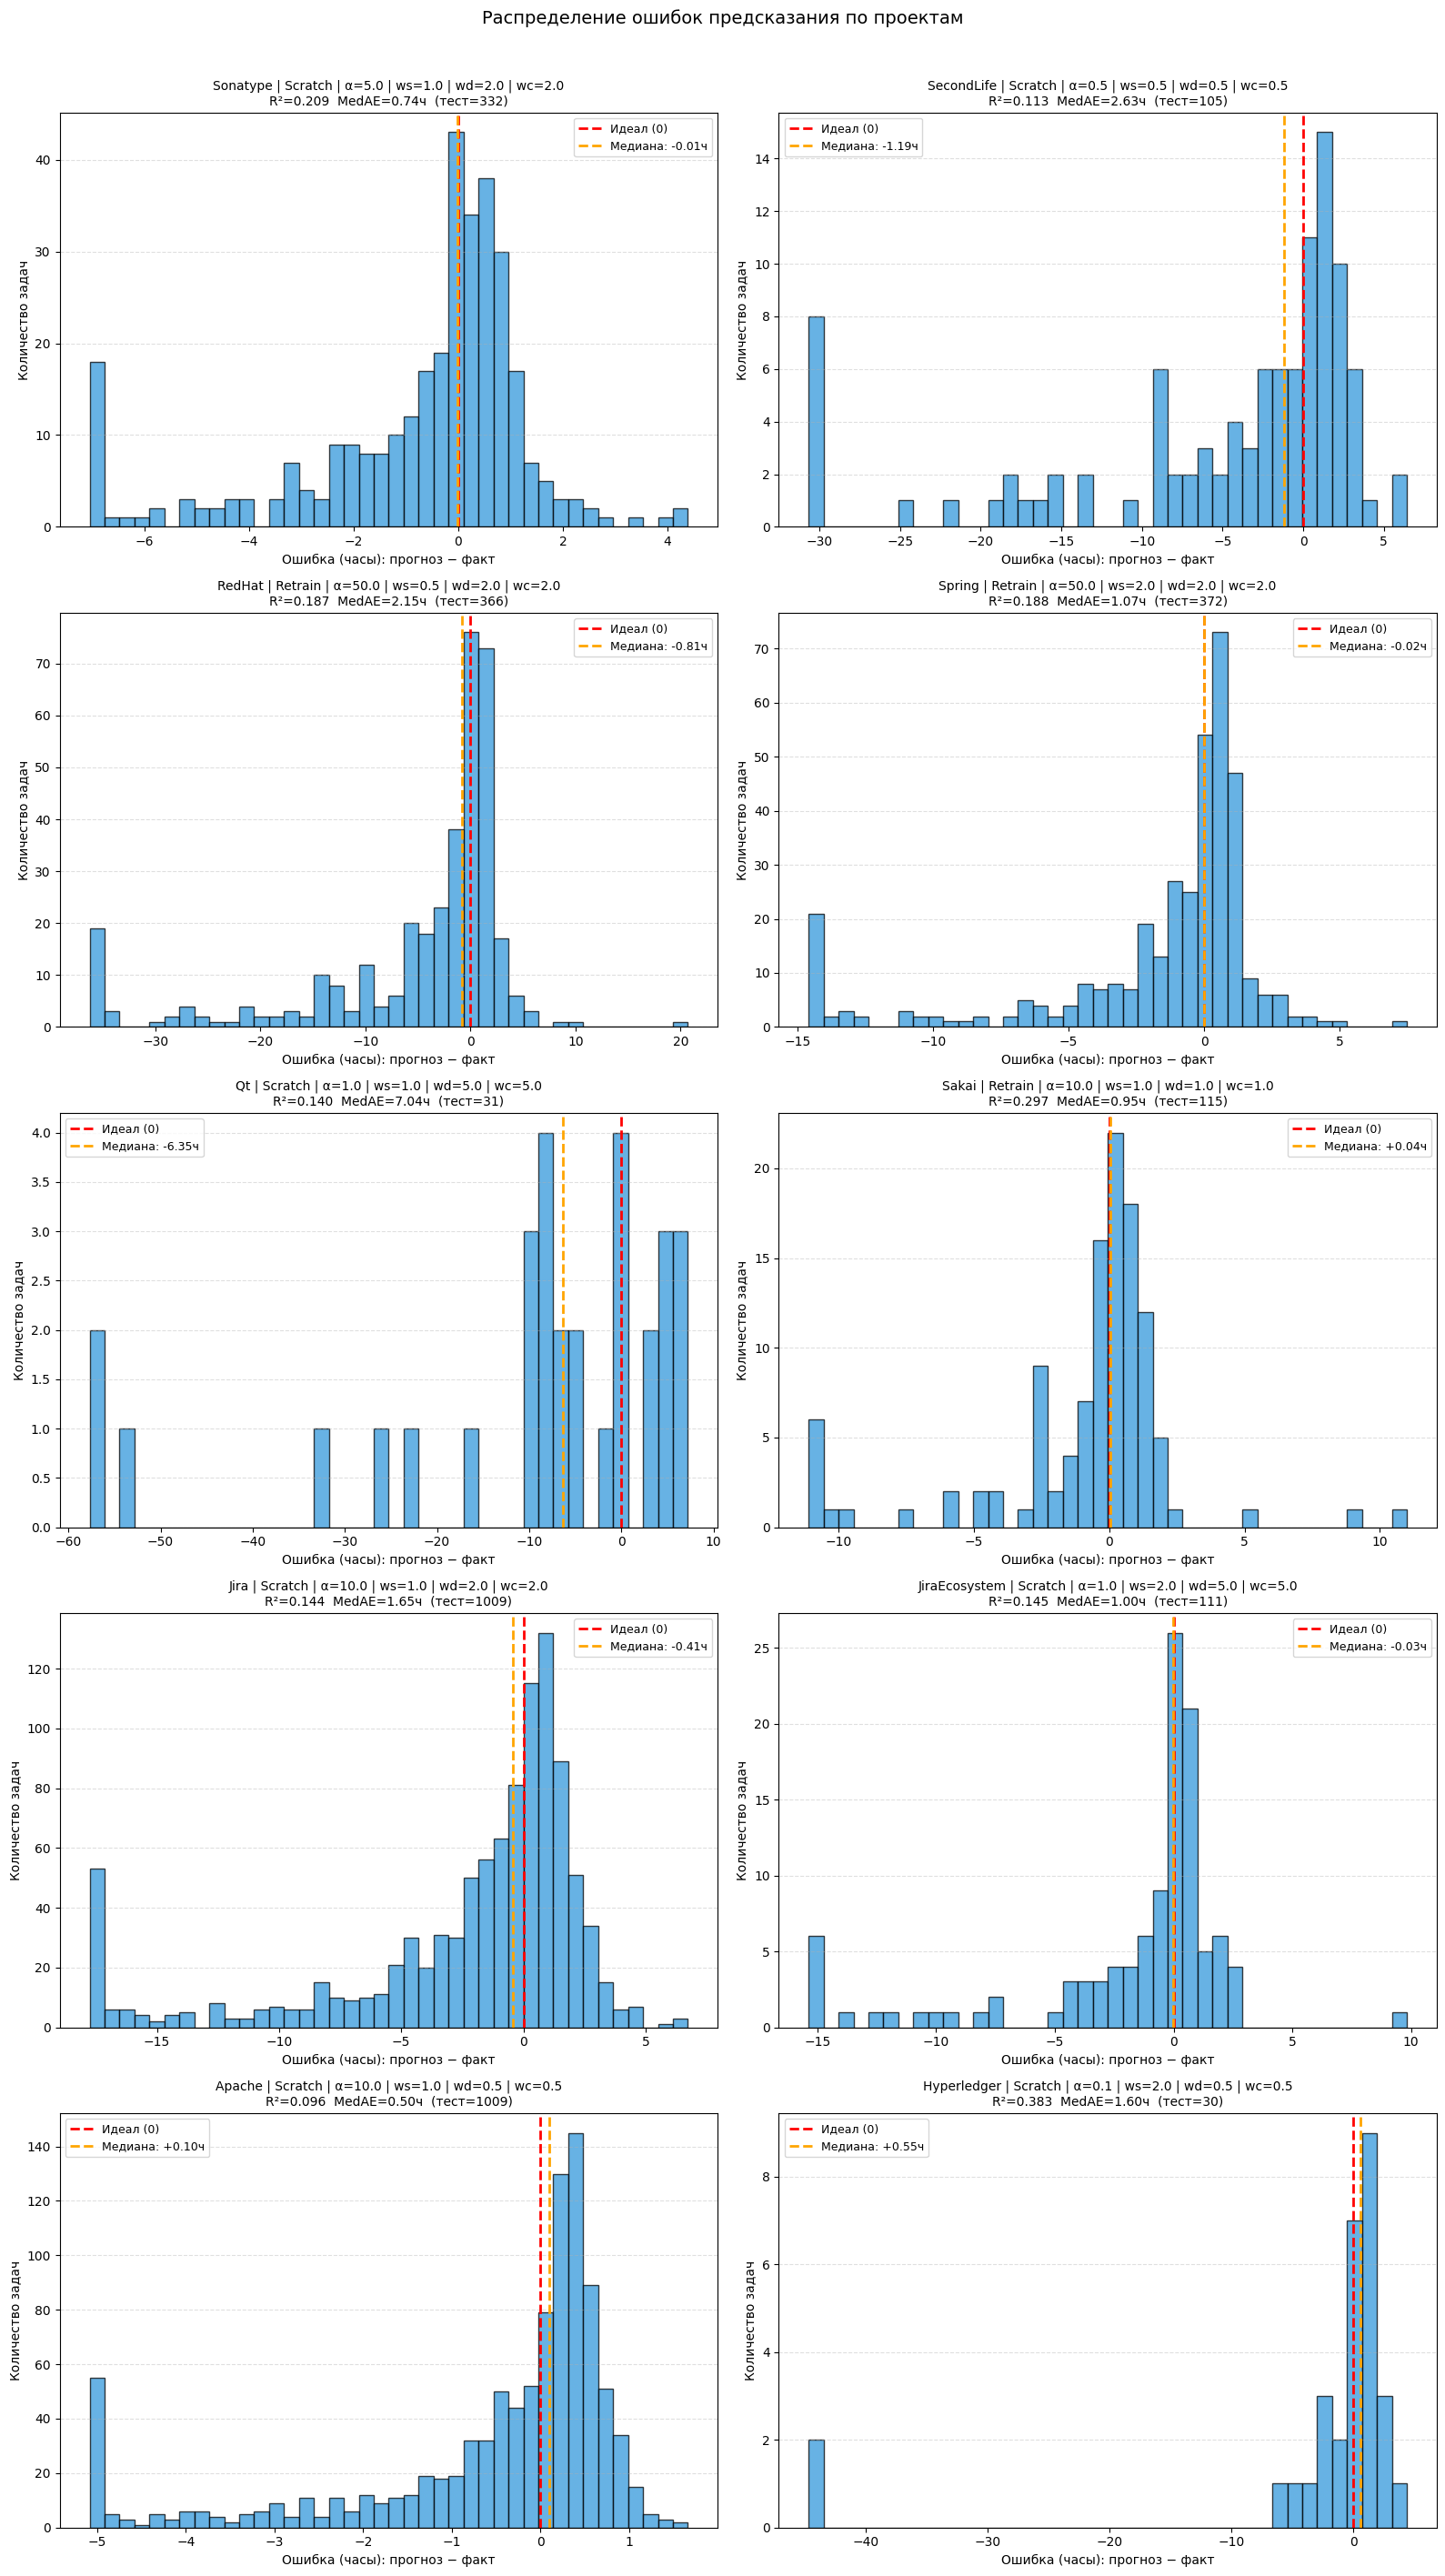

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.sparse import hstack, vstack

# ============================================================
# Лучшие параметры для каждого проекта
# ============================================================

best_configs = {
    "Sonatype": {
        "method": "Scratch", "alpha": 5.0,
        "ws": 1.0, "wd": 2.0, "wc": 2.0
    },
    "SecondLife": {
        "method": "Scratch", "alpha": 0.5,
        "ws": 0.5, "wd": 0.5, "wc": 1.0
    },
    "RedHat": {
        "method": "Retrain", "alpha": 50.0,
        "ws": 0.5, "wd": 2.0, "wc": 2.0
    },
    "Spring": {
        "method": "Retrain", "alpha": 50.0,
        "ws": 2.0, "wd": 2.0, "wc": 0.5
    },
    "Qt": {
        "method": "Scratch", "alpha": 1.0,
        "ws": 1.0, "wd": 5.0, "wc": 0.5
    },
    "Sakai": {
        "method": "Retrain", "alpha": 10.0,
        "ws": 1.0, "wd": 1.0, "wc": 0.5
    },
    "Jira": {
        "method": "Scratch", "alpha": 10.0,
        "ws": 1.0, "wd": 2.0, "wc": 1.0
    },
    "JiraEcosystem": {
        "method": "Scratch", "alpha": 1.0,
        "ws": 2.0, "wd": 5.0, "wc": 2.0
    },
    "Apache": {
        "method": "Scratch", "alpha": 10.0,
        "ws": 1.0, "wd": 0.5, "wc": 1.0
    },
    "Hyperledger": {
        "method": "Scratch", "alpha": 0.1,
        "ws": 2.0, "wd": 0.5, "wc": 5.0
    },
}

projects = list(best_configs.keys())

# ============================================================
# Обучение и сбор ошибок
# ============================================================

fig, axes = plt.subplots(5, 2, figsize=(16, 28))
axes = axes.flatten()

for idx, target_project in enumerate(projects):
    cfg = best_configs[target_project]
    ws, wd, wc = cfg["ws"], cfg["wd"], cfg["wc"]
    alpha = cfg["alpha"]
    method = cfg["method"]

    mask_target = df_balanced["source_collection"] == target_project
    df_pretrain_raw = df_balanced[~mask_target]
    df_target_raw = df_balanced[mask_target]

    df_finetune_raw, df_test_raw = train_test_split(
        df_target_raw, test_size=0.2, random_state=42
    )

    # TF-IDF
    tfidf_sum = TfidfVectorizer(
        max_features=15000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    s_pre = tfidf_sum.fit_transform(df_pretrain_raw["summary"].fillna(""))
    s_ft = tfidf_sum.transform(df_finetune_raw["summary"].fillna(""))
    s_te = tfidf_sum.transform(df_test_raw["summary"].fillna(""))

    tfidf_desc = TfidfVectorizer(
        max_features=35000, ngram_range=(1, 2),
        min_df=3, max_df=0.95, sublinear_tf=True
    )
    d_pre = tfidf_desc.fit_transform(df_pretrain_raw["description"].fillna(""))
    d_ft = tfidf_desc.transform(df_finetune_raw["description"].fillna(""))
    d_te = tfidf_desc.transform(df_test_raw["description"].fillna(""))

    tfidf_char = TfidfVectorizer(
        max_features=20000, analyzer="char_wb",
        ngram_range=(3, 5), min_df=3, max_df=0.95, sublinear_tf=True
    )
    c_pre = tfidf_char.fit_transform(df_pretrain_raw["text"])
    c_ft = tfidf_char.transform(df_finetune_raw["text"])
    c_te = tfidf_char.transform(df_test_raw["text"])

    X_pre = hstack([s_pre * ws, d_pre * wd, c_pre * wc])
    X_ft = hstack([s_ft * ws, d_ft * wd, c_ft * wc])
    X_te = hstack([s_te * ws, d_te * wd, c_te * wc])

    y_pre = df_pretrain_raw["log_timespent"].values
    y_ft = df_finetune_raw["log_timespent"].values
    y_te = df_test_raw["log_timespent"].values

    # Обучение
    if method == "Scratch":
        model = Ridge(alpha=alpha).fit(X_ft, y_ft)
    else:
        w_sample = len(y_pre) / len(y_ft)
        X_c = vstack([X_pre, X_ft])
        y_c = np.concatenate([y_pre, y_ft])
        wts = np.concatenate([np.ones(len(y_pre)), np.ones(len(y_ft)) * w_sample])
        model = Ridge(alpha=alpha).fit(X_c, y_c, sample_weight=wts)

    y_pred = model.predict(X_te)

    # Ошибки в часах
    y_te_sec = np.expm1(y_te)
    y_pred_sec = np.expm1(y_pred)
    errors_hours = (y_pred_sec - y_te_sec) / 3600

    r2 = r2_score(y_te, y_pred)
    medae_h = np.median(np.abs(errors_hours))
    median_err = np.median(errors_hours)

    # Обрезаем хвосты (95-й перцентиль) для читаемости
    clip_val = np.percentile(np.abs(errors_hours), 95)
    errors_clipped = np.clip(errors_hours, -clip_val, clip_val)

    # График
    ax = axes[idx]
    ax.hist(errors_clipped, bins=40, color="#3498db", edgecolor="black", alpha=0.75)
    ax.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Идеал (0)")
    ax.axvline(x=median_err, color="orange", linestyle="--", linewidth=2,
               label=f"Медиана: {median_err:+.2f}ч")

    ax.set_title(
        f"{target_project} | {method} | α={alpha} | ws={ws} | wd={wd} | wc={wd}\n"
        f"R²={r2:.3f}  MedAE={medae_h:.2f}ч  "
        f"(тест={len(df_test_raw)})",
        fontsize=10
    )
    ax.set_xlabel("Ошибка (часы): прогноз − факт")
    ax.set_ylabel("Количество задач")
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Распределение ошибок предсказания по проектам",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()